Normalize,
smaller/larger roughness contrast,
vertical stripes

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/blob_code")

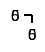

In [2]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *

In [3]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


## Load simulations

In [4]:
def load_output(out_dir, load = 1):
    path = os.path.join(out_dir, "sim_list.json")

    # read_summary(sim_list[0], default, out_dir)
    with open(path, "r") as read_file:
        sim_list = json.load(read_file)

    path = os.path.join(out_dir, "default.json")

    with open(path, "r") as read_file:
        default = json.load(read_file)   

    if load == 1:
        summary, badlist = load_summary(sim_list, default, out_dir)    
    else:
        summary, badlist = get_summary(sim_list, default, out_dir)
    
    return summary, badlist, sim_list



In [5]:
out_dir = os.path.join(project_dir, "runaround_smooth_band")
summary, badlist, sim_list = load_output(out_dir, load = 0)


p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.05
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.1
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.2
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.3
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.4
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.5
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.6
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.7
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.8
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.9
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.95
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-

p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-10,seed-1,fV-0.6
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-10,seed-1,fV-0.7
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-10,seed-1,fV-0.8
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-10,seed-1,fV-0.9
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-10,seed-1,fV-0.95
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.05
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.1
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.2
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.3
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.4
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-4,seed-1,fV-0.5
p-5,tr-60,l-200,alpha_v-0.2,Ks_v-3,

p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.1
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.2
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.3
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.4
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.5
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.6
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.7
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.8
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.9
p-8,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-v_band,stripe_count-10,seed-1,fV-0.95
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,veg_type-band,stripe_count-4,seed-1,fV-0.05
p-8,tr-60,l-200,alpha_

In [6]:
for key in summary.index:
    sim = summary.loc[key]
    summary.loc[key, 'fV'] = (sim.veg.mean())

In [7]:

print_input_params(sim_list)

rain intensity, p (cm/hr): 5, 8
rain duration, tr (min): 30, 60
hillslope length, l (m): 200
vegetation n, alpha_v: 0.2
vegetation Ksat, Ks_v (cm/hr): 3
Slope angle, So: 0.01
veg_type: 'band', 'v_band'
stripe_count: , 4, 6, 10
vegetation fraction, fV: 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95


(<Figure size 700x300 with 1 Axes>, <Axes: xlabel='minutes', ylabel='cm/hr'>)

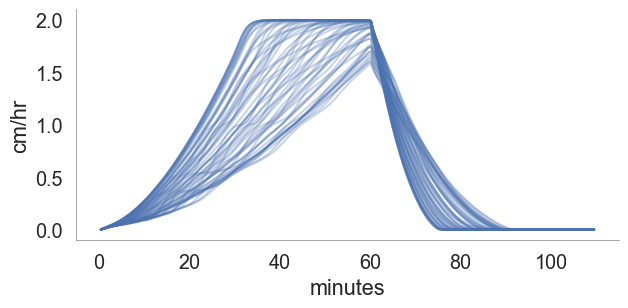

In [8]:
plot_hydrographs(summary.query("tr == 60 and l == 200 and p == 5"))

In [9]:

out_dir_eq = os.path.join(project_dir, "runaround_equiv_smooth")
summary_equiv, badlist_equiv, sim_list_equiv = load_output(out_dir_eq, load = 1)


In [10]:
print_input_params(sim_list_equiv)

rain intensity, p (cm/hr): 5, 8
rain duration, tr (min): 30, 60
hillslope length, l (m): 200
vegetation fraction, fV: 0.
bare soil n, alpha_b: 0.03, 0.032, 0.035, 0.037, 0.04, 0.042, 0.045, 0.047, 0.049, 0.052, 0.054, 0.057
, 0.059, 0.062, 0.064, 0.066, 0.069, 0.071, 0.074, 0.076, 0.079, 0.081, 0.083, 0.086
, 0.088, 0.091, 0.093, 0.096, 0.098, 0.1, , 0.103, 0.105, 0.108, 0.11, 0.113, 0.115
, 0.117, 0.12, 0.122, 0.125, 0.127, 0.13, 0.132, 0.134, 0.137, 0.139, 0.142, 0.144
, 0.147, 0.149, 0.151, 0.154, 0.156, 0.159, 0.161, 0.164, 0.166, 0.168, 0.171, 0.173
, 0.176, 0.178, 0.181, 0.183, 0.185, 0.188, 0.19, 0.193, 0.195, 0.198, 0.2, 
vegetation Ksat, Ks_v (cm/hr): 3
Slope angle, So: 0.01


In [11]:
summary = add_terms(summary)
summary = add_lengthscales(summary)

In [12]:
# summary = summary.sample(100)

In [13]:
def add_lengthscales(summary):
    """
    """
    import cv2
    for fld in ['patch_LV', 'LV_dist', 'upslope_B', 'upslope_V', 'uB_dist',
                 'patch_WV', 'WV_dist', 'patch_LB', 'LB_dist', 'L_dc_dist']:
        
        summary = insert_fld(summary,fld)

    for key in summary.index:
        
        sim = summary.loc[key]
        
        summary.at[key,"fV"] = sim.veg.mean()

        patch_LV, upslope_B = get_patchL(sim.veg, 1000) 
        
        summary.at[key,"patch_LV"] = patch_LV # [patch_LV> 0].mean()
        
        summary.at[key,"LV_dist"] =  unweight_array(patch_LV)
        summary.at[key,"LV"] =  np.mean(summary.at[key,"LV_dist"])    
                
        summary.at[key,"upslope_B"] = upslope_B
        uB = unweight_array(upslope_B)
        summary.at[key,"uB_dist"] = uB
        summary.at[key,"uB"] = np.mean(uB)
 
        patch_WV, patch_right_B = get_patchL(sim.veg.T, 1000) 
        summary.at[key,"patch_WV"] = patch_WV
        WV = unweight_array(patch_WV) 
        summary.at[key,"WV_dist"] = WV
        summary.at[key,"WV_avg"] = np.mean(WV)       
        
        patch_LB, upslope_V = get_patchL(1-sim.veg, 1000)   
        L_dc = patch_LB[:, -1]
        summary.at[key,"L_dc_dist"] =  L_dc
        summary.at[key,"L_dc"] = L_dc.mean()     
        summary.at[key,"L_dc>0"] = L_dc[L_dc>0].mean()     
        summary.at[key,"patch_LB"] = patch_LB
        summary.at[key,"upslope_V"] = upslope_V

        # bare soil length, including 0s
        summary.at[key,"LB_w"] = patch_LB[patch_LB>0].mean() # weighted 
        summary.at[key,"LB_wv"] = patch_LB.mean() # weighted with vegetation
        
        # bare soil length, unweighted
        LB = unweight_array(patch_LB) 
        summary.at[key,"LB_dist"] = LB
        summary.at[key,"LB"] = np.mean(LB) # unweighted
        
        # along slope fraction that is transition from bare soil to vegetated
        bare_to_veg = (np.diff(sim.veg, 1) == -1)
        summary.at[key, "bare_to_veg"] = bare_to_veg.mean()
        
        # # along slope fraction that is transition from vegetated to bare soil
        # (np.diff(sim.veg, 1) == 1).mean()
        veg_to_bare = (np.diff(sim.veg, 1) == 1)  
        summary.at[key,"veg_to_bare"] = veg_to_bare.mean()

        # # fraction of hillslope available for lateral/transverse flow
        # (np.diff(sim.veg, 1) != 1).mean()


        edge = (sim.veg - cv2.erode(sim.veg, np.ones([1,3]), 1)) 
        summary.at[key,'edge'] =  edge.sum()/sim.veg.sum()
    

    return summary

In [14]:
summary = add_Reynolds_numbers(summary)
summary = add_Re_all(summary)

In [15]:
# uniform domain simulations
summary_equiv = add_terms(summary_equiv)
summary_equiv = add_lengthscales(summary_equiv)

In [16]:
# 
summary = insert_fld(summary, 'equiv_hydro')     # hydrogaph in equivalent roughness
summary = insert_fld(summary, 'equiv_hydro_IF') # gridded infiltration fraction

In [17]:
len(summary.index)

264

In [18]:
for c, key in enumerate(summary.index):
    
    sim  = summary.loc[key]

    # Subset library of uniform runs to those matching geometry/forcing for this sim
    subset = summary_equiv.query("l == {0} and p == {1} and tr == {2} ".format(sim.l, sim.p, sim.tr))
    
    # --- Match full hydrograph by RMSE (align lengths defensively) ---
    nhydro = len(sim.hydro)
    # RMSE between this heterogeneous run and each candidate uniform run (min over common length)
    errors = [np.mean((sim.hydro[:min(nhydro, len(hydro))] - 
                       hydro[:min(nhydro, len(hydro))])**2)**0.5 for hydro in subset.hydro]
    ind = np.where(errors == np.min(errors))[0][0]  # argmin; first if ties
        
    # Equivalent roughness = alpha_b of the best‐matching uniform run
    r_equiv = subset.iloc[ind].alpha_b
    summary.loc[key, 'r_equiv'] = r_equiv 
    # IF misfit (diagnostic): absolute difference at the best hydrograph match
    summary.loc[key, 'IF_err'] = np.abs(sim.IF - subset.iloc[ind].IF)
   
    # Store the matched uniform hydrograph (as a list for consistency)
    summary.at[key, 'equiv_hydro'] = list(subset.query("alpha_b == {0}".format(r_equiv)).iloc[0].hydro)
    assert(len(subset.query("alpha_b == {0}".format(r_equiv))) > 0)
    
    # Normalized hydrograph error (scale by peak of this heterogeneous hydrograph)
    summary.loc[key, 'hydro_err'] = np.min(errors)/sim.hydro.max()    

    # --- Identifiability around the minimum: narrow bands of near‐optimal RMSE ---
    # 2% window around the minimum RMSE
    r_equiv = subset.iloc[np.where(errors < np.min(errors)*1.02)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv2_hydro'] = r_equiv 
    r_std =   subset.iloc[np.where(errors < np.min(errors)*1.02)[0]].alpha_b.std()
    summary.loc[key, 'r_std2'] = r_std  
    
    # 5% window around the minimum RMSE
    r_equiv = subset.iloc[np.where(errors < np.min(errors)*1.05)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv5_hydro'] = r_equiv 
    r_std =   subset.iloc[np.where(errors < np.min(errors)*1.05)[0]].alpha_b.std()
    summary.loc[key, 'r_std5'] = r_std      

    # --- Split the hydrograph into rise/fall segments and match separately ---
    i_tr = sim.i_tr  # transition index (split point)

    # Rise‐phase RMSE (up to i_tr)
    errors = [np.mean((sim.hydro[:i_tr] - hydro[:i_tr])**2)**0.5 for hydro in subset.hydro]
    r_equiv = subset.iloc[np.where(errors == np.min(errors))[0][0]].alpha_b
    summary.loc[key, 'r_equiv_rise'] = r_equiv 
        
    # Fall‐phase RMSE (from i_tr to the end of common length)
    # NOTE: if you intended a slice, prefer hydro[i_tr : min(nhydro, len(hydro))] (single colon).
    errors_fall = [np.mean((sim.hydro[i_tr:min(nhydro,len(hydro))] - 
                            hydro[i_tr:min(nhydro,len(hydro))])**2)**0.5 for hydro in subset.hydro]
    r_equiv = subset.iloc[np.where(errors_fall == np.min(errors_fall))[0][0]].alpha_b
    summary.loc[key, 'r_equiv_fall'] = r_equiv 
    
    # --- Equivalent roughness by calibrating a scalar index (IF) instead of the full curve ---
    errors_IF = [np.mean((sim.IF - IF)**2)**0.5 for IF in subset.IF]    
    r_equiv = subset.iloc[np.where(errors_IF == np.min(errors_IF))[0][0]].alpha_b
    summary.loc[key, 'r_equiv'] = r_equiv 
    summary.at[key, 'equiv_hydro_IF'] = list(subset.query("alpha_b == {0}".format(r_equiv)).iloc[0].hydro)
    
    r_equiv = subset.iloc[np.where(errors_IF < np.min(errors_IF)*1.05)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv5'] = r_equiv 
    
    r_equiv = subset.iloc[np.where(errors_IF < np.min(errors_IF)*1.02)[0]].alpha_b.mean()    
    summary.loc[key, 'r_equiv2'] = r_equiv     

    
# --- Vegetation fraction bookkeeping (rounding kept, but a single round would suffice) ---
summary['fV'] = [veg.mean().round(3) for veg in summary.veg]
summary['fV'] = summary['fV'].astype(float).round(3)
summary['fV'] = [np.round(a,3) for a in summary.fV]

# Parse original fV from index label for comparison (assumes stable naming like '...,fV-0.3,...')
summary['fVo'] = [float(name.split(',')[2].split("-")[1]) for name in summary.index]


## Correction factor

In [19]:
def integrate_U_across(r_2d, m, So, p, dx=2):
    """
    Compute ∫ ((p x)^m / r(x) S_o^w)^(1/(m+1)) dx along axis=1 of a 2D array.

    Parameters:
    - r_2d: 2D numpy array (x along axis=1)
    - m: exponent in the formula
    - So: slope term
    - p: scaling constant
    - dx: spacing along the x axis

    Returns:
    - 1D numpy array of integrals along axis=1 (one per row)
    """
    x = np.arange(r_2d.shape[1]) * dx / 3.6e5
    x_matrix = np.expand_dims(x, axis=0) * p  # shape (1, n) to broadcast across rows

    with np.errstate(divide='ignore', invalid='ignore'):
        expr = (x_matrix ** m / r_2d) ** (1 / (m + 1))
        expr[np.isnan(expr)] = 0
        expr[np.isinf(expr)] = 0

    integral = np.trapz(expr, dx=dx, axis=1)
    return 5/7*integral * So ** (0.5 / (m + 1))


def integrate_h_across(r_2d, m, So, p, dx=2):
    """
    Compute ∫ ((x * r(x) * p * S_o^-w)^(1/(m+1)) dx along axis=1 of a 2D array.

    Parameters:
    - r_2d: 2D numpy array (x along axis=1)
    - m: exponent in the formula
    - So: slope term
    - p: scaling constant
    - dx: spacing along the x axis

    Returns:
    - 1D numpy array of integrals along axis=1 (one per row)
    """
    x = np.arange(r_2d.shape[1]) * dx / 3.6e5

    x_matrix = np.expand_dims(x, axis=0) * p  # shape (1, n) to broadcast across rows

    with np.errstate(divide='ignore', invalid='ignore'):
        expr = (x_matrix * r_2d) ** (1 / (m + 1.))
        expr[np.isnan(expr)] = 0
        expr[np.isinf(expr)] = 0

    integral = np.trapz(expr, dx=dx, axis=1)
    return 5/8*integral * So ** (-0.5 / (m + 1.))


In [20]:
## Series decomposition

for key in summary.index:
    sim = summary.loc[key]

    # ---- indices & constants
    i_tr = int(sim.i_tr)
    dx   = float(sim.dx)
    g    = 9.81

    # ---- Manning n field (float, safe copy)
    veg = np.asarray(sim.veg)
    n = veg.astype(float).copy()
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)

    # ---- time-slice arrays (float)
    h_t = np.asarray(sim.hc, dtype=float)[i_tr]  # (ny, nx)
    U_t = np.asarray(sim.vc, dtype=float)[i_tr]  # (ny, nx)

    # ---- central difference (aligns with midpoints)
    dUdx  = (U_t[:, 2:] - U_t[:, :-2]) / (2 * dx)  # (ny, nx-2)
    U_mid = U_t[:, 1:-1]                           # (ny, nx-2)

    # ---- diagnostics
    summary.loc[key, 'n_misc'] = np.nanmean(h_t**(1/6) * n**0.5)
    summary.loc[key, 'n_exp1'] = np.mean((n**1.5))**(2/3)
    summary.loc[key, 'n_exp2'] = np.mean((n**2))**(1/2)
    
    summary.loc[key, 'n_tr']   = np.nanmean(h_t**(2/3)) * (sim.So**0.5) / np.nanmean(U_t)
    summary.loc[key, 'Cd']     = g * np.nanmean(h_t) * sim.So / np.nanmean(U_t**2)    
    summary.loc[key, 'Cd_misc']     = 9.8*np.nanmean(h_t**(-1/3.)*n**0.5)


    # ---- correction-factor study
    summary.loc[key, '<U>_CF'] = (5/7) * np.nanmean((
        (1/n) * ((sim.p - sim.Ks_v)/3.6e5 * sim.l)**(2/3) * sim.So**0.5)**(3/5))
    summary.loc[key, '<h>_CF'] = (5/8) * np.nanmean(
        ((sim.p - sim.Ks_v)/3.6e5 * sim.l * n / sim.So**0.5)**(3/5))

    # ---- cross-section integrals (use sim.dx)
    try:
        Ua = 5/7*integrate_U_across(n, 2/3, sim.So, sim.p - sim.Ks_v, dx=dx)/sim.l
        ha = 5/8*integrate_h_across(n, 2/3, sim.So, sim.p - sim.Ks_v, dx=dx)/sim.l
        summary.loc[key, '<Ua>'] = np.nanmean(Ua)
        summary.loc[key, '<ha>'] = np.nanmean(ha)
        summary.loc[key, '<na>'] = (np.nanmean(ha))**(2/3) / np.nanmean(Ua) * sim.So**0.5
    except NameError:
        summary.loc[key, '<Ua>'] = np.nan
        summary.loc[key, '<ha>'] = np.nan
        summary.loc[key, '<na>'] = np.nan

    # ---- means
    U_bar = float(np.nanmean(U_t))
    h_bar = float(np.nanmean(h_t))
    n_bar = float(np.nanmean(n))
    
    summary.loc[key, 'n_exp3']  = np.mean(h_t**(5/3))/(np.mean(h_t**(5/3)/n) )
    summary.loc[key, 'n_exp4']  = np.mean(n)
    summary.loc[key, 'n_exp6']  = np.mean(h_t**(1/3)*n) / np.mean(h_t**(1/3))
    summary.loc[key, 'n_exp7']  = np.mean(h_t**(6)*n) / np.mean(h_t**(1./6))    
    summary.loc[key, 'n_exp8']  = 1 /np.mean(n**(-1))         

    summary.loc[key, '<n>']     = n_bar
    summary.loc[key, '<U>']     = U_bar
    summary.loc[key, '<h>']     = h_bar
    summary.loc[key, '<U>/<h>'] = U_bar / h_bar
    summary.loc[key, 'n_gmean'] = gmean(n.ravel())

    summary.loc[key, '<n2>']    = float(np.nanmean(n**2))
    summary.loc[key, '<n>2']    = n_bar**2

    # ---- direct mean friction slope (ground truth)
    Sf_direct = float(np.nanmean(n**2 * h_t**(-4/3) * U_t**2))
    summary.loc[key, '<Sf>']        = Sf_direct
    summary.loc[key, '<Sf>_direct'] = Sf_direct  # convenient alias

    # ---- fluctuations
    Up = U_t - U_bar
    hp = h_t - h_bar
    np_ = n - n_bar

    dUp_dx = (Up[:, 2:] - Up[:, :-2]) / (2 * dx)

    # time derivative of <U>
    Um = np.nanmean(np.asarray(sim.vc), axis=(1, 2))
    summary.loc[key, 'd<U>/dt'] = np.gradient(Um, float(sim['dt']))[i_tr]

    # velocity gradient summaries
    summary.loc[key, '<dU/dx>']     = float(np.nanmean(dUdx))
    summary.loc[key, '<U dU/dx>']   = float(np.nanmean(U_mid * dUdx))
    summary.loc[key, '<U><dU/dx>']  = float(np.nanmean(U_mid) * np.nanmean(dUdx))
    summary.loc[key, '<Up dUp/dx>'] = float(np.nanmean(Up[:, 1:-1] * dUp_dx))
    summary.loc[key, '<Up2>']       = float(np.nanmean(Up**2))
    summary.loc[key, '<hp2>']       = float(np.nanmean(hp**2))
    summary.loc[key, '<nU>']        = float(np.nanmean(n*U_t))
    summary.loc[key, '<n><U>']      = float(U_bar*n_bar)
    summary.loc[key, '<np Up>']     = float(np.nanmean(np_*Up))
    summary.loc[key, '<h^2/3>']     = float(np.nanmean(h_t**(2/3)))    
    summary.loc[key, '<Uh>']        = float(np.nanmean(h_t*U_t))        

    # depth gradients (same stencil)
    dh_dx  = (h_t[:, 2:] - h_t[:, :-2]) / (2 * dx)
    dhp_dx = (hp[:, 2:] - hp[:, :-2]) / (2 * dx)
    summary.loc[key, '<dh/dx>']  = float(np.nanmean(dh_dx))
    summary.loc[key, '<dhp/dx>'] = float(np.nanmean(dhp_dx))

    # ---- prefactor: <n2><h>^-4/3
    summary.loc[key, '<n2><h>^-4/3'] = np.nanmean(n**2) * (h_bar ** (-4/3))

    # ---- second-moment stats
    summary.loc[key, '<np2>']   = float(np.nanmean(np_**2))
    summary.loc[key, '<np Up>']  = float(np.nanmean(np_ * Up))
    summary.loc[key, '<Up hp>'] = float(np.nanmean(Up * hp))
    summary.loc[key, '<np hp>'] = float(np.nanmean(np_ * hp))

    
    # --- mean unit discharge <q> via three forms (diagnostic)
    # Use a wet mask to avoid tiny/zero depths
    hmin =  1e-4
    wet = (h_t > hmin) & np.isfinite(U_t) & np.isfinite(n)
    
    # ===== Second-order prediction for n_e/<n> using n and h only =====
    # r = (n - <n>)/<n>,   eps = (h - <h>)/<h>
    r   = np_ / n_bar                          # n' / <n>
    eps = hp / h_bar                           # h' / <h>

    r2    = float(np.nanmean(r**2))            # <r^2>
    eps2  = float(np.nanmean(eps**2))          # <eps^2>
    r_eps = float(np.nanmean(r * eps))         # <r eps>

    # Store the components
    summary.loc[key, '<r2>']     = r2
    summary.loc[key, '<eps2>']   = eps2
    summary.loc[key, '<r eps>']  = r_eps


    # 2nd-order approximation for effect ratio (n_e / <n>)
    er_Qpred2 = 1/(1.0 + r2 + (5/9)*eps2 - (5/3)*r_eps)
    summary.loc[key, 'effect_ratio_Qpred2']   = er_Qpred2               # predicted effect ratio
    summary.loc[key, 'n_e_Qpred2']  = er_Qpred2 * n_bar       # predicted n_e 

    
    # discharge effect ratio estimate
    inv_ne = np.nanmean((1 / n[wet]) * (h_t[wet] / h_bar)**(5/3))
    summary.loc[key, 'n_e_Q'] =  1 / inv_ne
    summary.loc[key, 'effect_ratio_Q']  = 1 / inv_ne / n_bar

    # ===== U-based effective roughness (exact + 2nd-order) =====
    # ups = U'/<U>
    ups   = Up / U_bar
    ups2  = float(np.nanmean(ups**2))          # <ups^2>
    r_ups = float(np.nanmean(r * ups))         # <r * ups>
    eps_ups = float(np.nanmean(eps * ups))         # <eps * ups>

    # Store U-based second moments
    summary.loc[key, '<ups2>']    = ups2
    summary.loc[key, '<r ups>']   = r_ups
    summary.loc[key, '<eps ups>']   = eps_ups    
    
    # Exact effect ratio from identity:
    # (n_e / <n>) = < (n/<n>)^(3/2) * (U/<U>)^(5/2) >^(2/3)
    bracket = (n / n_bar)**(3/2) * (U_t / U_bar)**(5/2)
    effect_ratio_U = float(np.nanmean(bracket[wet]))**(2/3)
    summary.loc[key, 'effect_ratio_U'] = effect_ratio_U
    summary.loc[key, 'n_e_U']          = effect_ratio_U * n_bar

    # 2nd-order approximation:
    # n_e/<n> ≈ 1 + (1/4)<r^2> + (5/4)<ups^2> + (5/2)<r ups>
    effect_ratio_Upred2 = 1.0 + 0.25*r2 + 1.25*ups2 + 2.5*r_ups
    summary.loc[key, 'effect_ratio_Upred2'] = effect_ratio_Upred2
    summary.loc[key, 'n_e_Upred2']          = effect_ratio_Upred2 * n_bar
    

    # (1) Direct: q = U h
    q_direct = float(np.nanmean((U_t * h_t)[wet]))

    # (2) h-based Manning form: q = S0^{1/2} * h^{5/3} / n
    q_hform = float(sim.So**0.5 * np.nanmean((h_t[wet]**(5/3)) / n[wet]))

    # (3) U-based identity form: q = S0^{-3/4} * n^{3/2} * U^{5/2}
    q_uform = float((sim.So**(-3/4)) * np.nanmean((n[wet]**(3/2)) * (U_t[wet]**(5/2))))

    # Store means
    summary.loc[key, '<q>_direct'] = q_direct
    summary.loc[key, '<q>_hform']  = q_hform
    summary.loc[key, '<q>_uform']  = q_uform

    # Absolute differences
    summary.loc[key, 'dq_h_minus_direct'] = q_hform - q_direct
    summary.loc[key, 'dq_u_minus_direct'] = q_uform - q_direct

    # ============================
    #  Second-order series only
    # ============================

    # ---- h power factors (prefactors for <h> exponents)
    h_pref0 = h_bar**(-4/3)   # <h>^{-4/3}
    h_pref1 = h_bar**(-7/3)   # <h>^{-7/3}
    h_pref2 = h_bar**(-10/3)  # <h>^{-10/3}

    # ---- binomial coefficients for (h_bar + h')^{-4/3} up to O(eps^2)
    c0 = 1.0
    c1 = - 4.0/3.0
    c2 = 14.0/9.0

    # ---- mixed moments needed up to quadratic order
    Up2  = np.nanmean(Up**2)
    np2  = np.nanmean(np_**2)
    Uphp  = np.nanmean(Up * hp)   # <U' h'>
    nphp  = np.nanmean(np_ * hp)  # <n' h'>
    hp2  = np.nanmean(hp**2)     # <(h')^2>
    npUp = np.nanmean(np_ * Up)  # <n' U'>

    # ---- T0 .. T2 groups (strictly up to total 2nd order)
    # T0 = <n^2 U^2> up to O(2): base + <U'^2> + <n'^2> + 4<n><U><n'U'>
    T0 = (
        (n_bar**2)*(U_bar**2)
        + (n_bar**2)*Up2
        + (U_bar**2)*np2
        + 4.0*n_bar*U_bar*npUp
    )

    # T1 = <n^2 U^2 h'> up to O(2): only terms with one prime in numerator and one in h'
    T1 = (
        2.0*(n_bar**2)*U_bar*Uphp   # depth–velocity covariance, from ∂^2f/∂U∂h term
        +2.0*n_bar*(U_bar**2)*nphp # depth–roughness covariance, from ∂^2f/∂n∂h term
    )

    # T2 = <n^2 U^2 (h')^2> up to O(2): base*(h')^2
    T2 = (n_bar**2)*(U_bar**2)*hp2

    # ---- assemble contributions with prefactors
    Sf_T0 = h_pref0 * T0
    Sf_T1 = c1 * h_pref1 * T1
    Sf_T2 = c2 * h_pref2 * T2

    # ---- store individual terms (what was missing)
    summary.loc[key, '<Sf>_nbar2_Ubar2'] = h_pref0 * (n_bar**2) * (U_bar**2)
    summary.loc[key, '<Sf>_nbar2_Up2']   = h_pref0 * (n_bar**2) * Up2
    summary.loc[key, '<Sf>_Ubar2_np2']   = h_pref0 * (U_bar**2) * np2
    summary.loc[key, '<Sf>_cross_nU']    = h_pref0 * (4.0 * n_bar * U_bar * npUp)

    summary.loc[key, '<Sf>_C_Uphp_lin']   = c1 * h_pref1 * (2.0 * (n_bar**2) * U_bar * Uphp)
    summary.loc[key, '<Sf>_C_nphp_lin']   = c1 * h_pref1 * (2.0 * n_bar * (U_bar**2) * nphp)

    # ---- totals (quadratic series)
    summary.loc[key, '<Sf>_T0'] = float(Sf_T0)
    summary.loc[key, '<Sf>_T1'] = float(Sf_T1)
    summary.loc[key, '<Sf>_T2'] = float(Sf_T2)

    Sf_exp2 = float(Sf_T0 + Sf_T1 + Sf_T2)
    summary.loc[key, '<Sf>_exp2'] = Sf_exp2
    summary.loc[key, '<Sf>_direct_minus_exp2'] = Sf_direct - Sf_exp2

    # ============================
    #  Hybrid estimator (quadratic)
    # ============================
    hmin = 1e-4  # meters; tune to grid/physics
    wet  = h_t > hmin

    # Dimensionless depth fluctuation about arithmetic mean
    eps = np.where(wet, hp / h_bar, np.nan)
    summary.loc[key, 'eps_max'] = float(np.nanmax(np.abs(eps)))
    summary.loc[key, 'eps_mean'] = float(np.nanmean(np.abs(eps)))    
    summary.loc[key, 'eps_rms'] = float(np.sqrt(np.nanmean(eps**2)))

    # Quadratic series and exact per-cell weights
    w_series2 = c0 + c1*eps + c2*(eps**2)
    w_exact   = np.where(wet, (1.0 + eps)**(-4.0/3.0), np.nan)  # exact weight

    # Blend: series where |eps| <= thresh, else exact
    thresh = 0.8
    mask_series = np.abs(eps) <= thresh
    w_hybrid2 = np.where(mask_series, w_series2, w_exact)
    summary.loc[key, 'wet'] = wet.sum()
    summary.loc[key, 'eps'] = mask_series.sum()

    
    Sf_series2 = h_pref0 * float(np.nanmean((n**2) * (U_t**2) * w_series2))  # pure quadratic series
    Sf_hybrid2 = h_pref0 * float(np.nanmean((n**2) * (U_t**2) * w_hybrid2))  # hybrid quadratic

    # Store with clearer names
    summary.loc[key, '<Sf>_series2']            = Sf_series2
    summary.loc[key, 'series2_err']             = Sf_direct - Sf_series2
    summary.loc[key, '<Sf>_hybrid_quad']        = Sf_hybrid2
    summary.loc[key, 'hybrid_quad_err']         = Sf_direct - Sf_hybrid2
    summary.loc[key, 'hybrid_quad_frac_series'] = float(np.nanmean(mask_series))
    summary.loc[key, '<Sf>_direct_wet'] = float(np.nanmean((n**2) * (U_t**2) * (h_t**(-4/3)) * wet))

    # Nondimensional (quadratic) diagnostics (optional)
    ND0 = float(np.nanmean((n**2) * (U_t**2) * (eps**0)))
    ND1 = float(np.nanmean((n**2) * (U_t**2) * (eps**1)))
    ND2 = float(np.nanmean((n**2) * (U_t**2) * (eps**2)))
    Sf_nd_T0 = h_pref0 * (c0 * ND0)
    Sf_nd_T1 = h_pref0 * (c1 * ND1)
    Sf_nd_T2 = h_pref0 * (c2 * ND2)
    summary.loc[key, '<Sf>_nd_T0'] = Sf_nd_T0
    summary.loc[key, '<Sf>_nd_T1'] = Sf_nd_T1
    summary.loc[key, '<Sf>_nd_T2'] = Sf_nd_T2
    summary.loc[key, '<Sf>_nd_sumK2'] = Sf_nd_T0 + Sf_nd_T1 + Sf_nd_T2
    summary.loc[key, 'err_nd_K2'] = Sf_direct - summary.loc[key, '<Sf>_nd_sumK2']

    # ---------- Hybrid-weighted numerator decomposition (2nd-order in numerator)
    # Weight each numerator piece by w_hybrid2, then average; all share h_bar^{-4/3}
    mean_w = float(np.nanmean(w_hybrid2))

    # components analogous to classic T0 split, but hybrid-weighted
    Sf_hyb_base  = h_pref0 * (n_bar**2) * (U_bar**2) * mean_w
    Sf_hyb_Up2   = h_pref0 * (n_bar**2) * float(np.nanmean(w_hybrid2 * (Up**2)))
    Sf_hyb_np2   = h_pref0 * (U_bar**2) * float(np.nanmean(w_hybrid2 * (np_**2)))
    Sf_hyb_cross = h_pref0 * (4.0*n_bar*U_bar) * float(np.nanmean(w_hybrid2 * (np_ * Up)))

    summary.loc[key, '<Sf>_hyb_base']  = Sf_hyb_base
    summary.loc[key, '<Sf>_hyb_Up2']   = Sf_hyb_Up2
    summary.loc[key, '<Sf>_hyb_np2']   = Sf_hyb_np2
    summary.loc[key, '<Sf>_hyb_cross'] = Sf_hyb_cross

    # summed hybrid numerator pieces (diagnostic) — should be close to <Sf>_hybrid_quad
    summary.loc[key, '<Sf>_hyb_num_sum'] = Sf_hyb_base + Sf_hyb_Up2 + Sf_hyb_np2 + Sf_hyb_cross

    # T0 under hybrid weighting (sum of the 4 numerator pieces you computed)
    Sf_T0_hyb = float(Sf_hyb_base + Sf_hyb_Up2 + Sf_hyb_np2 + Sf_hyb_cross)

    summary.loc[key, '<Sf>_T0_hyb']   = Sf_T0_hyb

    
summary['r_ratio'] =  summary['alpha_b'] / summary['alpha_v'] 
summary['effect'] =  summary['<n>'] - summary['r_equiv5'] 
summary['effect_ratio'] =  summary['r_equiv5']/summary['<n>'] 
summary['effect_ratio_geom'] =  summary['r_equiv5']/summary['n_gmean']
summary['<U>^2/<Up^2>'] = (summary['<U>']**2/ summary['<Up2>'])    


# --- 1) Discharge-based n_e prediction (per time slice i_tr) ---
def ne_from_Q(sim):
    """
    Uses the identity:
        (1/n_e) * <h>^{5/3} = < h^{5/3} / n >
    ⇒  n_e = <h>^{5/3} / < h^{5/3} / n >
    computed at the analysis time slice i_tr.
    """
    i = int(sim.i_tr)

    # depth field at i_tr
    h = np.asarray(sim.hc, dtype=float)[i]   # (ny, nx)

    # rebuild Manning n from veg + (alpha_b, alpha_v) exactly as in your loop
    veg = np.asarray(sim.veg)                # 0/1
    n = veg.astype(float).copy()
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)

    h_bar = float(np.nanmean(h))
    if not np.isfinite(h_bar) or h_bar == 0:
        return np.nan

    inv_ne = float(np.nanmean((1./ n) * (h / h_bar)**(5.0/3.0)))
    return np.nan if not np.isfinite(inv_ne) or inv_ne == 0 else 1.0 / inv_ne

# Discharge-based predictions
summary['n_e_Q'] = summary.apply(ne_from_Q, axis=1)
summary['effect_ratio_Q']  = summary['n_e_Q'] / summary['<n>']    # predicted effect ratio n_e/<n>

# Observed vs predicted vectors (handy if you want quick checks)
er_obs = summary['effect_ratio'].to_numpy(float)     # observed from hydrograph (r_equiv5/<n>)
er_hat = summary['effect_ratio_Q'].to_numpy(float)         # discharge-based predicted effect ratio

ne_obs = summary['r_equiv5'].to_numpy(float)         # observed n_e from hydrograph calibration
ne_hat = summary['n_e_Q'].to_numpy(float)            # discharge-based predicted n_e



In [21]:
# summary[['n_exp1', 'n_exp2','n_exp3', 'n_exp4', 'n_exp6', 'n_exp7','n_exp8',  'r_equiv']].corr()

# Djajadi (2009) expression names (Expr. 1–9) mapped onto your columns
rename_map = {
    "n_exp1": "Expr 1. Horton–Einstein",
    "n_exp2": "Expr 2. Pavlovskii et al.",
    "n_exp3": "Expr 3. Lotter",
    "n_exp4": "Expr 4. Cox",
    "n_exp6": "Expr 6. Shear-force",
    "n_exp7": "Expr 7. Shear-force",
    "n_exp8": "Expr 8. Felkel",

    # If r_equiv is your benchmark/observed equivalent roughness (not one of Expr 1–8):
    "r_equiv": "nₑ (equivalent)"
    # If instead r_equiv is actually Djajadi's Expr 9 result, use this label instead:
    # "r_equiv": "Expr 9 – Wetted-perimeter linear (Eq. 10)"
}

cols = ["r_equiv", "n_exp1","n_exp2","n_exp3","n_exp4","n_exp6","n_exp8"]

summary[cols].rename(columns=rename_map).corr().round(3)

,nₑ (equivalent),Expr 1. Horton–Einstein,Expr 2. Pavlovskii et al.,Expr 3. Lotter,Expr 4. Cox,Expr 6. Shear-force,Expr 8. Felkel
nₑ (equivalent),1.000,0.949,0.928,0.956,0.966,0.960,0.974
Expr 1. Horton–Einstein,0.949,1.000,0.997,0.934,0.997,0.997,0.928
Expr 2. Pavlovskii et al.,0.928,0.997,1.000,0.917,0.988,0.991,0.902
Expr 3. Lotter,0.956,0.934,0.917,1.000,0.946,0.956,0.937
Expr 4. Cox,0.966,0.997,0.988,0.946,1.000,0.997,0.953
Expr 6. Shear-force,0.960,0.997,0.991,0.956,0.997,1.000,0.938
Expr 8. Felkel,0.974,0.928,0.902,0.937,0.953,0.938,1.000


In [22]:
summary.query("veg_type == 'v_band'")[cols].rename(columns=rename_map).corr().round(3)

,nₑ (equivalent),Expr 1. Horton–Einstein,Expr 2. Pavlovskii et al.,Expr 3. Lotter,Expr 4. Cox,Expr 6. Shear-force,Expr 8. Felkel
nₑ (equivalent),1.000,0.945,0.922,0.997,0.965,0.963,0.987
Expr 1. Horton–Einstein,0.945,1.000,0.997,0.944,0.997,0.998,0.928
Expr 2. Pavlovskii et al.,0.922,0.997,1.000,0.920,0.988,0.990,0.902
Expr 3. Lotter,0.997,0.944,0.920,1.000,0.965,0.962,0.994
Expr 4. Cox,0.965,0.997,0.988,0.965,1.000,1.000,0.953
Expr 6. Shear-force,0.963,0.998,0.990,0.962,1.000,1.000,0.948
Expr 8. Felkel,0.987,0.928,0.902,0.994,0.953,0.948,1.000


In [23]:
compared = (summary[['n_exp1', 'n_exp2','n_exp3', 'n_exp4', 'n_exp6', 'n_exp8']].T -
            summary['r_equiv'])
                                                                                                                
                                                                                                             
compared = compared.T

Text(0.5, 0.98, 'Expr - $r_e$')

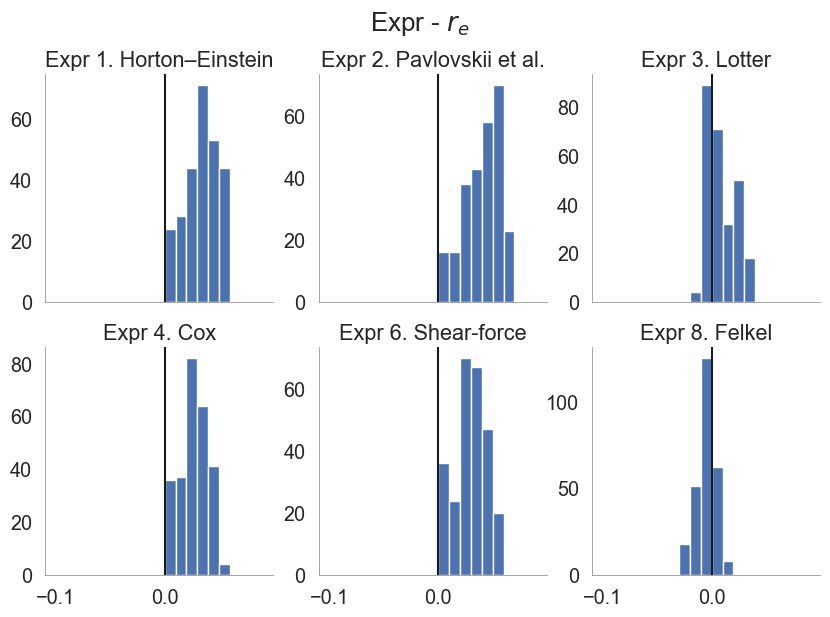

In [24]:
fig, axes = plt.subplots(2,3, figsize = (10,6.5), sharex = True)
axes = axes.ravel()
for i, col in enumerate(compared.columns):
    axes[i].hist(compared[col], bins = np.arange(-.1, .1, 0.01))
    axes[i].set_title(rename_map[col])
    axes[i].axvline(0, c = 'k')
    # compared.hist()
plt.suptitle("Expr - $r_e$")

Text(0, 0.5, 'Expr')

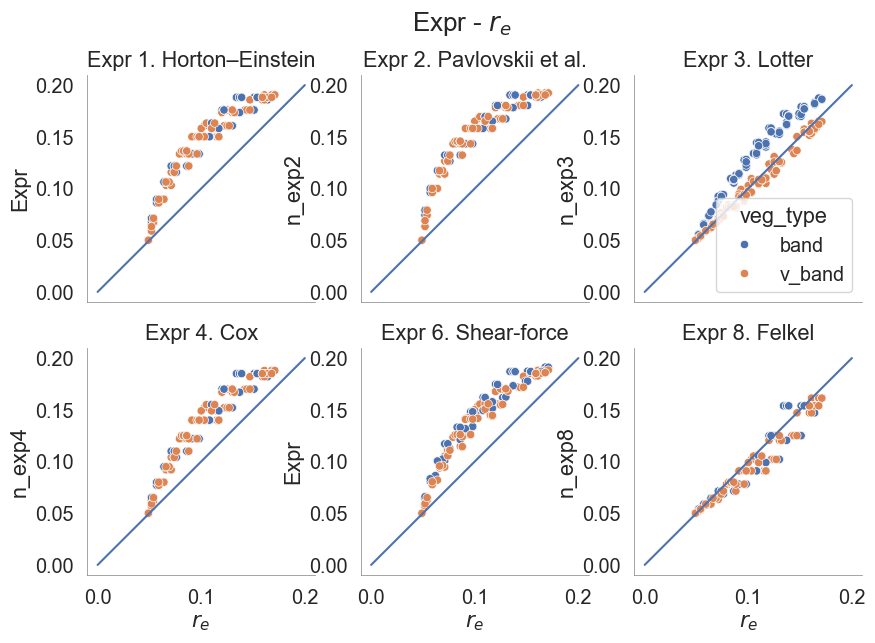

In [25]:
fig, axes = plt.subplots(2,3, figsize = (10,6.5), sharex = True)
axes = axes.ravel()
for i, col in enumerate(compared.columns):
    sns.scatterplot(data = summary,x = 'r_equiv', y = col, hue = 'veg_type', ax = axes[i], legend = False)
    # axes[i].scatter(summary["r_equiv"], summary[col], c = summary['veg_type'] == 'v_band', cmap = 'viridis')
    axes[i].set_title(rename_map[col])
    if i == 2:
        sns.scatterplot(data = summary,x = 'r_equiv', y = col, hue = 'veg_type', ax = axes[i], legend = True)
        
    if i > 2:
        axes[i].set_xlabel("$r_e$")    
    axes[i].plot([0, 0.2], [0, 0.2])

    # compared.hist()
plt.suptitle("Expr - $r_e$")
axes[0].set_ylabel("Expr")
axes[4].set_ylabel("Expr")

In [26]:
# summary['<Sf>_variance_terms']   = summary['<Sf>_nbar2_Up2'] + summary['<Sf>_Ubar2_np2']
# summary['<Sf>_hp_terms']   = summary['<Sf>_C_Uphp_lin']   + summary['<Sf>_C_nphp_lin']
# summary['effect_ratio_T0'] =  1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']

Text(0, 0.5, '$n_e/\\langle n \\rangle$')

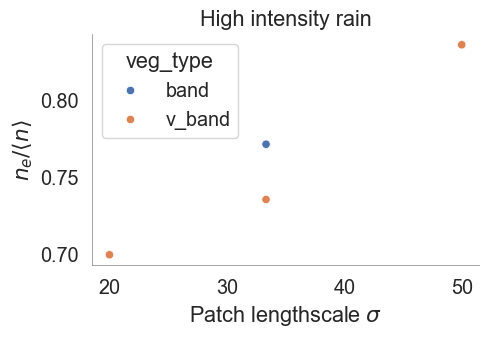

In [27]:
summary['aniso'] = 1
summary['sigma'] = summary['l']/summary['stripe_count']
summary['effect_ratio_exp3'] = summary['n_exp3']/summary['<n>']
sns.scatterplot(summary.query("p > 5 and fV == 0.6 and aniso == 1"), x = 'sigma', y = 'effect_ratio', hue = 'veg_type')
# sns.scatterplot(summary.query("p > 5 and fV == 0.6 and aniso == 1"), x = 'sigma', y = 'effect_ratio_exp3')
plt.title("High intensity rain")
plt.xlabel("Patch lengthscale $\sigma$")
plt.ylabel(r"$n_e/\langle n \rangle$")

In [28]:
summary.query("effect_ratio < 0.77 and effect_ratio > 0.74 and p == 5 and tr == 60")[['fV', 'aniso']].describe()

,fV,aniso
count,7.000000,7.0
mean,0.560000,1.0
std,0.313688,0.0
min,0.180000,1.0
25%,0.330000,1.0
50%,0.480000,1.0
75%,0.850000,1.0
max,0.900000,1.0


<Axes: >

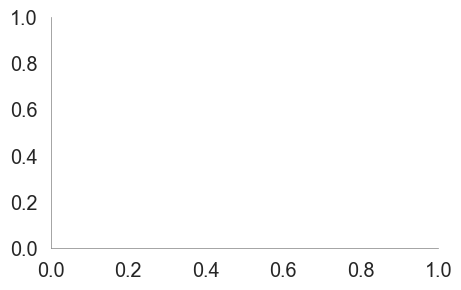

In [29]:
sns.scatterplot(data = summary.query('Ks_v == 0'), x = 'fV', y = 'effect_ratio', hue = 'veg_type', palette='mako')

In [30]:
summary.query("fV == 0.6 and aniso == 1 and sigma == 5")[['p', 'tr', 'effect_ratio']].sort_values('tr')

,p,tr,effect_ratio


In [31]:
try:
    sim = summary.query("fV == 0.6 and sigma == 5 and tr == 60 and p == 5 and aniso == 1").iloc[0]

    sim2 = summary.query("fV == 0.6 and sigma == 1 and tr == 60 and p == 5 and aniso == 1").iloc[0]
except:
    sim = summary.query("fV == 0.6 and stripe_count == 4 and tr == 60 and p == 5 and aniso == 1").iloc[0]

    sim2 = summary.query("fV == 0.6 and stripe_count == 10 and tr == 60 and p == 5 and aniso == 1").iloc[0]    

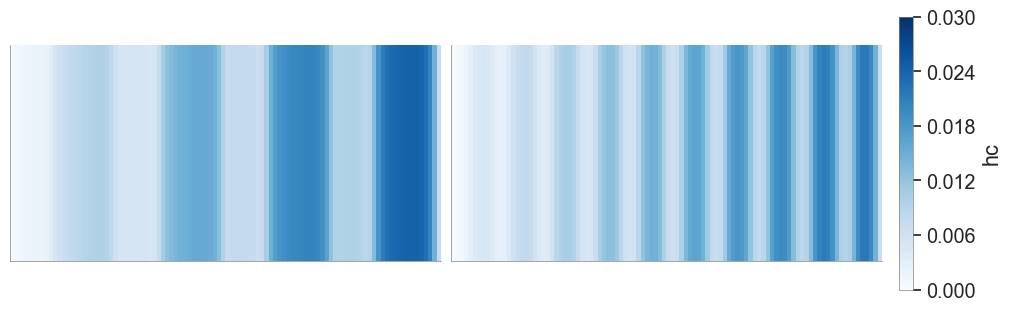

In [32]:


import matplotlib as mpl
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

vmin, vmax = 0, 0.03
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)

im0 = axes[0].imshow(sim.hc[sim.i_tr],  cmap="Blues", norm=norm)
im1 = axes[1].imshow(sim2.hc[sim.i_tr], cmap="Blues", norm=norm)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

# one colorbar spanning both panels
cbar = fig.colorbar(im1, ax=axes, location="right", fraction=0.035, pad=0.02)
cbar.set_label("hc")
cbar.locator = MaxNLocator(5)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

In [33]:
((100*sim.hc[sim.i_tr])**(5/3)).mean(),((100*sim2.hc[sim.i_tr])**(5/3)).mean()

(1.5257868343992145, 1.2258369419934663)

In [34]:
((100*sim.hc[sim.i_tr])**(5/3)).mean(),((100*sim2.hc[sim.i_tr])).mean()**(5/3)

(1.5257868343992145, 1.060670587619673)

In [35]:
((100*sim.hc[sim.i_tr]*sim.vc[sim.i_tr])).mean(),((100*sim2.hc[sim.i_tr]*sim2.vc[sim.i_tr])).mean()

(0.04931009728844914, 0.04348500857899133)

<Axes: xlabel='d', ylabel='effect_ratio'>

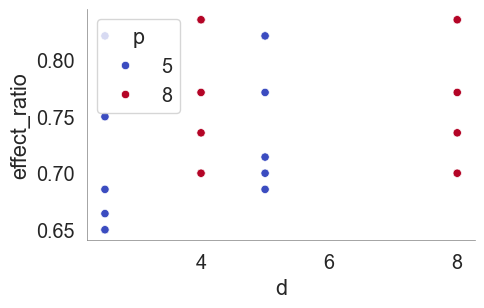

In [36]:
summary['d'] = summary['p']*summary['tr']/60
sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 and sigma > 3"), x = 'd',
                y = 'effect_ratio', hue = 'p',palette = 'coolwarm')
# sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 and sigma ==5 "), x = 'p', y = 'effect_ratio')

In [37]:
summary[['n_exp3', 'n_e_Q', 'r_equiv']].corr()

,n_exp3,n_e_Q,r_equiv
n_exp3,1.000000,0.996214,0.956160
n_e_Q,0.996214,1.000000,0.968963
r_equiv,0.956160,0.968963,1.000000


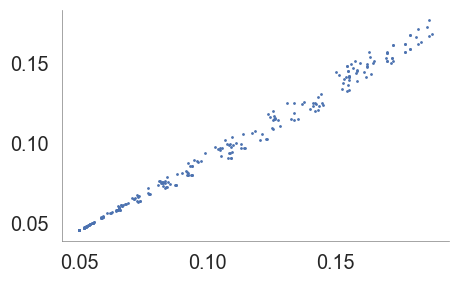

In [38]:
plt.scatter(summary['n_exp3'], summary['n_e_Q'],  s = 1)
# plt.scatter(summary['n_exp3'], summary['r_equiv'])


## Compare effect ratio predictions

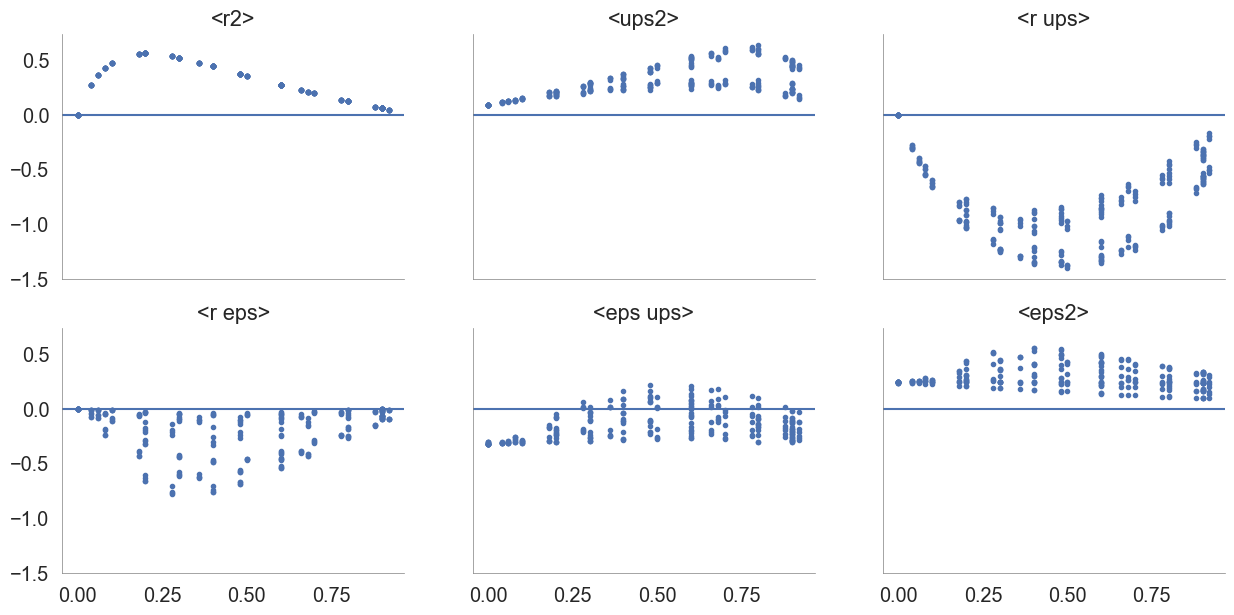

In [39]:
l = [summary['<r2>'],  summary['<ups2>'],  4*summary['<r ups>'],
           - 8/3*summary['<r eps>'], -8/3*summary['<eps ups>'],  14/9*summary['<eps2>'] ]       

fig, axes = plt.subplots(2,3, figsize = (15, 7), sharey = True, sharex = True)
axes = axes.ravel()
for i, c in enumerate(l):
    axes[i].plot(summary['fV'], c, '.')
    axes[i].set_title(c.name)
    axes[i].axhline(0)

In [40]:
# plt.scatter(summary['fV'], summary['effect_ratio'], s = 5)
# plt.scatter(summary['fV']+ .01, summary['effect_ratio_T2'], s = 5)

In [41]:
summary['effect_ratio_T0'] =    1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']

summary['effect_ratio_T1'] =    1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']\
           + 8/3*(summary['<r eps>'] + summary['<eps ups>'])    
        
summary['effect_ratio_T2'] =   1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']\
           - 8/3*(summary['<r eps>'] + summary['<eps ups>'])\
           + 14/9*summary['<eps2>']        
       
    
# Aliases for convenience
summary["ER_obs"] = summary["effect_ratio"]
summary["ER_Q"]   = summary.get("effect_ratio_Q", np.nan)
summary["ER_U"]   = summary.get("effect_ratio_U", np.nan)
summary["ER_leading"] =  summary['So'] / summary['<Sf>_nbar2_Ubar2']

# ---------------------------
# 1) Residuals vs observed
# ---------------------------
summary["res_Q"] = summary["ER_Q"] - summary["ER_obs"]
summary["res_U"] = summary["ER_U"] - summary["ER_obs"]

# ---------------------------
# 2) Fit metrics (bias, MAE, RMSE, R^2)
# ---------------------------
def fit_metrics(yhat, y):
    m = np.isfinite(yhat) & np.isfinite(y)
    if m.sum() < 3:
        return dict(n=int(m.sum()), bias=np.nan, mae=np.nan, rmse=np.nan, r2=np.nan)
    dy = yhat[m] - y[m]
    bias = float(np.mean(dy))
    mae  = float(np.mean(np.abs(dy)))
    rmse = float(np.sqrt(np.mean(dy**2)))
    r = float(np.corrcoef(yhat[m], y[m])[0,1])
    return dict(n=int(m.sum()), bias=bias, mae=mae, rmse=rmse, r2=r**2)

m_Q = fit_metrics(summary["ER_Q"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_U = fit_metrics(summary["ER_U"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_Qpred2 = fit_metrics(summary["effect_ratio_Qpred2"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_Upred2 = fit_metrics(summary["effect_ratio_Upred2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_T0 = fit_metrics(summary["effect_ratio_T0"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T2 = fit_metrics(summary["effect_ratio_T1"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T2 = fit_metrics(summary["effect_ratio_T2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_L = fit_metrics(summary["ER_leading"].to_numpy(float), summary["ER_obs"].to_numpy(float))

def print_metrics(label, m):
    print(f"{label}: n={m['n']}, "
          f"bias={m['bias']:.3f}, mae={m['mae']:.3f}, "
          f"rmse={m['rmse']:.3f}, r2={m['r2']:.3f}")

print("\n=== Effect ratio vs observed ===")
print_metrics("Q-based  vs obs", m_Q)
print_metrics("U-based  vs obs", m_U)

# ---------------------------
# 3) Which is closer to observed?
# ---------------------------
absQ = np.abs(summary["res_Q"])
absU = np.abs(summary["res_U"])
winner = np.where(absU < absQ, "U", np.where(absQ < absU, "Q", "tie"))
summary["ER_winner"] = winner
print("\nCount by winner (closer to observed):")
print(pd.Series(winner).value_counts())


# ---------------------------
# 4) Correlate residuals with drivers → combined table
# ---------------------------
drivers = ["<r2>", "<ups2>", "<eps2>", "<r ups>", "<r eps>", "<n>"]
drivers = [c for c in drivers if c in summary.columns]

def corr_to_res(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Compute for whichever residuals exist
residuals = [c for c in ["res_Q", "res_U"] if c in summary.columns]
combined_corr = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)

ERs = [c for c in ["effect_ratio_Q", "effect_ratio_U"] if c in summary.columns]
combined_ER = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)


# Add |r| and round for display
combined_corr["abs_r"] = combined_corr["pearson_r"].abs()
combined_corr_disp = combined_corr.copy()
combined_corr_disp["pearson_r"] = combined_corr_disp["pearson_r"].round(3)
combined_corr_disp["abs_r"]     = combined_corr_disp["abs_r"].round(3)

# Sort (strongest correlations first within each residual)
combined_corr_disp = (combined_corr_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True)
)

# Heatmap-friendly pivot (rows: residuals, columns: drivers)
corr_pivot = (combined_corr
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)

# If you want a neatly rounded pivot for quick viewing:
corr_pivot_disp = corr_pivot.round(3)

# --- LaTeX label maps ---
var_tex = {
    "<r2>":    r"$\langle r^2\rangle$",
    "<ups2>":  r"$\langle \upsilon^2\rangle$",
    "<eps2>":  r"$\langle \varepsilon^2\rangle$",
    "<r ups>": r"$\langle r\,\upsilon\rangle$",
    "<r eps>": r"$\langle r\,\varepsilon\rangle$",
    "fV":      r"$f_V$",
    "<n>":     r"$\langle n\rangle$",
}
res_tex = {
    "res_Q": r"$ER_Q - ER$",
    "res_U": r"$ER_U - ER$",
}

er_tex = {
    "effect_ratio_Q": r"$ER_Q$",
    "effect_ratio_U": r"$ER_U$",
    "effect_ratio":    r"$ER$",
}

# ---------- 1) Set a single canonical driver order ----------
driver_order_raw = ["<r2>", "<ups2>", "<eps2>", "<r ups>", "<r eps>", "<n>"]

# LaTeX labels for that order

x_order_tex = [var_tex[d] for d in driver_order_raw]

# Add LaTeX label columns for plotting
combined_corr_disp = combined_corr_disp.copy()
combined_corr_disp["var_tex"] = combined_corr_disp["var"].map(var_tex).fillna(combined_corr_disp["var"])
combined_corr_disp["variable_tex"] = combined_corr_disp["variable"].map(res_tex).fillna(combined_corr_disp["variable"])

# # Seaborn barplot with LaTeX x labels and legend entries
# plt.figure(figsize=(10, 4))
# sns.barplot(data=combined_corr_disp, x="var_tex", y="pearson_r", hue="variable_tex", 
#             order = x_order_tex, width = 0.5)
# plt.xlabel("Variable")
# plt.ylabel(r"Pearson $r$")
# plt.xticks(rotation=0);




=== Effect ratio vs observed ===
Q-based  vs obs: n=264, bias=-0.019, mae=0.064, rmse=0.072, r2=0.487
U-based  vs obs: n=264, bias=0.058, mae=0.068, rmse=0.085, r2=0.704

Count by winner (closer to observed):
Q    132
U    132
Name: count, dtype: int64


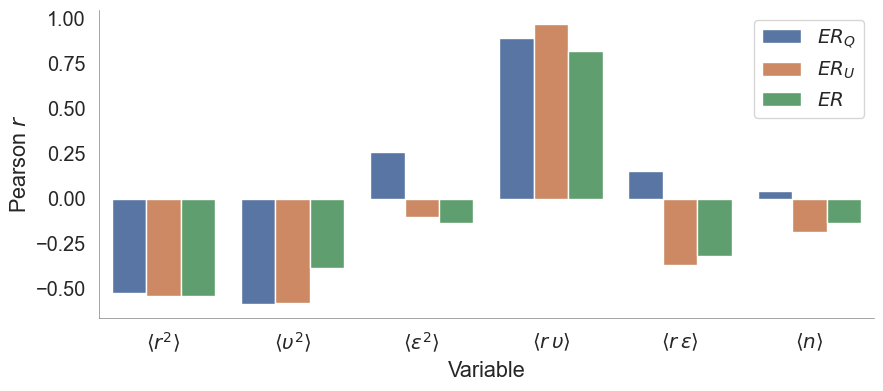

In [42]:
# ------------- Effect ratios to analyze -------------
# include observed ER if available
ERs = [c for c in ["effect_ratio_Q", "effect_ratio_U", "effect_ratio"] if c in summary.columns]

def corr_to_target(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Build effect-ratio correlation table
combined_ER = pd.concat([corr_to_target(er) for er in ERs], ignore_index=True)

# Add |r| and make a display copy
combined_ER["abs_r"] = combined_ER["pearson_r"].abs()
combined_ER_disp = combined_ER.copy()
combined_ER_disp["pearson_r"] = combined_ER_disp["pearson_r"].round(3)
combined_ER_disp["abs_r"]     = combined_ER_disp["abs_r"].round(3)

# Sort within each ER by |r|
combined_ER_disp = (combined_ER_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True))

# Pivot (rows: ERs, cols: drivers) for quick inspection/heatmap if desired
ER_corr_pivot = (combined_ER
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)
ER_corr_pivot_disp = ER_corr_pivot.round(3)

er_order      = [e for e in ["effect_ratio_Q", "effect_ratio_U", "effect_ratio"] if e in ERs]
er_order_tex  = [er_tex[e] for e in er_order]

# Map LaTeX labels for plotting
combined_ER_disp = combined_ER_disp.copy()
combined_ER_disp["var_tex"] = combined_ER_disp["var"].map(var_tex).fillna(combined_ER_disp["var"])
combined_ER_disp["variable_tex"] = combined_ER_disp["variable"].map(er_tex).fillna(combined_ER_disp["variable"])

# --- Barplot of correlations (effect ratios vs drivers) ---
plt.figure(figsize=(10, 4))
sns.barplot(data=combined_ER_disp, x="var_tex", y="pearson_r", hue="variable_tex", order = x_order_tex,
            hue_order=er_order_tex)
plt.xlabel("Variable")
plt.ylabel(r"Pearson $r$")
plt.xticks(rotation=0);
plt.legend(title = '')

In [43]:
### Something important here? 
A = summary['<h>']**(4/3.)/summary['<n>']**(2)/summary['<U>']**(2.)
# summary['<Sf>_nbar2_Ubar2'] == -  1/A


In [44]:

summary.query("fV < 0.4")[['effect_ratio', 'ER_leading', 'effect_ratio_T0','effect_ratio_T1',
         'effect_ratio_T2', 'ER_Q', 'ER_U']].corr().round(2)



,effect_ratio,ER_leading,effect_ratio_T0,effect_ratio_T1,effect_ratio_T2,ER_Q,ER_U
effect_ratio,1.00,0.95,0.84,0.46,0.92,0.88,0.97
ER_leading,0.95,1.00,0.91,0.62,0.94,0.96,0.99
effect_ratio_T0,0.84,0.91,1.00,0.80,0.95,0.89,0.90
effect_ratio_T1,0.46,0.62,0.80,1.00,0.60,0.75,0.53
effect_ratio_T2,0.92,0.94,0.95,0.60,1.00,0.87,0.96
ER_Q,0.88,0.96,0.89,0.75,0.87,1.00,0.90
ER_U,0.97,0.99,0.90,0.53,0.96,0.90,1.00


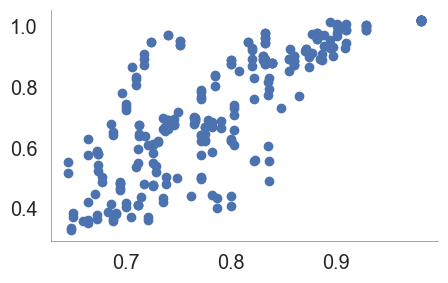

In [45]:
plt.scatter(summary['effect_ratio'], summary[ 'effect_ratio_T2'])

In [46]:
summary['effect_ratio_T1'] =    1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']\
           - 8/3*(summary['<r eps>'] + summary['<eps ups>'])    
        
summary['effect_ratio_T2'] =   1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']\
           - 8/3*(summary['<r eps>'] + summary['<eps ups>'])\
           + 14/9*summary['<eps2>']        
       
summary[['effect_ratio', 'effect_ratio_T0','effect_ratio_T1', 'effect_ratio_T2']].corr().round(2)

,effect_ratio,effect_ratio_T0,effect_ratio_T1,effect_ratio_T2
effect_ratio,1.00,0.78,0.77,0.79
effect_ratio_T0,0.78,1.00,0.82,0.92
effect_ratio_T1,0.77,0.82,1.00,0.90
effect_ratio_T2,0.79,0.92,0.90,1.00


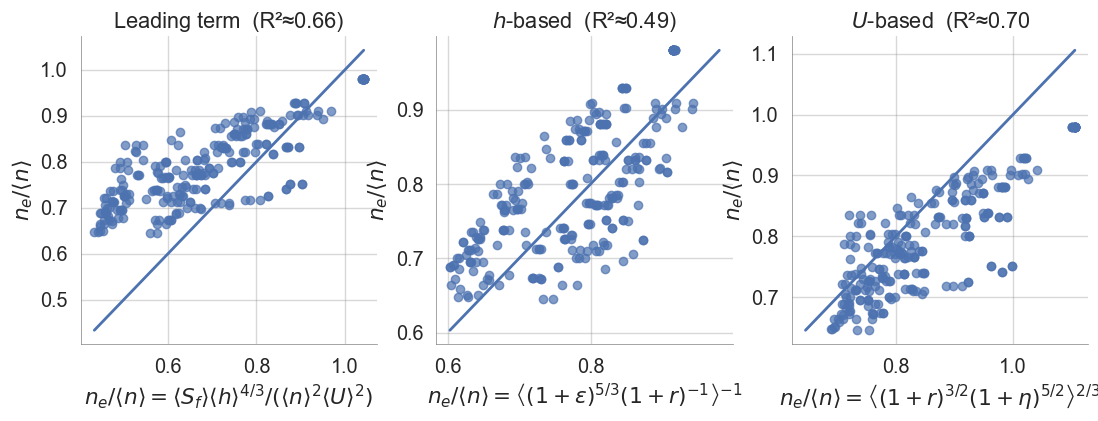

In [47]:


# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 3, figsize = (13, 4))

# --- axis 0 ---
ax = axes[0]
xy0 = (
    summary.assign(_obs = summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [[ '_obs', 'effect_ratio']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7)
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], linewidth=2)

ax.set_xlabel(r'${n_e}/{\langle n\rangle} = {\langle S_f\rangle \langle h\rangle^{4/3}}/(\langle n \rangle^{2}\langle U\rangle^{2})$')
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")

ax.set_title(r'Leading term '\
             + f" (R²≈{m_L['r2']:.2f})")
ax.grid(True, alpha=0.3)

# --- axis 1: Q-based vs observed ---
ax = axes[1]
xy = summary[["effect_ratio_Q", "effect_ratio"]].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

# x: observed effect ratio n_e / ⟨n⟩
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")
label = r'${n_e}/{\langle n\rangle}  = {\langle h\rangle^{5/3}}/(\langle n\rangle \langle \frac{h^{5/3}}{n} \rangle )$'
label = r'${n_e}/{\langle n\rangle}  = \left\langle (1+\varepsilon)^{5/3}(1+r)^{-1} \right\rangle^{-1}$'
ax.set_xlabel(label)
ax.set_title(f"$h$-based  (R²≈{m_Q['r2']:.2f})")
ax.grid(True, alpha=0.3)


# --- axis 2: U-based vs observed ---
xy = summary[["effect_ratio_U", "effect_ratio"]].dropna().to_numpy(float)
ax = axes[2]
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")
label = r"${n_e}/{\langle n\rangle} = \left\langle (1+r)^{3/2}(1+\eta)^{5/2}\right\rangle^{2/3}$"
ax.set_xlabel(label)
ax.set_title(f"$U$-based  (R²≈{m_U['r2']:.2f}")
ax.grid(True, alpha=0.3)

    

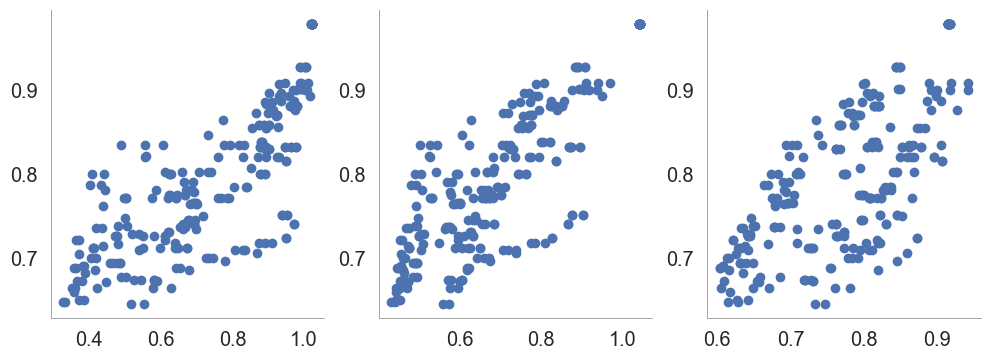

In [48]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

# --- axis 0 ---
ax = axes[0]
ax.scatter(summary['effect_ratio_T2'],  summary['effect_ratio'])

ax = axes[1]
ax.scatter( summary['ER_leading'], summary['effect_ratio'])

ax = axes[2]
ax.scatter(  summary['ER_Q'], summary['effect_ratio'])
# See if we do better with smaller roughness contrast. larger range of storm parameters.

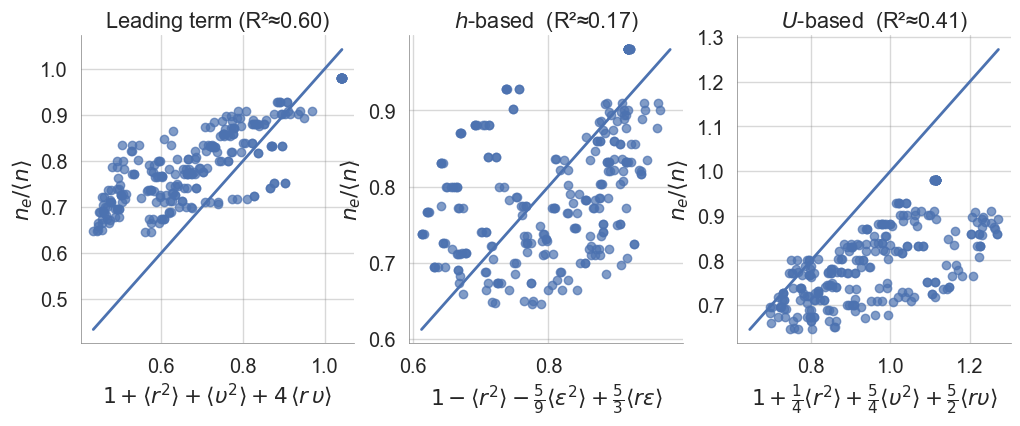

In [49]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

# --- axis 0 ---
ax = axes[0]
xy0 = (
    summary.assign(_obs = summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [[ '_obs', 'effect_ratio']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7)
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], linewidth=2)

    
label =  r'$1 + \langle r^{2}\rangle + \langle \upsilon^{2}\rangle + 4\,\langle r\,\upsilon\rangle$'
ax.set_xlabel(label)
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")

ax.set_title(r'Leading term' \
             + f" (R²≈{m_T0['r2']:.2f})")
ax.grid(True, alpha=0.3)

# --- axis 1: Q-based vs observed ---
ax = axes[1]
xy = summary[["effect_ratio_Qpred2", "effect_ratio"]].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

# x: observed effect ratio n_e / ⟨n⟩
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")
ax.set_xlabel(r"$1 - \langle r^2 \rangle - \frac{5}{9}\langle \epsilon^2 \rangle + \frac{5}{3}\left\langle r \epsilon \right\rangle$")
ax.set_title(f"$h$-based  (R²≈{m_Qpred2['r2']:.2f})")
ax.grid(True, alpha=0.3)


# --- axis 2: U-based vs observed ---
xy = summary[["effect_ratio_Upred2", "effect_ratio"]].dropna().to_numpy(float)
ax = axes[2]
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

ax.set_ylabel(r"${n_e}/{\langle n\rangle}$")
ax.set_xlabel(r"$1+\frac{1}{4}\langle r^2\rangle +\frac{5}{4}\langle \upsilon^2\rangle +\frac{5}{2}\langle r\upsilon\rangle$")
ax.set_title(f"$U$-based  (R²≈{m_Upred2['r2']:.2f})")
ax.grid(True, alpha=0.3)

    

In [50]:
(summary[['effect_ratio', '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU',  
                                    'effect_ratio_U', 'effect_ratio_Q',
                                    'effect_ratio_Upred2', 'effect_ratio_Qpred2']].corr()).round(3)

,effect_ratio,<Sf>_nbar2_Ubar2,<Sf>_cross_nU,effect_ratio_U,effect_ratio_Q,effect_ratio_Upred2,effect_ratio_Qpred2
effect_ratio,1.000,-0.767,0.769,0.839,0.698,0.640,0.411
<Sf>_nbar2_Ubar2,-0.767,1.000,-0.999,-0.918,-0.922,-0.639,-0.526
<Sf>_cross_nU,0.769,-0.999,1.000,0.915,0.917,0.653,0.522
effect_ratio_U,0.839,-0.918,0.915,1.000,0.767,0.646,0.364
effect_ratio_Q,0.698,-0.922,0.917,0.767,1.000,0.521,0.690
effect_ratio_Upred2,0.640,-0.639,0.653,0.646,0.521,1.000,0.684
effect_ratio_Qpred2,0.411,-0.526,0.522,0.364,0.690,0.684,1.000


In [51]:
# summary['effect_ratio'] = 1/summary['effect_ratio']

In [52]:
(summary.query("hydro_err < 1")[['effect_ratio', '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU',  
                                 '<Sf>_Ubar2_np2',  '<Sf>_nbar2_Up2']].corr()).round(3)

,effect_ratio,<Sf>_nbar2_Ubar2,<Sf>_cross_nU,<Sf>_Ubar2_np2,<Sf>_nbar2_Up2
effect_ratio,1.000,-0.767,0.769,-0.648,-0.521
<Sf>_nbar2_Ubar2,-0.767,1.000,-0.999,0.712,0.798
<Sf>_cross_nU,0.769,-0.999,1.000,-0.717,-0.788
<Sf>_Ubar2_np2,-0.648,0.712,-0.717,1.000,0.179
<Sf>_nbar2_Up2,-0.521,0.798,-0.788,0.179,1.000


In [53]:
len(summary), len(summary.query('hydro_err < 0.06'))

(264, 261)

In [54]:
summary[['effect_ratio_Q', 'effect_ratio_Qpred2']].corr()

,effect_ratio_Q,effect_ratio_Qpred2
effect_ratio_Q,1.000000,0.689507
effect_ratio_Qpred2,0.689507,1.000000


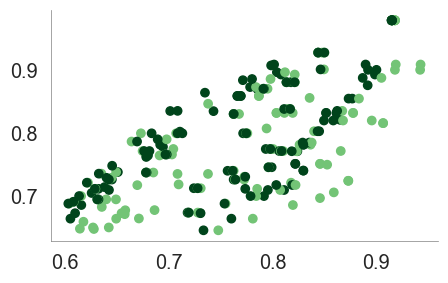

In [55]:
plt.scatter(summary.query("hydro_err < 0.05")['effect_ratio_Q'],
            summary.query("hydro_err < 0.05")['effect_ratio'],
            c = summary.query("hydro_err < 0.05")['tr'],cmap = 'Greens', vmin = 0)


In [56]:
# # # plt.plot([0.3, 0.8], [0.3, 0.8])
# # plt.scatter(summary.query("hydro_err < 0.05")['<r eta>'],
# #             summary.query("hydro_err < 0.05")['effect_ratio_Q']/summary.query("hydro_err < 0.05")['effect_ratio'],
# #             c = summary.query("hydro_err < 0.05")['tr'],cmap = 'viridis')
# # plt.colorbar()
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # Filter once
# df = summary.query("hydro_err < 0.05").copy()

# # Build x, y, color; coerce to numeric and mask NaNs
# x = pd.to_numeric(df["<r eta>"], errors="coerce")
# y = (pd.to_numeric(df["effect_ratio_Q"], errors="coerce") /
#      pd.to_numeric(df["effect_ratio"],    errors="coerce"))
# c = pd.to_numeric(df["tr"], errors="coerce")

# m = x.notna() & y.notna() & c.notna()

# fig, ax = plt.subplots(figsize=(6.5, 4.2))

# sc = ax.scatter(x[m], y[m],
#                 c=c[m], cmap="viridis",
#                 s=24, alpha=0.75, linewidths=0)

# # Colorbar
# cb = plt.colorbar(sc, ax=ax)
# cb.set_label(r"$\mathrm{tr}$")

# # Reference lines
# ax.axhline(1.0, color="0.6", lw=1, ls="--")  # ER_Q/ER = 1
# ax.axvline(0.0, color="0.6", lw=1, ls="--")  # <r η> = 0

# # Labels & styling
# ax.set_xlabel(r"$\langle r\,\eta\rangle$")
# ax.set_ylabel(r"$ER_Q/ER$")
# ax.set_title(r"$ER_Q/ER$ vs $\langle r\,\eta\rangle$  (hydro\_err < 0.05)")
# ax.grid(True, alpha=0.3)

# # Optional: clip extreme axes to 1–99th percentiles (uncomment if tails dominate)
# xlo, xhi = np.nanpercentile(x[m], [0, 100])
# ylo, yhi = np.nanpercentile(y[m], [0, 100])
# ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)

# fig.tight_layout()


In [57]:

# from matplotlib import gridspec
# import matplotlib.colors as mcolors

# # --- data (as before) ---
# df   = summary.query("hydro_err < 0.05").copy()
# ups2 = pd.to_numeric(df["<ups2>"], errors="coerce")
# eps2 = pd.to_numeric(df["<eps2>"], errors="coerce")
# ERU  = pd.to_numeric(df["effect_ratio_U"], errors="coerce")
# ER   = pd.to_numeric(df["effect_ratio"],    errors="coerce")
# y    = ERU / ER
# m    = ups2.notna() & eps2.notna() & y.notna() & np.isfinite(y)

# norm = mcolors.Normalize(vmin=np.nanmin(eps2[m]), vmax=np.nanmax(eps2[m]))
# cmap = "viridis"

# # --- figure with a dedicated colorbar column ---
# fig = plt.figure(figsize=(10, 4), constrained_layout=True)
# gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.04])

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
# cax = fig.add_subplot(gs[0, 2])   # colorbar axis

# # Left panel: <ups^2>
# sc0 = ax0.scatter(ups2[m], y[m], c=eps2[m], cmap=cmap, norm=norm,
#                   s=24, alpha=0.8, linewidths=0)
# ax0.axhline(1.0, color="0.6", lw=1, ls="--")
# ax0.set_xlabel(r"$\langle \upsilon^{2}\rangle$")
# ax0.set_ylabel(r"$ER_U/ER$")
# ax0.set_title(r"$ER_U/ER$ vs $\langle \upsilon^{2}\rangle$")
# ax0.grid(True, alpha=0.3)

# # Right panel: <eps^2>
# sc1 = ax1.scatter(eps2[m], y[m], c=eps2[m], cmap=cmap, norm=norm,
#                   s=24, alpha=0.8, linewidths=0)
# ax1.axhline(1.0, color="0.6", lw=1, ls="--")
# ax1.set_xlabel(r"$\langle \varepsilon^{2}\rangle$")
# ax1.set_title(r"$ER_U/ER$ vs $\langle \varepsilon^{2}\rangle$")
# ax1.grid(True, alpha=0.3)

# # Shared colorbar (in its own axis)
# cb = fig.colorbar(sc1, cax=cax)
# cb.set_label(r"$\langle \varepsilon^{2}\rangle$")


In [58]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from matplotlib import gridspec

# def plot_er_ratio_vs_variances(
#     summary: pd.DataFrame,
#     which: str = "U",                 # "U" or "Q"
#     err_thresh: float = 0.05,         # filter on hydro_err
#     color_by: str = "eps2",           # "eps2" or "ups2"
#     figsize=(10, 4),
#     s: float = 24, alpha: float = 0.8,
#     clip_percentiles=None,            # e.g., (1,99) to clip x/y outliers
# ):
#     """
#     Plot ER_<which> / ER versus <ups^2> (left) and <eps^2> (right),
#     colored by the chosen second-moment (default <eps^2>), with a dedicated colorbar.

#     Parameters
#     ----------
#     summary : DataFrame with columns
#         '<ups2>', '<eps2>', 'effect_ratio_U' and/or 'effect_ratio_Q', 'effect_ratio', 'hydro_err'
#     which : {"U","Q"}
#         Choose ER_U or ER_Q for the ratio ER_<which>/ER (where ER is observed).
#     err_thresh : float
#         Keep rows with hydro_err < err_thresh.
#     color_by : {"eps2","ups2"}
#         Which second-moment to color points by.
#     clip_percentiles : (lo, hi) or None
#         If given, clip x/y axes to these percentiles to reduce outlier influence.
#     """

#     # --- pick columns ---
#     er_col = {"U": "effect_ratio_U", "Q": "effect_ratio_Q"}[which.upper()]

#     # observed ER fallback if not already present
#     ER = summary.get("effect_ratio", None)
#     if ER is None and {"r_equiv5", "<n>"}.issubset(summary.columns):
#         ER = summary["r_equiv5"] / summary["<n>"]
#     elif ER is None:
#         raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>' in summary.")

#     # filter once
#     df = summary.query("hydro_err < @err_thresh").copy()

#     # coerce numerics
#     ups2 = pd.to_numeric(df["<ups2>"], errors="coerce")
#     eps2 = pd.to_numeric(df["<eps2>"], errors="coerce")
#     ERw  = pd.to_numeric(df[er_col], errors="coerce")
#     ERo  = pd.to_numeric(ER.loc[df.index], errors="coerce")

#     y = ERw / ERo
#     if color_by == "eps2":
#         color_vals = eps2
#         c_label = r"$\langle \varepsilon^{2}\rangle$"
#     elif color_by == "ups2":
#         color_vals = ups2
#         c_label = r"$\langle \upsilon^{2}\rangle$"     
#     else:
#         raise ValueError("color_by must be 'eps2' or 'ups2'.")

#     # finite mask
#     m = ups2.notna() & eps2.notna() & y.notna() & np.isfinite(y) & color_vals.notna()

#     if m.sum() == 0:
#         raise ValueError("No finite data after filtering and coercion.")

#     # shared color normalization
#     norm = mcolors.Normalize(vmin=np.nanmin(color_vals[m]), vmax=np.nanmax(color_vals[m]))
#     cmap = "viridis"

#     # setup figure with dedicated colorbar axis
#     fig = plt.figure(figsize=figsize, constrained_layout=True)
#     gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.04])

#     ax0 = fig.add_subplot(gs[0, 0])
#     ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
#     cax = fig.add_subplot(gs[0, 2])

#     # left: <ups^2> vs ER_w/ER
#     sc0 = ax0.scatter(ups2[m], y[m], c=color_vals[m], cmap=cmap, norm=norm,
#                       s=s, alpha=alpha, linewidths=0)
#     ax0.axhline(1.0, color="0.6", lw=1, ls="--")
#     ax0.set_xlabel(r"$\langle \upsilon^{2}\rangle$")
#     ax0.set_ylabel(fr"$ER_{which}/ER$")
#     ax0.set_title(fr"$ER_{which}/ER$ vs $\langle \upsilon^{2}\rangle$")
#     ax0.grid(True, alpha=0.3)

#     # right: <eps^2> vs ER_w/ER
#     sc1 = ax1.scatter(eps2[m], y[m], c=color_vals[m], cmap=cmap, norm=norm,
#                       s=s, alpha=alpha, linewidths=0)
#     ax1.axhline(1.0, color="0.6", lw=1, ls="--")
#     ax1.set_xlabel(r"$\langle \varepsilon^{2}\rangle$")
#     ax1.set_title(fr"$ER_{which}/ER$ vs $\langle \varepsilon^{2}\rangle$")
#     ax1.grid(True, alpha=0.3)

#     # optional clipping to percentiles
#     if clip_percentiles is not None:
#         lo, hi = clip_percentiles
#         xlo, xhi = np.nanpercentile(ups2[m], [lo, hi])
#         ax0.set_xlim(xlo, xhi)
#         xlo, xhi = np.nanpercentile(eps2[m], [lo, hi])
#         ax1.set_xlim(xlo, xhi)
#         ylo, yhi = np.nanpercentile(y[m], [lo, hi])
#         ax0.set_ylim(ylo, yhi)

#     # shared colorbar
#     cb = fig.colorbar(sc1, cax=cax)
#     cb.set_label(c_label)

#     return fig, (ax0, ax1), cb

# # --- usage examples ---
# fig, axes, cb = plot_er_ratio_vs_variances(summary, which="U", err_thresh=0.05, color_by="eps2")
# fig, axes, cb = plot_er_ratio_vs_variances(summary, which="Q", err_thresh=0.05, color_by="eps2")


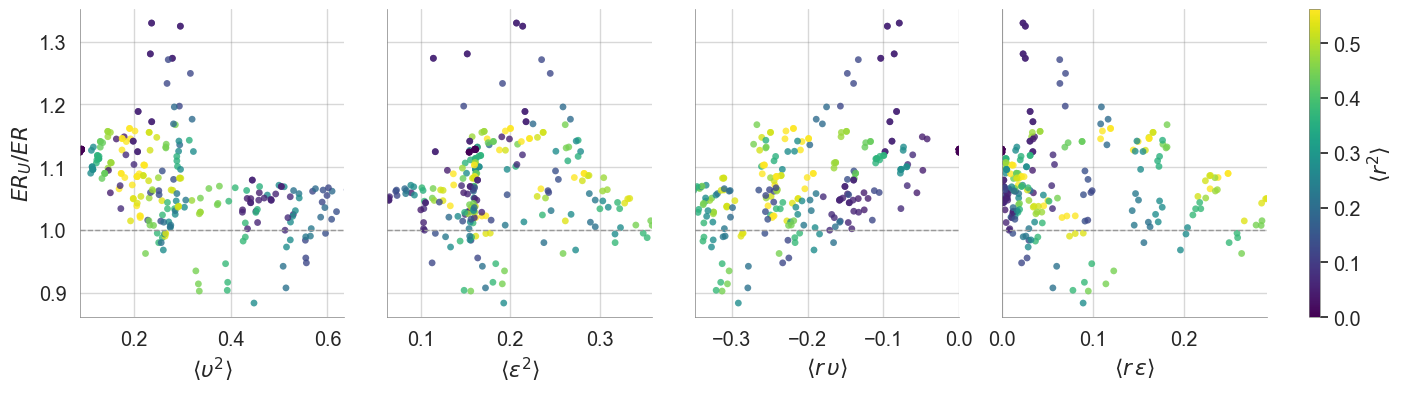

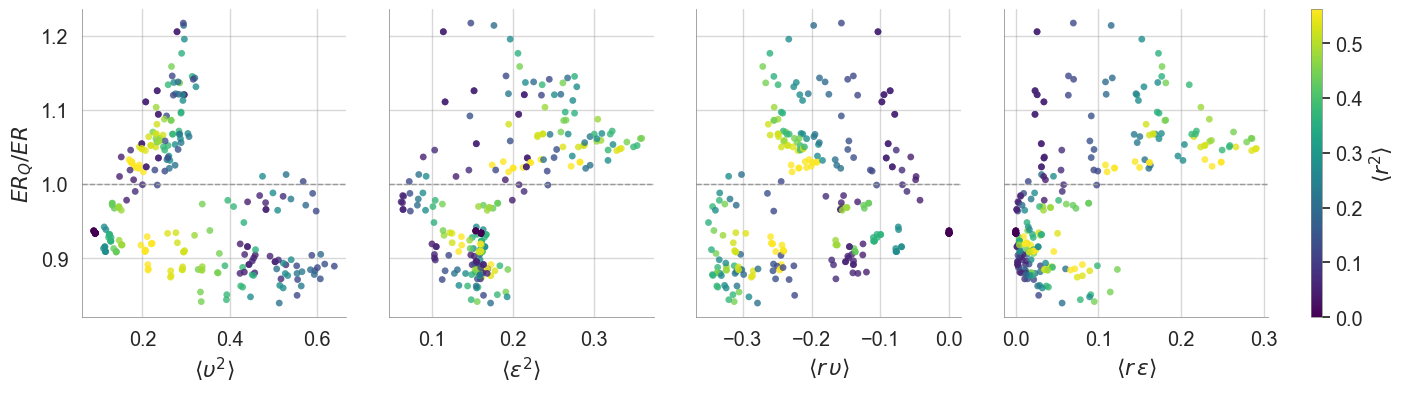

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
from matplotlib.cm import ScalarMappable

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        which: str = "U",            # "U" or "Q"
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_<which>/ER vs <ups2>, <eps2>, <r ups>, <r eps>, colored by <r2>.
    Returns (fig, axes, cbar).
    """
    which = which.upper()
    if which not in ("U", "Q"):
        raise ValueError("which must be 'U' or 'Q'.")

    er_col = {"U": "effect_ratio_U", "Q": "effect_ratio_Q"}[which]

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eps2>", "<r ups>", "<r eps>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Color values (<r2>) and normalization shared across panels
    r2 = df["<r2>"]
    mcolor = r2.notna() & y.notna() & np.isfinite(y)
    if mcolor.sum() == 0:
        raise ValueError("No finite data after filtering and coercion.")
    norm = mcolors.Normalize(vmin=np.nanmin(r2[mcolor]), vmax=np.nanmax(r2[mcolor]))
    cmap = "viridis"

    # Setup figure: 4 plots + colorbar column
    fig = plt.figure(figsize=figsize, constrained_layout=False)
    gs  = gridspec.GridSpec(1, 5, figure=fig, width_ratios=[1,1,1,1,0.04])
    axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
    cax  = fig.add_subplot(gs[0, 4])

    # Panel definitions
    xcols = ["<ups2>", "<eps2>", "<r ups>", "<r eps>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \varepsilon^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\varepsilon\rangle$"]

    # Plot each panel
    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        m = x.notna() & r2.notna() & y.notna() & np.isfinite(y)

        sc = ax.scatter(x[m], y[m], c=r2[m], cmap=cmap, norm=norm,
                        s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        # Optional clipping
        if clip_percentiles is not None and m.any():
            lo, hi = clip_percentiles
            xlo, xhi = np.nanpercentile(x[m], [lo, hi])
            ax.set_xlim(xlo, xhi)

    # Shared y-label on first axis
    axes[0].set_ylabel(fr"$ER_{which}/ER$")
    # Share y-lims across all
    ymin = np.nanmin([a.get_ylim()[0] for a in axes])
    ymax = np.nanmax([a.get_ylim()[1] for a in axes])
    for a in axes:
        a.set_ylim(ymin, ymax)
    yticks = axes[0].get_yticks()
    for a in axes[1:]:
        a.set_yticklabels([])  # show labels on all


    # Shared colorbar
    cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax)
    cb.set_label(r"$\langle r^{2}\rangle$")

    return fig, axes, cb

# Examples:f
fig, axes, cb = plot_er_ratio_4cols(summary, which="U", err_thresh=0.05, clip_percentiles=(.1,99.9))
fig, axes, cb = plot_er_ratio_4cols(summary, which="Q", err_thresh=0.05)


In [60]:
# b_theory  = None

In [61]:
# --- build table (observed & components) ---
cols = ["effect_ratio", "<r2>", "<eps2>", "<r eps>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y    = dfM["effect_ratio"].to_numpy(float)
x_r2 = dfM["<r2>"].to_numpy(float)
x_e2 = dfM["<eps2>"].to_numpy(float)
x_re = dfM["<r eps>"].to_numpy(float)

def fit_ols(X, y):
    """Return (beta, R2, adjR2). X must include intercept column."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    n, p = X.shape
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - y.mean())**2))
    r2 = 1.0 - (sse / sst) if sst > 0 else np.nan
    adjr2 = 1.0 - (1.0 - r2) * (n - 1) / max(n - p, 1)
    return beta, r2, adjr2, yhat

def eval_yhat(yhat, y):
    resid = yhat - y
    bias = float(np.mean(resid))
    mae  = float(np.mean(np.abs(resid)))
    rmse = float(np.sqrt(np.mean(resid**2)))
    sse  = float(np.sum(resid**2))
    sst  = float(np.sum((y - y.mean())**2))
    r2   = 1.0 - (sse/sst) if sst > 0 else np.nan
    return {"bias": bias, "mae": mae, "rmse": rmse, "r2": r2}

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <eps2> + <r eps> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_e2, x_re])
b, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": b[0], "b_<r2>": b[1], "b_<eps2>": b[2], "b_<r eps>": b[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_e2, x_re])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<eps2>": b2[1], "b_<r eps>": b2[2]
})

# ----- Drop <eps2> -----
X_drop_e2 = np.column_stack([np.ones_like(y), x_r2, x_re])
b3, r2_de, adj_de, _ = fit_ols(X_drop_e2, y)
results.append({
    "model": "drop <eps2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<eps2>": np.nan, "b_<r eps>": b3[2]
})

# ----- Drop <r eps> -----
X_drop_re = np.column_stack([np.ones_like(y), x_r2, x_e2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_re, y)
results.append({
    "model": "drop <r eps>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<eps2>": b4[2], "b_<r eps>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<eps2>","b_<r eps>"]
print(res_df[cols_out].round(3).to_string(index=False))



# =========================
# U-based second-order fit
# =========================

# --- build table (observed & U-based components) ---
cols = ["effect_ratio", "<r2>", "<ups2>", "<r ups>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y      = dfM["effect_ratio"].to_numpy(float)
x_r2   = dfM["<r2>"].to_numpy(float)
x_ups2 = dfM["<ups2>"].to_numpy(float)
x_reta = dfM["<r ups>"].to_numpy(float)

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <ups2> + <r ups> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_ups2, x_reta])
bU, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full (U-based)",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": bU[0], "b_<r2>": bU[1], "b_<ups2>": bU[2], "b_<r ups>": bU[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_ups2, x_reta])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<ups2>": b2[1], "b_<r ups>": b2[2]
})

# ----- Drop <ups2> -----
X_drop_ups2 = np.column_stack([np.ones_like(y), x_r2, x_reta])
b3, r2_de, adj_de, _ = fit_ols(X_drop_ups2, y)
results.append({
    "model": "drop <ups2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<ups2>": np.nan, "b_<r ups>": b3[2]
})

# ----- Drop <r ups> -----
X_drop_reta = np.column_stack([np.ones_like(y), x_r2, x_ups2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_reta, y)
results.append({
    "model": "drop <r ups>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<ups2>": b4[2], "b_<r ups>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<ups2>","b_<r ups>"]
print("\n")
print(res_df[cols_out].round(3).to_string(index=False))

# -------------------------------------------------------------------
#  from U-based identity (2nd order):
#   ER ≈ 1 + (1/4)<r2> + (5/4)<ups2> + (5/2)<r ups>
# # -------------------------------------------------------------------
# b_theory_U = np.array([1.0, 0.25, 1.25, 2.50])  # [b0, b_r2, b_ups2, b_r_eta]

# # Pretty-print (aligned)
# labels = ["b0", "b1 (<r2>)", "b2 (<ups2>)", "b3 (<r ups>)"]

# def fmt_row(tag, vals, width=10, prec=3):
#     import numpy as _np
#     def fmt_cell(v):
#         if isinstance(v, (int, float, _np.floating, _np.integer)):
#             return f"{v:>{width}.{prec}f}" if _np.isfinite(v) else f"{str(v):>{width}}"
#         return f"{str(v):>{width}}"
#     return f"{tag:<10}" + " ".join(fmt_cell(v) for v in vals)

# print("\n=== U-based: effect_ratio ~ b0 + b1*<r2> + b2*<ups2> + b3*<r ups> ===")
# print("Approximation: effect_ratio ≈ 1 + (1/4)<r2> + (5/4)<ups2> + (5/2)<r ups>")
# print(fmt_row("coef",     labels, prec=0))
# print(fmt_row("estimate", [bU[0], bU[1], bU[2], bU[3]]))
# print(fmt_row("theory",   b_theory_U))

# # Theory (linear) metrics vs observed
# yhat_U_lin = b_theory_U[0] + b_theory_U[1]*x_r2 + b_theory_U[2]*x_ups2 + b_theory_U[3]*x_reta
# m_U_lin = eval_yhat(yhat_U_lin, y)

# print(f"\n U-based metrics: bias={m_U_lin['bias']:.3f}, "
#       f"mae={m_U_lin['mae']:.3f}, rmse={m_U_lin['rmse']:.3f}, r2={m_U_lin['r2']:.3f}")



# -------------------------------------------------------------------
#  THEORY from discharge result
#   Linearized (1/(1+A) ≈ 1 - A):  ER ≈ 1 - <r2> - (5/9)<eps2> + (5/3)<r eps>
#   Nonlinear:                     ER_th = 1 / (1 + <r2> + (5/9)<eps2> - (5/3)<r eps>)
# -------------------------------------------------------------------
# Pretty print: coefficients for effect_ratio ~ b0 + b1*<r2> + b2*<eps2> + b3*<r eps>
labels = ["b0", "b1 (<r2>)", "b2 (<eps2>)", "b3 (<r eps>)"]

def fmt_row(tag, vals, width=10, prec=3):
    def fmt_cell(v):
        # numbers -> fixed width with decimals; strings/NaNs -> right-aligned text
        if isinstance(v, (int, float, np.floating, np.integer)):
            return f"{v:>{width}.{prec}f}" if np.isfinite(v) else f"{str(v):>{width}}"
        return f"{str(v):>{width}}"
    return f"{tag:<10}" + " ".join(fmt_cell(v) for v in vals)

h_labels = ["b0", "b1 (<r2>)", "b2 (<eps2>)", "b3 (<r eps>)"]
b_theory = np.array([1.0, -1.0, -(5.0/9.0), +(5.0/3.0)])


print("\n=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eps2> + b3*<r eps> ===")
print("Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eps2> + (5/3)<r eps>")
print(fmt_row("coef",     h_labels, prec=0))
print(fmt_row("estimate", [b[0], b[1], b[2], b[3]]))
print(fmt_row("theory",   b_theory))


print("\n=== U-based:  ER ≈ b0 + b1*<r2> + b2*<ups2> + b3*<r ups> ===")
print("Theory (linear):  ER ≈ 1/4·<r2> + 5/4·<ups2> + 5/2·<r ups> + 1")
u_labels = ["b0", "b1 (<r2>)", "b2 (<ups2>)", "b3 (<r ups>)"]
b_theory_U = np.array([1.0, 0.25, 1.25, 2.50])
print(fmt_row("coef",     u_labels, prec=0))
print(fmt_row("estimate", [bU[0], bU[1], bU[2], bU[3]]))
print(fmt_row("theory",   b_theory_U))





       model    R2  ΔR2 (vs full)  adjR2  ΔadjR2 (vs full)    b0  b_<r2>  b_<eps2>  b_<r eps>
        full 0.335          0.000  0.327             0.000 0.798  -0.216     0.494     -0.453
   drop <r2> 0.169         -0.166  0.163            -0.165 0.728     NaN     0.677     -0.800
 drop <eps2> 0.300         -0.035  0.294            -0.033 0.868  -0.233       NaN     -0.101
drop <r eps> 0.294         -0.041  0.288            -0.039 0.859  -0.258     0.044        NaN


         model    R2  ΔR2 (vs full)  adjR2  ΔadjR2 (vs full)    b0  b_<r2>  b_<ups2>  b_<r ups>
full (U-based) 0.691          0.000  0.687             0.000 0.914   0.085     0.184      1.021
     drop <r2> 0.686         -0.005  0.683            -0.004 0.930     NaN     0.088      0.835
   drop <ups2> 0.677         -0.014  0.674            -0.013 0.943  -0.041       NaN      0.709
  drop <r ups> 0.566         -0.125  0.562            -0.125 0.978  -0.310    -0.323        NaN

=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eps2> + b

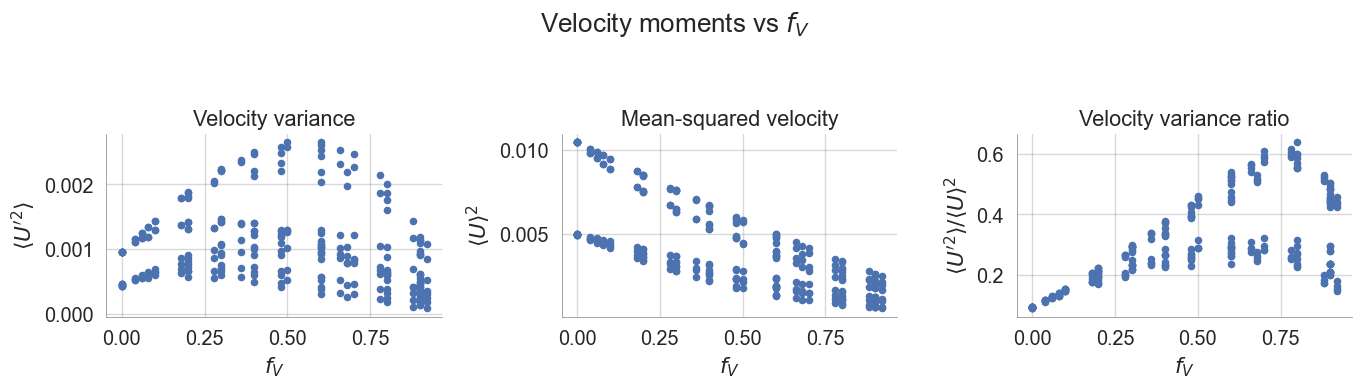

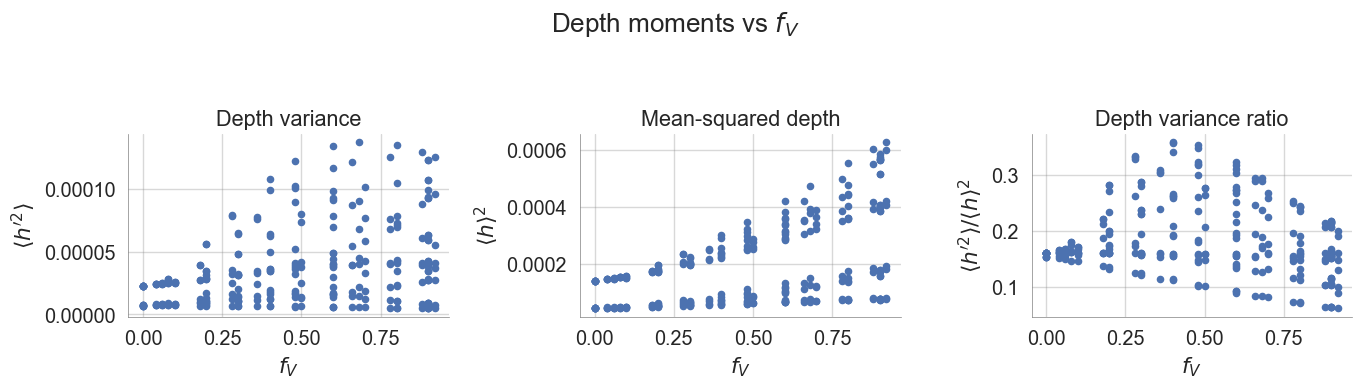

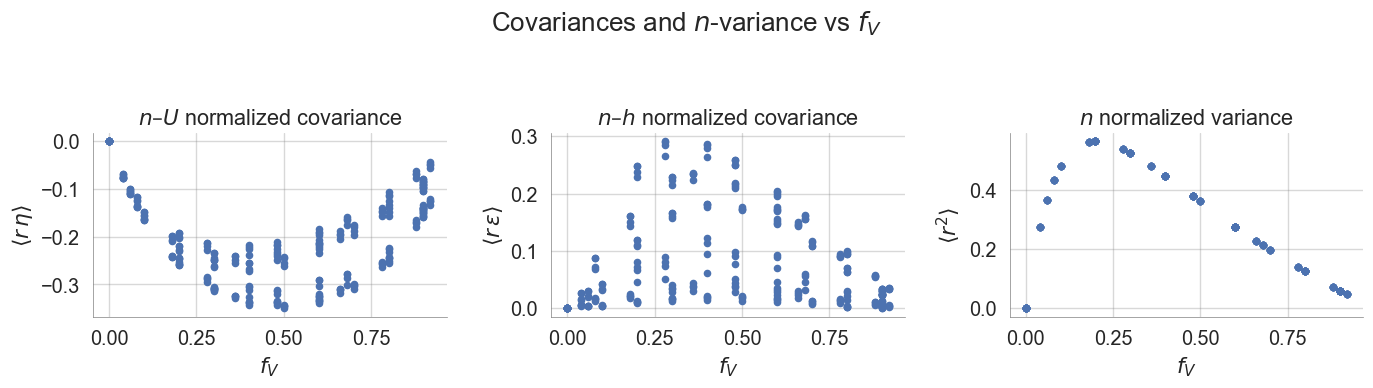

In [62]:
import matplotlib.pyplot as plt

# ---------- Velocity moments ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<Up2>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle U^{\prime 2}\rangle$")
axes[0].set_title("Velocity variance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<U>"]**2, 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle U\rangle^2$")
axes[1].set_title("Mean-squared velocity")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<Up2>"]/summary["<U>"]**2, 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle U^{\prime 2}\rangle/\langle U\rangle^2$")
axes[2].set_title("Velocity variance ratio")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Velocity moments vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


# ---------- Depth moments ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<hp2>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle h^{\prime 2}\rangle$")
axes[0].set_title("Depth variance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<h>"]**2, 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle h\rangle^2$")
axes[1].set_title("Mean-squared depth")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<hp2>"]/summary["<h>"]**2, 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle h^{\prime 2}\rangle/\langle h\rangle^2$")
axes[2].set_title("Depth variance ratio")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Depth moments vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


# ---------- Cross-covariances & n-variance ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<r ups>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle r\,\eta\rangle$")
axes[0].set_title(r"$n$–$U$ normalized covariance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<r eps>"], 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle r\,\varepsilon\rangle$")
axes[1].set_title(r"$n$–$h$ normalized covariance")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<r2>"], 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle r^2\rangle$")
axes[2].set_title(r"$n$ normalized variance")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Covariances and $n$-variance vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


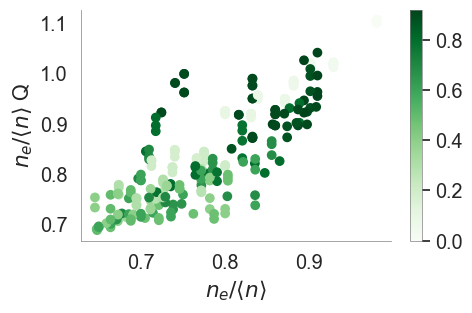

In [63]:
# plt.scatter(summary.query("hydro_err < 0.05")['effect_ratio'], 
#             summary.query("hydro_err < 0.05")['effect_ratio_U'],
#            c = summary.query("hydro_err < 0.05")['fV'],cmap = 'Greens', vmin = 0)

plt.scatter(summary.query("hydro_err < 0.05")['effect_ratio'], 
            summary.query("hydro_err < 0.05")['effect_ratio_U'],
           c = summary.query("hydro_err < 0.05")['fV'],cmap = 'Greens', vmin = 0)

plt.xlabel(r"$n_e/\langle n \rangle$")
plt.ylabel(r"$n_e/\langle n \rangle$ Q")
plt.colorbar()

# plt.xlim(0, 0.7)
# plt.ylim(0, 0.7)

In [64]:
summary[['<n><U>','<np Up>', '<nU>']].corr().round(2)

,<n><U>,<np Up>,<nU>
<n><U>,1.0,-0.70,0.90
<np Up>,-0.7,1.00,-0.32
<nU>,0.9,-0.32,1.00


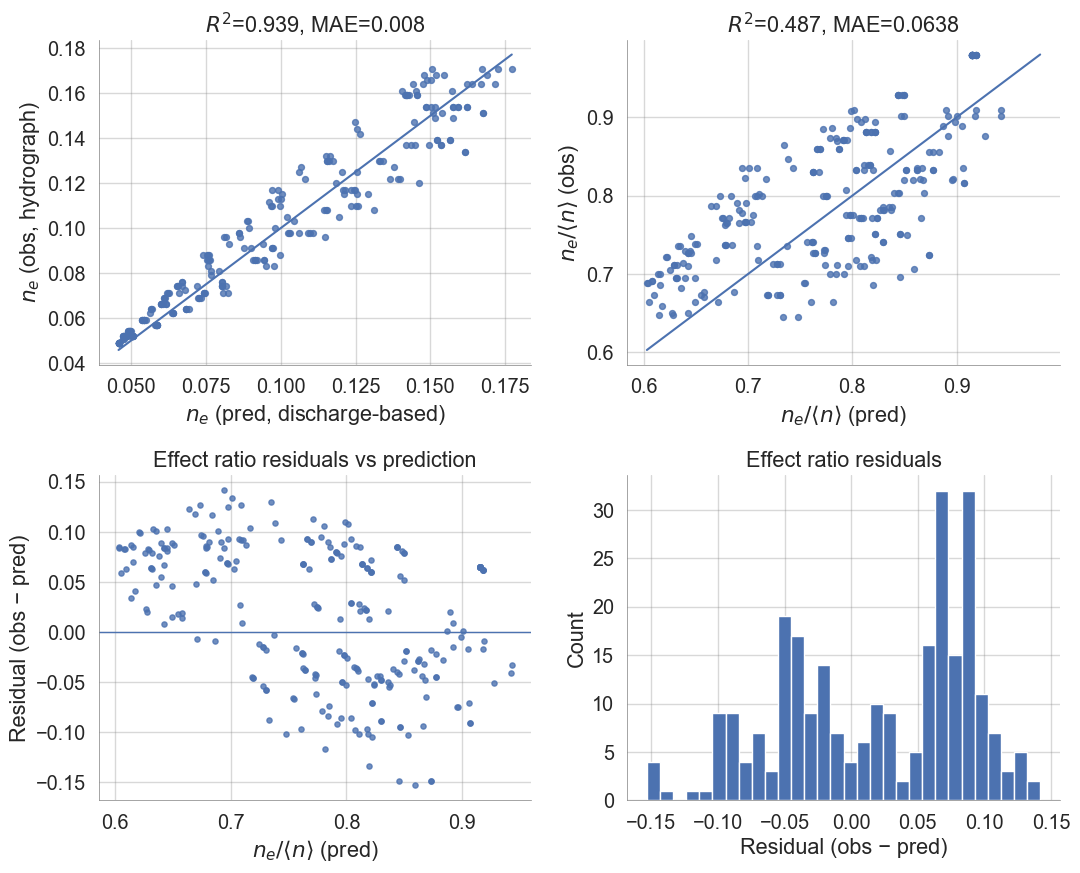

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Discharge-based n_e prediction (per time slice i_tr) ---
def ne_from_Q(sim):
    i = int(sim.i_tr)
    h = np.asarray(sim.hc, float)[i]          # (ny, nx)
    veg = np.asarray(sim.veg)                 # (ny, nx) 0/1
    n = veg.astype(float)
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)
    inv_ne = np.nanmean((1.0 / n) * (h / np.nanmean(h))**(5/3))
    return 1.0 / inv_ne

summary['n_e_Qpred'] = summary.apply(ne_from_Q, axis=1)
summary['er_Qpred']  = summary['n_e_Qpred'] / summary['<n>']   # predicted effect ratio

# observed (from hydrograph) — adjust names if yours differ
er_obs = summary['effect_ratio'].to_numpy(float)
er_hat = summary['er_Qpred'].to_numpy(float)

ne_obs = summary['r_equiv5'].to_numpy(float)
ne_hat = summary['n_e_Qpred'].to_numpy(float)

# finite masks
m_er = np.isfinite(er_obs) & np.isfinite(er_hat)
m_ne = np.isfinite(ne_obs) & np.isfinite(ne_hat)

def r2(x, y):
    if np.sum(np.isfinite(x) & np.isfinite(y)) < 3:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1]**2)

def mae(x, y):
    return float(np.nanmean(np.abs(x - y)))

# --- 2) Plots: predicted vs observed + residual diagnostics ---
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
(ax1, ax2), (ax3, ax4) = axs

# A: n_e (pred vs obs)
x, y = ne_hat[m_ne], ne_obs[m_ne]
ax1.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax1.plot([mn, mx], [mn, mx])  # 1:1
ax1.set_xlabel(r"$n_e$ (pred, discharge-based)")
ax1.set_ylabel(r"$n_e$ (obs, hydrograph)")
ax1.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax1.grid(True, alpha=0.3)

# B: effect ratio (pred vs obs)
x, y = er_hat[m_er], er_obs[m_er]
ax2.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax2.plot([mn, mx], [mn, mx])  # 1:1
ax2.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax2.set_ylabel(r"$n_e/\langle n\rangle$ (obs)")
ax2.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax2.grid(True, alpha=0.3)

# C: residuals vs predicted (effect ratio)
res = (er_obs[m_er] - er_hat[m_er])
ax3.scatter(er_hat[m_er], res, s=14, alpha=0.8)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax3.set_ylabel("Residual (obs − pred)")
ax3.set_title("Effect ratio residuals vs prediction")
ax3.grid(True, alpha=0.3)

# D: residual histogram (effect ratio)
ax4.hist(res[~np.isnan(res)], bins=30)
ax4.set_xlabel("Residual (obs − pred)")
ax4.set_ylabel("Count")
ax4.set_title("Effect ratio residuals")
ax4.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


In [66]:
plt.plot(summary.query("fV == 0.95").iloc[0].hydro)
plt.plot(summary.query("fV == 0.95").iloc[0].equiv_hydro)

IndexError: single positional indexer is out-of-bounds

In [ ]:
summary['<Sf>_exp2'].mean(),  summary['<Sf>_direct'].mean(), summary['<Sf>_hyb_num_sum'].mean()

In [ ]:
cols = [c for c in summary.columns if '<Sf>' in c]
cols.sort()

In [ ]:
(summary['<Up2>']/summary['<U>']**2).describe()
# summary['<hp2>']/summary['<h>']**2

In [ ]:
# save_df = summary.iloc[::60]

## Add tracers

In [ ]:
# reload modules
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", "plot_config", 
              "topo", "run_around",
              "source_functions_1p3"]

for mod in my_modules :
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *

from run_around import *
from source_functions_1p3 import *



In [ ]:
%%time
from tqdm import tqdm
from multiprocess import Pool


tracer_cols = [ 'y_f', 'y_i', 'x_f', 'x_i', 't_f', 't_i', 'veg_bin',
        'std_x',  't_esc', 'residence', 'length','escape', 'escape_in_domain', 
        'time_to_escape', 'time_to_infiltrate', 'distance']

# params = {"h_min" : 1e-4, "y_min" : 1, "t_min" : 1, 'N' : 2000, "initialize" : 'top'}
params = {"h_min" : 1e-3, "y_min" : 1,  "t_min" : 1, 'N' : 1000}
tracer_name = ",".join(["{0}-{1}".format(key, val) for key,val in params.items() ])
print (tracer_name)

def parallel_tracers(key):

    sim = summary.loc[key]  

    if sim.Tbound == 4:
        periodic = 1
    else: 
        periodic = 0
        
    if 't_scale' not in params.keys():
        params.update({"t_scale" : 1})
        t_scale = 1

        
    if 'initialize' not in params.keys():
        params.update({"initialize" : False})
        initialize = False
    
    if sim.Tbound == 4:
        periodic = 1
    else: 
        periodic = 0
            
    positions, recap = integrate_positions(sim, N = params['N'],  initialize = params['initialize'], 
        t_min = params['t_min'],  y_min = params['y_min'], h_min = params['h_min'], 
        t_scale = params['t_scale'], periodic = periodic)
    
    for key, item in params.items():
        
        recap[key]= item

    for fld in tracer_cols: 
        recap[fld] = positions[fld]    

    return recap

run_tracers = 1

if run_tracers:
    
    max_pool = 8
    
    with Pool(max_pool) as p:
        pool_outputs = list(
            tqdm(
                p.imap(parallel_tracers,
                      summary.index),
                total=len(summary)
            )
        )    

    paired = pd.concat(pool_outputs)
    print(paired.shape)

    tracers = pd.DataFrame()
    tracer_cols = pool_outputs[0].index
    for fld in tracer_cols:
        tracers = insert_fld(tracers,fld)

    for i, key in enumerate(summary.index):
        tracers.loc[key] = pool_outputs[i]
        
    tracers.to_pickle(os.path.join(out_dir, tracer_name + ".pkl"))

    shutil.copy("/Users/octaviacrompton/Projects/roughness-scale/blob_code/source_functions_1p3.py", out_dir  + "/code/" + tracer_name + "_source_1p3.py" );        
    print ("saving: " + tracer_name)
else:
    tracers = pd.read_pickle(os.path.join(out_dir, tracer_name + ".pkl"))
    print ("reading: " +  tracer_name)
    
save_cols = ['scenario', 'r', 'Re_all', 'tr', 'p', 'fV', 'Ks_v', 
        'sigma', 'phi_veg', 'l', 'L',  'C', 'infl_frac']

summary[[col for col in save_cols if col in summary]].to_pickle(
    out_dir + "/summary_abrev.pkl")    

# tracers = pd.read_pickle(out_dir + "/" + tracer_name + ".pkl")

try:
    summary = delete_tracers(summary, tracers)
    summary = add_tracers(summary, tracers)

    
except:
    summary = add_tracers(summary, tracers)


In [ ]:

cfld = 'curve'
subset = summary.query("L > 0")
plt.scatter(1- subset.infl_frac, (subset.tracer_err  ), c = subset[cfld], 
            cmap = "coolwarm")

plt.xlabel("$C$");
plt.ylabel("$C$ error");

plt.colorbar(label = format_name(cfld));



In [ ]:
summary[r'$p t_r$'] = summary['tr']*summary['p']/60
cfld = r'$p t_r$'
subset = summary
plt.scatter(subset.IF, (subset.tracer_IF), c = subset[cfld], 
            cmap = "coolwarm")

plt.plot(subset.IF, (subset.IF))
plt.xlabel("$IF$");
plt.ylabel("tracer $IF$");

plt.colorbar(label = (cfld));

In [ ]:

# observed (from hydrograph) — adjust names if yours differ
er_obs = summary['effect_ratio'].to_numpy(float)
er_hat = summary['effect_ratio_Q'].to_numpy(float)

ne_obs = summary['r_equiv5'].to_numpy(float)
ne_hat = summary['n_e_Qpred'].to_numpy(float)

# finite masks
m_er = np.isfinite(er_obs) & np.isfinite(er_hat)
m_ne = np.isfinite(ne_obs) & np.isfinite(ne_hat)

def r2(x, y):
    if np.sum(np.isfinite(x) & np.isfinite(y)) < 3:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1]**2)

def mae(x, y):
    return float(np.nanmean(np.abs(x - y)))

# --- 2) Plots: predicted vs observed + residual diagnostics ---
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
(ax1, ax2), (ax3, ax4) = axs

# A: n_e (pred vs obs)
x, y = ne_hat[m_ne], ne_obs[m_ne]
ax1.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax1.plot([mn, mx], [mn, mx])  # 1:1
ax1.set_xlabel(r"$n_e$ (pred, discharge-based)")
ax1.set_ylabel(r"$n_e$ (obs, hydrograph)")
ax1.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax1.grid(True, alpha=0.3)

# B: effect ratio (pred vs obs)
x, y = er_hat[m_er], er_obs[m_er]
ax2.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax2.plot([mn, mx], [mn, mx])  # 1:1
ax2.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax2.set_ylabel(r"$n_e/\langle n\rangle$ (obs)")
ax2.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax2.grid(True, alpha=0.3)

# C: residuals vs predicted (effect ratio)
res = (er_obs[m_er] - er_hat[m_er])
ax3.scatter(er_hat[m_er], res, s=14, alpha=0.8)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax3.set_ylabel("Residual (obs − pred)")
ax3.set_title("Effect ratio residuals vs prediction")
ax3.grid(True, alpha=0.3)

# D: residual histogram (effect ratio)
ax4.hist(res[~np.isnan(res)], bins=30)
ax4.set_xlabel("Residual (obs − pred)")
ax4.set_ylabel("Count")
ax4.set_title("Effect ratio residuals")
ax4.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# How does source and source_1p3 differ?


## Simplify dfs

In [ ]:
# Quick + simple: list the largest variables in your current environment.
# - Handles numpy/pandas/xarray/torch specially; everything else via getsizeof.
# - No deep inspection; fast and concise.

import sys, inspect

def _size_bytes(obj):
    try:
        import xarray as xr
    except Exception:
        xr = None
    try:
        import torch
    except Exception:
        torch = None

    # Common scientific types
    if isinstance(obj, np.ndarray):
        return obj.nbytes
    if isinstance(obj, pd.DataFrame):
        return int(obj.memory_usage(deep=True).sum())
    if isinstance(obj, pd.Series):
        return int(obj.memory_usage(deep=True))
    if xr is not None:
        if isinstance(obj, xr.DataArray):
            return int(obj.nbytes)
        if isinstance(obj, xr.Dataset):
            return int(sum(v.nbytes for v in obj.data_vars.values()))
    if torch is not None and isinstance(obj, torch.Tensor):
        try:
            return int(obj.element_size() * obj.nelement())
        except Exception:
            pass
    # Fallback
    try:
        return int(sys.getsizeof(obj))
    except Exception:
        return 0

def _shape_or_len(obj):
    for attr in ("shape",):
        if hasattr(obj, attr):
            try:
                return tuple(getattr(obj, attr))
            except Exception:
                pass
    try:
        return len(obj)
    except Exception:
        return None

def memtable(top_n=30, min_mb=1.0, namespace=None):
    """Return a DataFrame of the largest variables (>= min_mb) in `namespace`."""
    if namespace is None:
        # Merge globals + caller locals (best effort)
        frm = inspect.currentframe().f_back
        namespace = {}
        namespace.update(getattr(frm, "f_globals", {}))
        namespace.update(getattr(frm, "f_locals", {}))

    rows = []
    seen = set()
    for name, obj in namespace.items():
        if name.startswith("_"):          # skip privates/dunders
            continue
        oid = id(obj)
        if oid in seen:                   # skip aliases
            continue
        seen.add(oid)
        # skip modules/functions/classes
        if hasattr(obj, "__module__") and str(type(obj)).startswith("<class 'module'"):
            continue
        if callable(obj):
            continue

        sz = _size_bytes(obj)
        mb = sz / (1024**2)
        if mb < min_mb:
            continue
        rows.append({
            "name": name,
            "type": type(obj).__name__,
            "shape/len": _shape_or_len(obj),
            "MB": round(mb, 3),
        })

    if not rows:
        return pd.DataFrame(columns=["name","type","shape/len","MB"])

    df = pd.DataFrame(rows).sort_values("MB", ascending=False).head(top_n).reset_index(drop=True)
    return df

# ---- usage
# Show top 25 variables >= 1 MB
memtable(top_n=25, min_mb=1.0)
# You can then delete big ones and gc.collect() if needed.



In [ ]:

def _is_arraylike_3d(obj, min_ndim=3, min_size=0):
    """True if obj behaves like a NumPy array with ndim >= min_ndim and size >= min_size."""
    # xarray.DataArray has .values; fall back gracefully
    try:
        if hasattr(obj, "values") and hasattr(obj, "ndim") and hasattr(obj, "size"):
            arr = obj.values
        elif isinstance(obj, np.ndarray):
            arr = obj
        else:
            return False
        return (arr.ndim >= min_ndim) and (arr.size >= min_size)
    except Exception:
        return False
    
    

def find_3d_array_columns(df: pd.DataFrame, min_ndim=3, min_size=0, sample_rows=50):
    """
    Inspect up to `sample_rows` non-null rows per column to decide if the column
    stores 3D (or higher) arrays of at least `min_size` elements.
    Returns a list of column names to drop and a summary dict.
    """
    to_check = df.columns.tolist()
    cols_to_drop = []
    report = {}

    # limit scans for speed
    idx = df.index
    if len(idx) > sample_rows:
        idx = df.index[:sample_rows]

    for col in to_check:
        # quick skip: non-object dtypes rarely store arrays
        if df[col].dtype != "object":
            # but still peek at a couple values in case of mixed types
            candidates = df[col].iloc[:min(len(idx), 3)]
        else:
            candidates = df.loc[idx, col]

        found = False
        shapes = []
        for v in candidates:
            if _is_arraylike_3d(v, min_ndim=min_ndim, min_size=min_size):
                # capture a shape string if possible
                try:
                    shp = (v.values.shape if hasattr(v, "values") else v.shape)
                    shapes.append(tuple(shp))
                except Exception:
                    shapes.append(("unknown",))
                found = True
        if found:
            cols_to_drop.append(col)
            report[col] = {"shapes_seen": list({s for s in shapes if s is not None})}

    return cols_to_drop, report

# cols_to_drop, rep = find_3d_array_columns(summary, min_ndim=3, min_size=3)
# summary.drop(columns=cols_to_drop, inplace=True)


# cols_to_drop, rep = find_3d_array_columns(subset, min_ndim=3, min_size=3)
# subset.drop(columns=cols_to_drop, inplace=True)

## Evaluate hybrid

In [ ]:
# ---------- pick rows & resolve column names ----------
subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# ground truth <Sf>
direct_col = next((c for c in ["<Sf>", "<Sf>_direct"] if c in subset.columns), None)
if direct_col is None:
    raise KeyError("Need '<Sf>' or '<Sf>_direct' in the dataframe.")

# ---------- hybrid approximation (preferred only) ----------
hybrid_prefs = ["<Sf>_hybrid_quad", "<Sf>_hybrid2", "<Sf>_hybrid"]
hybrid_col = next((c for c in hybrid_prefs if c in subset.columns), None)

# fallback to a pure series if no hybrid present (still "only one curve" on plots)
if hybrid_col is None:
    series_prefs = ["<Sf>_exp2", "<Sf>_series2", "<Sf>_approx", "<Sf>_approx2"]
    hybrid_col = next((c for c in series_prefs if c in subset.columns), None)
    if hybrid_col is None:
        raise KeyError("No hybrid/series/approx column found.")

# ---------- labels ----------
term_labels = {
    direct_col: r"$\langle S_f\rangle$",
    hybrid_col: r"$\langle S_f\rangle_{\rm hybrid}$" if "hybrid" in hybrid_col else r"$\langle S_f\rangle_{\rm series}$",
}

# ---------- metrics ----------
def _err_stats(pred, truth):
    e = pred - truth
    m = np.isfinite(e) & np.isfinite(truth) & np.isfinite(pred)
    if m.sum() == 0:
        return dict(bias=np.nan, mae=np.nan, rmse=np.nan, mape=np.nan, r2=np.nan)
    bias = np.nanmean(e[m])
    mae  = np.nanmean(np.abs(e[m]))
    rmse = np.sqrt(np.nanmean(e[m]**2))
    denom = np.where(np.abs(truth[m]) > 1e-12, np.abs(truth[m]), np.nan)
    mape = np.nanmean(np.abs(e[m]) / denom)
    r = np.corrcoef(pred[m], truth[m])[0,1] if m.sum() > 2 else np.nan
    r2 = (r*r if np.isfinite(r) else np.nan)
    return dict(bias=bias, mae=mae, rmse=rmse, mape=mape, r2=r2)

# ---------- data ----------
y_true = subset[direct_col].to_numpy()
y_hyb  = subset[hybrid_col].to_numpy()
stats  = _err_stats(y_hyb, y_true)

print("\n=== Hybrid vs direct ===")
print("Hybrid column:", hybrid_col)
print({k: float(v) for k,v in stats.items()})

# =========================================================
# Two subplots: (1) hybrid vs direct, (2) histogram of error
# =========================================================
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5.2))
plt.subplots_adjust(wspace=0.35)

# ---- (1) scatter: hybrid vs direct ----
m = np.isfinite(y_true) & np.isfinite(y_hyb)
ax_scatter.scatter(y_hyb[m], y_true[m], s=30, alpha=0.75, marker='.', label=term_labels[hybrid_col])

# 1:1 line + bounds
if m.any():
    lo = np.nanmin(np.concatenate([y_true[m], y_hyb[m]]))
    hi = np.nanmax(np.concatenate([y_true[m], y_hyb[m]]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    a, b = lo - pad, hi + pad
    ax_scatter.plot([a, b], [a, b], lw=1.0, alpha=0.6, linestyle='--', color='k')
    ax_scatter.set_xlim(a, b)
    ax_scatter.set_ylim(a, b)

ax_scatter.set_xlabel(term_labels[hybrid_col])
ax_scatter.set_ylabel(term_labels[direct_col])
ax_scatter.set_title(r"Hybrid vs $\langle S_f\rangle$")
ax_scatter.grid(True, alpha=0.3)


# Annotate stats on the plot (3 decimals; MAPE in %)
txt = (
    fr"$R^2$ = {stats['r2']:.3f}" + "\n" +
    fr"bias = {stats['bias']:.3f}" + "\n" +
    fr"MAE = {stats['mae']:.3f}" + "\n" +
    fr"RMSE = {stats['rmse']:.3f}" + "\n" +
    (fr"MAPE = {100.0*stats['mape']:.1f}%" if np.isfinite(stats['mape']) else "MAPE = —")
)
# place in upper left of axes coords
ax_scatter.text(0.02, 0.98, txt, transform=ax_scatter.transAxes,
                va='top', ha='left', 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.9))

# ---- (2) histogram: hybrid error ----
err = y_hyb - y_true
err_finite = err[np.isfinite(err)]
ax_hist.hist(err_finite, bins=30, alpha=0.85)
ax_hist.set_title("Hybrid error: (hybrid − direct)")
ax_hist.set_xlabel("Error")
ax_hist.set_ylabel("Count")
ax_hist.grid(True, alpha=0.3)
plt.tight_layout()



In [ ]:
summary.query("hydro_err < 0.3")[
    [c for c in summary.columns if 'Sf' in c and 'nd' not in c and 'hyb' not in c 
        and 'direct' not in c] + ['effect_ratio']].corr()[['effect_ratio','<Sf>', '<Sf>_nbar2_Ubar2']
                                                         ].sort_values(by = 'effect_ratio').round(3)

In [ ]:
summary = summary[[c for c in summary.columns if 'norm' not in c]]

## Decomposition terms vs effect_ratio 

In [ ]:
# =======================================================================
# Individual decomposition terms vs effect_ratio 
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Optional, Dict, Tuple, List

# ------------------------------ helpers ------------------------------
def palette(n: int) -> List:
    base = 'tab10' if n <= 10 else 'tab20'
    cmap = plt.get_cmap(base)
    return [cmap(i % cmap.N) for i in range(max(n, 1))]


def factorize_categorical_rounded(df: pd.DataFrame, cat_col: str) -> Tuple[np.ndarray, list]:
    """Factorize a categorical column; if numeric-like, format labels to 2 decimals."""
    if cat_col in df.columns:
        cats = df[cat_col].astype("category")
        codes = cats.cat.codes.to_numpy()
        names = []
        for x in cats.cat.categories:
            try:
                names.append(f"{float(x):.2f}")
            except (ValueError, TypeError):
                names.append(str(x))
    else:
        codes = np.zeros(len(df), dtype=int)
        names = ["all"]
    return codes, names




def default_math_labels() -> Dict[str, str]:
    return {
        '<Sf>_nbar2_Ubar2': r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U\rangle^2$",
        '<Sf>_nbar2_Up2':   r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U'^2\rangle$",
        '<Sf>_Ubar2_np2':   r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle n'^2\rangle$",
        '<Sf>_cross_nU':    r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle n'U'\rangle$",
        '<Sf>_C_Uphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle n\rangle^2\,\langle U\rangle\,\langle U'h'\rangle$",
        '<Sf>_C_nphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle U\rangle^2\,\langle n\rangle\,\langle n'h'\rangle$",
        '<Sf>_h2':       r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^2\,\langle U\rangle^2\,\langle (h')^2\rangle$",
        '<Sf>_hyb_Up2':     r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle w_{\rm hyb}\,U'^2\rangle$",
        '<Sf>_hyb_np2':     r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle w_{\rm hyb}\,n'^2\rangle$",
        '<Sf>_hyb_cross':   r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle w_{\rm hyb}\,n'U'\rangle$",
    }


In [ ]:

from typing import List, Tuple, Optional
import numpy as np
import pandas as pd

def _compute_limits_union_xy(
    df: pd.DataFrame,
    pairs: List[Tuple[str, str]],
    pad_frac: float = 0.05,) -> Optional[Tuple[Tuple[float, float], Tuple[float, float]]]:
    """
    Compute global x/y axis limits that cover multiple (xcol, ycol) pairs.

    For each pair, finite values are used to expand a running min/max.
    A fractional padding `pad_frac` is added to both ends of each axis.

    """
    xmin = ymin = np.inf
    xmax = ymax = -np.inf

    for xcol, ycol in pairs:
        if (xcol not in df.columns) or (ycol not in df.columns):
            continue
        x = df[xcol].to_numpy()
        y = df[ycol].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if not np.any(m):
            continue
        xmin = min(xmin, float(np.nanmin(x[m])))
        xmax = max(xmax, float(np.nanmax(x[m])))
        ymin = min(ymin, float(np.nanmin(y[m])))
        ymax = max(ymax, float(np.nanmax(y[m])))

    if not np.isfinite([xmin, xmax, ymin, ymax]).all():
        return None

    # Avoid zero span; pad based on span or magnitude fallback
    xspan = (xmax - xmin) if xmax > xmin else (abs(xmax) + 1.0)
    yspan = (ymax - ymin) if ymax > ymin else (abs(ymax) + 1.0)

    xpad = pad_frac * xspan
    ypad = pad_frac * yspan

    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)


def collect_individual_sf_terms(df: pd.DataFrame,
                                include_hybrid_terms: bool = False,
                                exclude_base: bool = True) -> List[str]:
    """one
    Collect 'individual' <Sf>_* terms (exclude sums/approximations/etc.).
    Optionally include '<Sf>_hyb_*' pieces. Explicitly exclude any '*_base'.
    """
    exclude_exact = {"<Sf>_T0", "<Sf>_T1", "<Sf>_T2", "<Sf>_T0*", "<Sf>_T1*", "<Sf>_T2*"}
    exclude_substrings = [
        "hybrid",  
        "nd_", "sumK", "baseline", "series", "approx", "exp", 'hyb',
        "direct", "frac_series", "_share_abs", "norm", "error", "err"
    ]
    all_sf_cols = [c for c in df.columns if c.startswith("<Sf>_")]
    all_sf_cols = [c for c in all_sf_cols if 'hyb' not in c]


    terms = []
    for c in all_sf_cols:
        if c in exclude_exact:
            continue
        if exclude_base and ("_base" in c):
            continue
        # allow '<Sf>_hyb_*' only when requested
        if c.startswith("<Sf>_hyb_"):
            if include_hybrid_terms:
                terms.append(c)
            continue
        if any(s in c for s in exclude_substrings):
            continue
        terms.append(c)
    print(terms)
    # dedupe (preserve order)
    seen, ordered = set(), []
    for c in terms:
        if c not in seen:
            ordered.append(c); seen.add(c)
    return ordered

def compute_correlations(df: pd.DataFrame,
                         predictors: List[str],
                         effect_col: str = "effect_ratio",
                         top_n: int = 9) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Return full correlation table and a rounded top-N display table."""
    if effect_col not in df.columns:
        return (pd.DataFrame(columns=["predictor","pearson_r","r2"]),
                pd.DataFrame(columns=["predictor","pearson_r","r2"]))
    y = df[effect_col].to_numpy()
    rows = []
    for col in predictors:
        if col not in df.columns:
            continue
        x = df[col].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            continue
        r = np.corrcoef(x[m], y[m])[0, 1]
        rows.append((col, r, r*r))
    corr_df = pd.DataFrame(rows, columns=["predictor", "pearson_r", "r2"]).sort_values("r2", ascending=False)
    disp = corr_df.head(top_n).copy()
    disp["pearson_r"] = disp["pearson_r"].round(3)
    disp["r2"]        = disp["r2"].round(3)
    return corr_df, disp



In [ ]:

# === Modular decomposition → tables → plots (no one-shot orchestrator) ===
from typing import List, Tuple, Dict, Optional
from matplotlib.lines import Line2D

def greens_palette(n: int, cmap_name: str = "Greens", start: float = 0.25, stop: float = 0.90):
    """
    n evenly-spaced colors from a green colormap.
    start/stop control the light↔dark range (0..1).
    """
    n = max(int(n), 1)
    cmap = plt.get_cmap(cmap_name)
    ts = np.linspace(start, stop, n)
    return [cmap(t) for t in ts]


# ---------- 1) Tables-only: gather predictors and compute correlations ----------
def build_decomp_predictor_tables(
    df: pd.DataFrame,
    effect_col: str = "effect_ratio",
    include_hybrid_terms: bool = False,
    exclude_base: bool = True,
    top_n: int = 9,) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, str]]:
    """
    Build correlation tables for unnormalized <Sf>_* decomposition terms vs `effect_col`.

    Returns
    -------
    corr_df : pd.DataFrame
        Full table with columns ["predictor","pearson_r","r2"], sorted by r2 desc.
    disp_table : pd.DataFrame
        Top-N rounded subset for display.
    labels : Dict[str, str]
        Math label map from `default_math_labels()`.
    """
    if effect_col not in df.columns:
        empty = pd.DataFrame(columns=["predictor", "pearson_r", "r2"])
        return empty, empty, {}

    indiv_terms = collect_individual_sf_terms(
        df, include_hybrid_terms=include_hybrid_terms, exclude_base=exclude_base
    )
    if not indiv_terms:
        empty = pd.DataFrame(columns=["predictor", "pearson_r", "r2"])
        return empty, empty, {}

    corr_df, disp_table = compute_correlations(
        df, indiv_terms, effect_col=effect_col, top_n=top_n
    )
    labels = default_math_labels()
    return corr_df, disp_table, labels


# ---------- 2) Plot A: predictors vs effect_ratio ----------
def plot_terms_vs_effect_ratio(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    effect_col: str = "effect_ratio",
    cat_col: str = "tr",
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 90,        # increased marker size
    alpha: float = 0.8):
    """
    Make a grid of scatter plots: each top predictor (x) vs effect_ratio (y),
    colored by `cat_col`. Shows univariate R^2 on each panel.
    """
    if share_limits:
        sharex, sharey = True, True

    if disp_table.empty or effect_col not in df.columns:
        return None

    y = df[effect_col].to_numpy()
    k_plot = min(max_plots, len(disp_table))
    if k_plot == 0:
        return None

    ncols = min(3, k_plot)
    nrows = int(np.ceil(k_plot / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey)
    axs = np.atleast_1d(axs).ravel()

    # global limits if requested
    if share_limits:
        pairs = [(row["predictor"], effect_col) for _, row in disp_table.iloc[:k_plot].iterrows()]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    codes, names = factorize_categorical_rounded(df, cat_col)
    #colors = palette(max(codes)+1 if len(codes) else 1)
    colors = greens_palette(max(codes)+1 if len(codes) else 1)

    for ax, (_, row) in zip(axs, disp_table.iloc[:k_plot].iterrows()):
        col = row["predictor"]
        if col not in df.columns:
            ax.axis('off')
            continue

        x = df[col].to_numpy()
        m_valid = np.isfinite(x) & np.isfinite(y)

        for ci, cname in enumerate(names):
            sel = m_valid & (codes == ci)
            if np.any(sel):
                ax.scatter(x[sel], y[sel], s=marker_size, alpha=alpha, marker='.',
                           color=colors[ci], label=cname)

        ax.set_xlabel(label_map.get(col, col))
        ax.set_ylabel(r"$n_e/\langle n \rangle$")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"$R^2$={float(row['r2']):.3f}")
        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    # hide unused axes
    for j in range(k_plot, len(axs)):
        axs[j].axis('off')

    # legend
    if len(names) <= 14:
        handles = [Line2D([0],[0], marker='o', linestyle='None',
                          color=colors[i], label=names[i], markersize=5)
                   for i in range(len(names))]
        fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
                   frameon=False, title='vegetation fraction')
        fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])
    else:
        fig.tight_layout()

    return fig


# ---------- 3) Plot B: best predictor vs the other top predictors ----------
def plot_best_vs_other_terms(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    cat_col: str = "tr",
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 70,        # increased marker size
    alpha: float = 0.8):
    """
    Make a grid comparing the best predictor (x) vs each of the other top predictors (y),
    colored by `cat_col`. Shows pairwise R^2 on each panel.
    """
    if disp_table.empty:
        return None

    best = disp_table["predictor"].iloc[0]
    if best not in df.columns:
        return None

    others_all = [p for p in disp_table["predictor"].tolist() if p != best and (p in df.columns)]
    if not others_all:
        return None

    if share_limits:
        sharex, sharey = True, True

    k = min(max_plots, len(others_all))
    ncols = min(3, k)
    nrows = int(np.ceil(k / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey)
    axs = np.atleast_1d(axs).ravel()

    # global limits if requested
    if share_limits:
        pairs = [(best, other) for other in others_all[:k]]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    codes, names = factorize_categorical_rounded(df, cat_col)
    # colors = palette(max(codes)+1 if len(codes) else 1)
    colors = greens_palette(max(codes)+1 if len(codes) else 1)

    x_best = df[best].to_numpy()

    for ax, other in zip(axs, others_all[:k]):
        y_other = df[other].to_numpy()
        m2 = np.isfinite(x_best) & np.isfinite(y_other)

        for ci, cname in enumerate(names):
            sel = m2 & (codes == ci)
            if np.any(sel):
                ax.scatter(x_best[sel], y_other[sel], s=marker_size, alpha=alpha, marker='.',
                           color=colors[ci], label=cname)

        ax.set_xlabel(label_map.get(best, best))
        ax.set_ylabel(label_map.get(other, other))
        r2_val = (np.corrcoef(x_best[m2], y_other[m2])[0, 1]**2) if np.sum(m2) >= 3 else np.nan
        ax.set_title(f"$R^2$={r2_val:.3f}")
        ax.grid(True, alpha=0.3)
        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    # hide unused axes
    for j in range(k, len(axs)):
        axs[j].axis('off')

    # legend
    if len(names) <= 14:
        handles = [Line2D([0],[0], marker='o', linestyle='None',
                          color=colors[i], label=names[i], markersize=5)
                   for i in range(len(names))]
        fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
                   frameon=False, title="vegetation fraction")
        fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])
    else:
        fig.tight_layout()

    return fig


# ------------------------------ example usage ------------------------------
# Prepare your subset (optional filter if available):
# subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# 1) Tables:
corr_df, disp_table, labels = build_decomp_predictor_tables(
    subset, effect_col="effect_ratio", include_hybrid_terms=True, exclude_base=True, top_n=9
)
print("\n=== Individual decomposition terms vs effect_ratio (univariate R^2) ===")
if not disp_table.empty:
    print(disp_table.to_string(index=False))

# 2) Plot A: predictors vs effect_ratio
fig_terms = plot_terms_vs_effect_ratio(
    subset, disp_table, labels,
    effect_col="effect_ratio", cat_col="fV",
    max_plots=6, share_limits=False, marker_size=100  # larger markers if desired
)

# 3) Plot B: best predictor vs each of the other top predictors
# fig_best = plot_best_vs_other_terms(
#     subset, disp_table, labels,
#     cat_col="fV", max_plots=6, share_limits=False, marker_size=80
# )


In [ ]:
# --- helper: pick an anchor/x-term (defaults to the classic cross term) ---
from typing import Optional, List

def _resolve_anchor_term(
    df: pd.DataFrame,
    x_term: Optional[str] = None,
    anchor_candidates: Optional[List[str]] = None,) -> Optional[str]:
    """
    Returns the first available anchor/x-term found in df.columns.
    Priority:
      1) explicit x_term (if provided and present)
      2) first present in anchor_candidates
      3) None if nothing found
    """
    if x_term is not None and x_term in df.columns:
        return x_term
    if anchor_candidates is None:
        anchor_candidates = [
            "<Sf>_cross_nU",      # T0 cross contribution (4 <n><U> <n' U'> / <h>^{4/3})
            "<Sf>_hyb_cross",     # hybrid-weighted cross contribution
            "<Sf>_C_Uphp_lin",    # linear mixed U'h' piece (if you want that flavor)
            "<Sf>_C_nphp_lin",    # linear mixed n'h' piece
        ]
    for c in anchor_candidates:
        if c in df.columns:
            return c
    return None



# --- helper: pick an anchor/x-term (defaults to the classic cross term) ---
from typing import Optional, List

def _resolve_anchor_term(
    df: pd.DataFrame,
    x_term: Optional[str] = None,
    anchor_candidates: Optional[List[str]] = None,
) -> Optional[str]:
    """
    Returns the first available anchor/x-term found in df.columns.
    Priority:
      1) explicit x_term (if provided and present)
      2) first present in anchor_candidates
      3) None if nothing found
    """
    if x_term is not None and x_term in df.columns:
        return x_term
    if anchor_candidates is None:
        anchor_candidates = [
            "<Sf>_cross_nU",      # T0 cross contribution
            "<Sf>_hyb_cross",     # hybrid-weighted cross contribution
            "<Sf>_C_Uphp_lin",    # linear mixed U'h'
            "<Sf>_C_nphp_lin",    # linear mixed n'h'
        ]
    for c in anchor_candidates:
        if c in df.columns:
            return c
    return None


def _nice_label(col: str, label_map: Dict[str, str], effect_col: str) -> str:
    # Prefer provided math labels; special-case the effect ratio default.
    if col in label_map:
        return label_map[col]
    if col == effect_col:
        return r"$n_e/\langle n \rangle$"
    return col


def plot_best_vs_other_terms(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    cat_col: str = "tr",
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 70,
    alpha: float = 0.8,
    # NEW:
    x_term: Optional[str] = None,
    anchor_candidates: Optional[List[str]] = None,
    effect_col: str = "effect_ratio",
    include_effect_col: bool = True,
    effect_first: bool = True,
):
    """
    Make a grid comparing an anchor predictor (x) vs each of the other top predictors (y),
    colored by `cat_col`. Shows pairwise R^2 on each panel.

    Parameters
    ----------
    x_term : Optional[str]
        If provided (and present in df), use this as the x-axis predictor.
        Example: "<Sf>_cross_nU". If None, falls back to the top "best" predictor.
    anchor_candidates : Optional[List[str]]
        Ordered list of candidate x-axis columns to try if x_term is None.
    effect_col : str
        Column name of the effect ratio in `df` (default "effect_ratio").
    include_effect_col : bool
        If True and `effect_col` is present, include it as one of the Y variables.
    effect_first : bool
        If True, place `effect_col` as the first Y subplot; otherwise append it.
    """
    if disp_table.empty:
        return None

    # --- pick anchor/x predictor ---
    anchor = _resolve_anchor_term(df, x_term=x_term, anchor_candidates=anchor_candidates)
    if anchor is None:
        # fallback to previous behavior
        anchor = disp_table["predictor"].iloc[0]
        if anchor not in df.columns:
            return None

    # y-axes: top predictors except the anchor itself (keep order, keep only present)
    y_terms = [p for p in disp_table["predictor"].tolist() if p != anchor and (p in df.columns)]

    # optionally include effect ratio
    if include_effect_col and (effect_col in df.columns) and (effect_col != anchor):
        if effect_first:
            y_terms = [effect_col] + y_terms
        else:
            y_terms = y_terms + [effect_col]

    if not y_terms:
        return None

    if share_limits:
        sharex, sharey = True, True

    k = min(max_plots, len(y_terms))
    ncols = min(3, k)
    nrows = int(np.ceil(k / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey)
    axs = np.atleast_1d(axs).ravel()

    # global limits if requested
    if share_limits:
        pairs = [(anchor, other) for other in y_terms[:k]]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    codes, names = factorize_categorical_rounded(df, cat_col)
    colors = greens_palette(max(codes)+1 if len(codes) else 1)

    x_anchor = df[anchor].to_numpy()

    for ax, other in zip(axs, y_terms[:k]):
        y_other = df[other].to_numpy()
        m2 = np.isfinite(x_anchor) & np.isfinite(y_other)

        for ci, cname in enumerate(names):
            sel = m2 & (codes == ci)
            if np.any(sel):
                ax.scatter(x_anchor[sel], y_other[sel], s=marker_size, alpha=alpha, marker='.',
                           color=colors[ci], label=cname)

        ax.set_xlabel(_nice_label(anchor, label_map, effect_col))
        ax.set_ylabel(_nice_label(other, label_map, effect_col))
        r2_val = (np.corrcoef(x_anchor[m2], y_other[m2])[0, 1]**2) if np.sum(m2) >= 3 else np.nan
        ax.set_title(f"$R^2$={r2_val:.3f}")
        ax.grid(True, alpha=0.3)
        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    # hide unused axes
    for j in range(k, len(axs)):
        axs[j].axis('off')

    # legend
    legend_title = "vegetation fraction" if cat_col == "fV" else str(cat_col)
    if len(names) <= 14:
        handles = [Line2D([0],[0], marker='o', linestyle='None',
                          color=colors[i], label=cname, markersize=5)
                   for i, cname in enumerate(names)]
        fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
                   frameon=False, title=legend_title)
        fig.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])
    else:
        fig.tight_layout()

    return fig

fig_cross = plot_best_vs_other_terms(
    subset, disp_table, labels,
    cat_col="fV",
    max_plots=6, share_limits=False, marker_size=80,
    x_term="<Sf>_cross_nU"    # <-- key change
)


In [ ]:
disp_table

In [ ]:
# --- consolidated (toggle 'extras' and 'share_x' to match either prior block) ---
# extras=("c_var","Tsum"); share_x=False  #for the first block's behavior
extras=("T0","Tsum");   share_x=False  #   for the second block's behavior

from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

# ---- Dimensionless ratios for suggested extra panels
summary["c_var"]  = summary["<Up2>"] / np.clip(summary["<U>"]**2, 1e-18, np.inf)  # c = <U'^2>/<U>^2
summary["k_nvar"] = summary["<np2>"] / np.clip(summary["<n>"]**2, 1e-18, np.inf)  # k = <n'^2>/<n>^2

# ---- Build T0+T1+T2 series sum (requires these columns)
h    = summary["<h>"].to_numpy(float)
u    = summary["<U>"].to_numpy(float)
n    = summary["<n>"].to_numpy(float)
up2  = summary["<Up2>"].to_numpy(float)
np2  = summary["<np2>"].to_numpy(float)
n_up = summary["<np Up>"].to_numpy(float)
u_hp = summary["<Up hp>"].to_numpy(float)
n_hp = summary["<np hp>"].to_numpy(float)
hp2  = summary["<hp2>"].to_numpy(float)

h_pref0 = np.power(np.clip(h, 1e-12, np.inf), -4/3)
h_pref1 = np.power(np.clip(h, 1e-12, np.inf), -7/3)
h_pref2 = np.power(np.clip(h, 1e-12, np.inf), -10/3)

t0 = h_pref0*( n**2*u**2 + n**2*up2 + u**2*np2 + 4*n*u*n_up )
t1 = (-4/3)*h_pref1*( 2*n**2*u*u_hp + 2*n*u**2*n_hp )
t2 = (14/9)*h_pref2*( n**2*u**2*hp2 )

summary["T0"]    = t0
summary["Tsum"]  = t0 + t1 + t2
summary["<Sf>_h2"] = t2.astype(float)  # ensure T2 panel availability

# ---- Predictors to plot (7 base + 2 extras)
predictors = [
    "<Sf>_nbar2_Ubar2", "<Sf>_nbar2_Up2", "<Sf>_Ubar2_np2", "<Sf>_cross_nU",
    "<Sf>_C_Uphp_lin", "<Sf>_C_nphp_lin", "<Sf>_h2",
] + list(extras)

xlabels = {
    "<Sf>_nbar2_Ubar2": r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}$",
    "<Sf>_nbar2_Up2":   r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U'^2\rangle$",
    "<Sf>_Ubar2_np2":   r"$\langle h\rangle^{-4/3}\,\langle U\rangle^{2}\,\langle n'^2\rangle$",
    "<Sf>_cross_nU":    r"$4\,\langle h\rangle^{-4/3}\,\langle n\rangle\,\langle U\rangle\,\langle n'U'\rangle$",
    "<Sf>_C_Uphp_lin":  r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle^{2}\,\langle U\rangle\,\langle U'h'\rangle$",
    "<Sf>_C_nphp_lin":  r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle\,\langle U\rangle^{2}\,\langle n'h'\rangle$",
    "<Sf>_h2":          r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}\,\langle h'^2\rangle$",
    "c_var":            r"$c=\langle U'^2\rangle/\langle U\rangle^2$",
    "T0":               r"$T_{0}$",
    "Tsum":             r"$T_{0+1+2}$"
}
title_prefix = {
    "<Sf>_nbar2_Ubar2": "uniform",
    "<Sf>_nbar2_Up2":   "velocity variance",
    "<Sf>_Ubar2_np2":   "roughness variance",
    "<Sf>_cross_nU":    "cross term",
    "<Sf>_C_Uphp_lin":  "$U'h'$",
    "<Sf>_C_nphp_lin":  "$n'h'$",
    "<Sf>_h2":          "$h'^2$",
    "c_var":            "Variance ratio $c$",
    "T0":               "Series sum $T_{0}$",
    "Tsum":             "Series sum $T_{0+1+2}$",
}

# Keep only predictors that exist
have = [p for p in predictors if p in summary.columns]
y = summary["effect_ratio"].to_numpy(float)

def r2_fn(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    r = np.corrcoef(a[m], b[m])[0, 1]
    return r*r

def panel_r2(x, y):
    return r2_fn(x, y)

# ---- Color by fV (vegetation fraction) rounded to 0.05; darker GnBu; thin black outlines
fv = summary["fV"].to_numpy(float)
step = 0.05
fv_rounded = np.round(fv / step) * step
cats = np.unique(fv_rounded[np.isfinite(fv_rounded)])
cat_to_idx = {v: i for i, v in enumerate(cats)}
fv_idx = np.array([cat_to_idx.get(v, np.nan) for v in fv_rounded], dtype=float)

cmap = plt.get_cmap("GnBu")
colors = [cmap(t) for t in np.linspace(0.35, 0.95, len(cats) if len(cats) > 0 else 1)]

legend_handles = [
    Line2D([0],[0], marker='o', color='none', 
           markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.5, 
           markersize=8, label=f"{cats[i]:.2f}")
    for i in range(len(cats))
]

# ---- Plot grid with descriptive titles including R^2
nplots = len(have); ncols = 3; nrows = int(np.ceil(nplots/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), 
                         sharex=share_x, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
plt.subplots_adjust(hspace=0.2)

for ax, col in zip(axes, have):
    x = summary[col].to_numpy(float)
    m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(fv_idx)

    if len(cats) == 0:
        ax.scatter(x[m0], y[m0], s=30, alpha=0.90, marker='o',
                   color=colors[-1], edgecolors='k', linewidths=0.1)
    else:
        for i, _cat_val in enumerate(cats):
            sel = m0 & (fv_idx == i)
            if np.any(sel):
                ax.scatter(
                    x[sel], y[sel],
                    s=30, alpha=0.90, marker='o',
                    color=colors[i],
                    edgecolors='k', linewidths=0.1
                )

    r2 = panel_r2(x, y)
    ax.set_title(f"{title_prefix[col]} — $R^2={r2:.2f}$")
    ax.set_xlabel(xlabels[col])
    ax.set_ylabel(r"$n_e/\langle n\rangle$")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

# hide any unused axes
for ax in axes[len(have):]:
    ax.axis("off")

# Legend inside the upper-right panel
legend_ax_index = 0; # min(len(axes) - 1, ncols - 1)
legend_ax = axes[legend_ax_index]
legend_ax.legend(
    handles=legend_handles,
    title="Vegetation $f_V$",
    loc="upper right",
    frameon=True,
)



## Not useful

In [ ]:
# ---- Additive model vs multiplicative closure (printed below)
# Build x_add only from columns that actually exist (avoids scalar np.nan issues).
x_add_all = ["<Sf>_nbar2_Ubar2", "<Sf>_nbar2_Up2", "<Sf>_Ubar2_np2",
             "<Sf>_cross_nU", "<Sf>_C_Uphp_lin", "<Sf>_C_nphp_lin", "<Sf>_h2"]
x_add_cols = [c for c in x_add_all if c in summary.columns]

x_add = summary[x_add_cols].to_numpy(dtype=float) if x_add_cols else np.empty((len(y), 0))
mask_add = (np.isfinite(x_add).all(1) if x_add_cols else np.ones_like(y, dtype=bool)) & np.isfinite(y)
if mask_add.sum() < 3 or not x_add_cols:
    print("Additive model: too few finite rows after masking; skipping.")
    r2_add = np.nan; rmse_add = np.nan
else:
    lr = LinearRegression().fit(x_add[mask_add], y[mask_add])
    y_add = lr.predict(x_add[mask_add])
    r2_add  = r2_fn(y[mask_add], y_add)
    rmse_add = float(np.sqrt(np.nanmean((y[mask_add] - y_add)**2)))

# multiplicative closure: (1 + a c + b k)^gamma  (grid over a,b; closed-form gamma)
c = summary["c_var"].to_numpy(float)
k = summary["k_nvar"].to_numpy(float)
mask_mul = np.isfinite(y) & np.isfinite(c) & np.isfinite(k) & (y > 0)

def fit_gamma_given(a, b):
    x = np.log1p(np.clip(a*c[mask_mul] + b*k[mask_mul], 0, np.inf))
    z = np.log(y[mask_mul])
    m = np.isfinite(x) & np.isfinite(z) & (x != 0)
    if m.sum() < 3:
        return np.nan, None
    gamma = float((x[m]*z[m]).sum() / (x[m]**2).sum())
    yhat = np.exp(gamma * x)
    return gamma, yhat

grid = np.linspace(0, 10, 41)
best = None
for a in grid:
    for b in grid:
        gamma, yhat = fit_gamma_given(a, b)
        if yhat is None:
            continue
        r2   = r2_fn(y[mask_mul], yhat)
        rmse = float(np.sqrt(np.nanmean((y[mask_mul] - yhat)**2)))
        if (best is None) or (rmse < best[0]):
            best = (rmse, r2, a, b, gamma)

if best is None:
    rmse_mul = r2_mul = a_star = b_star = gamma_star = np.nan
    print("Multiplicative model: insufficient data; skipping.")
else:
    rmse_mul, r2_mul, a_star, b_star, gamma_star = best

print(f"Additive model:                 R^2={r2_add:.3f}, RMSE={rmse_add:.3f}")
print(f"Multiplicative (1+ac+bk)^gamma: R^2={r2_mul:.3f}, RMSE={rmse_mul:.3f}, a={a_star:.2f}, b={b_star:.2f}, gamma={gamma_star:.2f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ---- pull arrays once
U   = summary['<U>'].to_numpy(float)
U2  = U**2
Up2 = summary['<Up2>'].to_numpy(float)

h   = summary['<h>'].to_numpy(float)
h2  = h**2
hp2 = summary['<hp2>'].to_numpy(float)

n   = summary['<n>'].to_numpy(float)
er  = summary['effect_ratio'].to_numpy(float)

# ---- ratios (robust to zeros)
U2_pos = np.clip(U2, 1e-18, np.inf)
h2_pos = np.clip(h2, 1e-18, np.inf)
ratio_U = (U2 - Up2) / U2_pos      # 1 - Up2/U2
ratio_h = (h2 - hp2) / h2_pos      # 1 - hp2/h2

Up2_over_U2 = Up2 / U2_pos
hp2_over_h2 = hp2 / h2_pos

# =============================================================================
# Flexible color variable / binning
# =============================================================================

# --- choose which summary column to color by:
COLOR_BY = '<n>'              # set to '<n>' or 'p' or any numeric column in `summary`

# --- per-variable presets (range, bin step, LaTeX legend label, numeric display format)
COLOR_PRESETS = {
    '<n>': dict(vmin=0.05, vmax=0.30, step=0.05,
                label=r'$\langle n\rangle$', fmt='{:.2f}', cmap='GnBu'),
    'p'  : dict(vmin=0.0,  vmax=10.0, step=1.0,
                label=r'$p$ (mm h$^{-1}$)', fmt='{:.0f}', cmap='GnBu'),
    # Add more if you like, e.g. vegetation fraction:
    # 'fv' : dict(vmin=0.0, vmax=0.6, step=0.1, label=r'$f_v$', fmt='{:.1f}', cmap='GnBu'),
}

def _nice_step(vmin, vmax, nbins=6):
    """Pick a 'nice' step size for ~nbins bins."""
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        return 1.0
    raw = (vmax - vmin) / max(nbins, 1)
    mag = 10 ** np.floor(np.log10(raw))
    r = raw / mag
    if r >= 5:  nice = 5 * mag
    elif r >= 2: nice = 2 * mag
    else:        nice = 1 * mag
    return nice

def make_color_cats(summary, color_by, *, override=None):
    """Build bins, categories, colors, legend for a chosen column."""
    vals = summary[color_by].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"No finite values in summary['{color_by}'].")

    # start from preset if present, then apply any overrides
    cfg = COLOR_PRESETS.get(color_by, {}).copy()
    if override:
        cfg.update({k: v for k, v in override.items() if v is not None})

    # defaults for unknown variables
    if 'vmin' not in cfg or 'vmax' not in cfg:
        q2, q98 = np.nanpercentile(vals, [2, 98])
        cfg.setdefault('vmin', float(q2))
        cfg.setdefault('vmax', float(q98))
        # expand a touch
        span = cfg['vmax'] - cfg['vmin']
        cfg['vmin'] -= 0.02 * span
        cfg['vmax'] += 0.02 * span

    if cfg['vmax'] <= cfg['vmin']:
        cfg['vmax'] = cfg['vmin'] + 1.0

    cfg.setdefault('step', _nice_step(cfg['vmin'], cfg['vmax']))
    cfg.setdefault('label', color_by)
    # derive a sensible numeric format from step if not provided
    if 'fmt' not in cfg:
        decimals = max(0, int(np.ceil(-np.log10(max(cfg['step'], 1e-12)))))
        cfg['fmt'] = '{:.' + str(decimals) + 'f}'
    cfg.setdefault('cmap', 'GnBu')

    # bin to nearest step, aligned to vmin
    cvals_raw = summary[color_by].to_numpy(float)
    cvals_clip = np.clip(cvals_raw, cfg['vmin'], cfg['vmax'])
    cbinned = np.round((cvals_clip - cfg['vmin']) / cfg['step']) * cfg['step'] + cfg['vmin']
    mfin = np.isfinite(cvals_raw)
    cbinned[~mfin] = np.nan

    # categories that actually appear
    cats = np.unique(cbinned[np.isfinite(cbinned)])
    cats.sort()

    # color map along [vmin, vmax]
    cmap = plt.get_cmap(cfg['cmap'])
    def color_for(val):
        if not np.isfinite(val):
            return cmap(0.6)
        if cfg['vmax'] == cfg['vmin']:
            t = 0.5
        else:
            t = (val - cfg['vmin']) / (cfg['vmax'] - cfg['vmin'])
        return cmap(np.clip(t, 0, 1))

    cat_colors = {c: color_for(c) for c in cats}
    legend_handles = [
        Line2D([0],[0], marker='o', color='none',
               markerfacecolor=cat_colors[c], markeredgecolor='k',
               markeredgewidth=0.5, markersize=8, label=cfg['fmt'].format(c))
        for c in cats
    ]
    return cbinned, cats, cat_colors, legend_handles, cfg

# Build color categories for the chosen variable (optionally pass overrides, e.g. override={'step':0.02})
cbinned, cats, cat_colors, legend_handles, color_cfg = make_color_cats(summary, COLOR_BY)

def scatter_binned(ax, x, y, cbinned, cats, cat_colors):
    """Scatter with per-bin colors + thin black outlines; ignores non-finite rows."""
    mfin = np.isfinite(x) & np.isfinite(y) & np.isfinite(cbinned)
    for c in cats:
        sel = mfin & (cbinned == c)
        if np.any(sel):
            ax.scatter(x[sel], y[sel], s=20, alpha=0.90, marker='o',
                       color=cat_colors[c], edgecolors='k', linewidths=0.1, zorder=2)

# =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=False)
axes = np.asarray(axes)

# Row 1: velocity second moments
scatter_binned(axes[0,0], U2, Up2, cbinned, cats, cat_colors)
axes[0,0].set_xlabel(r"$\langle U \rangle^{2}$")
axes[0,0].set_ylabel(r"$\langle U'^2 \rangle$")

scatter_binned(axes[0,1], U2, ratio_U, cbinned, cats, cat_colors)
axes[0,1].set_xlabel(r"$\langle U \rangle^{2}$")
axes[0,1].set_ylabel(r"$1 - \langle U'^2 \rangle / \langle U \rangle^{2}$")

# Row 2: depth second moments
scatter_binned(axes[1,0], h2, hp2, cbinned, cats, cat_colors)
axes[1,0].set_xlabel(r"$\langle h \rangle^{2}$")
axes[1,0].set_ylabel(r"$\langle h'^2 \rangle$")

scatter_binned(axes[1,1], h2, ratio_h, cbinned, cats, cat_colors)
axes[1,1].set_xlabel(r"$\langle h \rangle^{2}$")
axes[1,1].set_ylabel(r"$1 - \langle h'^2 \rangle / \langle h \rangle^{2}$")

# Row 3: ratios vs effect ratio
scatter_binned(axes[2,0], Up2_over_U2, er, cbinned, cats, cat_colors)
axes[2,0].set_xlabel(r"$\langle U'^2 \rangle / \langle U \rangle^{2}$")
axes[2,0].set_ylabel(r"$n_e/\langle n \rangle$")

scatter_binned(axes[2,1], hp2_over_h2, er, cbinned, cats, cat_colors)
axes[2,1].set_xlabel(r"$\langle h'^2 \rangle / \langle h \rangle^{2}$")
axes[2,1].set_ylabel(r"$n_e/\langle n \rangle$")

# Row 4: cross-plots
scatter_binned(axes[3,0], Up2, hp2, cbinned, cats, cat_colors)
axes[3,0].set_xlabel(r"$\langle U'^2 \rangle$")
axes[3,0].set_ylabel(r"$\langle h'^2 \rangle$")

scatter_binned(axes[3,1], U2, h2, cbinned, cats, cat_colors)
axes[3,1].set_xlabel(r"$\langle U \rangle^{2}$")
axes[3,1].set_ylabel(r"$\langle h \rangle^{2}$")

# ---- legends on the top panels only (one per column), no colorbars
for j in (0, 1):
    axes[0, j].legend(
        handles=legend_handles,
        title=color_cfg['label'],   # auto-updates with COLOR_BY
        loc="upper right",
        frameon=False
    )

# ---- share x within the first two rows (to match your original sharex=True in those pairs)
axes[0,0].get_shared_x_axes().join(axes[0,0], axes[0,1])
axes[1,0].get_shared_x_axes().join(axes[1,0], axes[1,1])

# ---- tidy ticks
for ax in axes.ravel():
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

fig.suptitle(
    fr"Moments, ratios, and cross-relations colored by {color_cfg['label']} (binned); no colorbars",
    y=0.995
)
fig.tight_layout()
plt.show()


In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- pretty labels for axes/legend
rename = {
    "effect" : r"$r_{\text{avg}} - r_{e}$",
    "effect_ratio": r"$n_e/\langle n \rangle$",
    "effect_ratio_geom" : r"$r_{e}/r_{\text{geom}}$",
    "<n>" : r"$\langle n \rangle$",
    "n_gmean" : r"$r_{\text{geom}}$",
    "r_ratio" : r"$r_b/r_v$",
    "alpha_b" : r"$r_b$",
    "r_equiv": r"$r_e$",
    "l" : r"$L$",
    "seed" : "seed",
    "sigma" : r"$\sigma$",
    "radius" : "r",
    "fV" : r"$F_v$",
    "Re_all" : r"$Re$",
    "r_avg_off" : r"$r_{\text{avg}}$",
    "tr" : r"$t_R$",
    "p" : r"$p$",
    "Re" : r"$Re$",
    "aniso": "anisotropic"
}

# --- human-readable labels for columns (math labels inside $...$) ---

rename = {
    # ===== roughness / effect metrics =====
    "effect"             : r"$r_{\mathrm{avg}} - r_e$",
    "effect_ratio"       : r"$n_e/\langle n \rangle$",
    "effect_ratio_geom"  : r"$r_e/r_{\mathrm{geom}}$",
    "r_equiv"            : r"$r_e$",
    "r_equiv5"           : r"$r_e$",
    "r_avg"              : r"$r_{\mathrm{avg}}$",
    "r_avg_off"          : r"$r_{\mathrm{avg}}$",
    "r_gmean"            : r"$r_{\mathrm{geom}}$",
    "r_ratio"            : r"$r_b/r_v$",
    "alpha_b"            : r"$r_b$",
    "alpha_v"            : r"$r_v$",

    # ===== controls / meta =====
    "fV"                 : r"$f_V$",
    "sigma"              : r"$\sigma$",
    "aniso"              : "anisotropy",
    "tr"                 : r"$t_R$",
    "l"                  : r"$L$",
    "seed"               : "seed",
    "radius"             : r"$r$",
    "Re"                 : r"$Re$",
    "Re_all"             : r"$Re$",

    # ===== hydraulics, means =====
    "<U>"                : r"$\langle U\rangle$",
    "<h>"                : r"$\langle h\rangle$",
    "<n>"                : r"$\langle n\rangle$",
    "<U>/<h>"            : r"$\langle U\rangle/\langle h\rangle$",

    # correction-factor predictions
    "<U>_CF"             : r"$\mathrm{CF}:\ \langle U\rangle$",
    "<h>_CF"             : r"$\mathrm{CF}:\ \langle h\rangle$",

    # cross-section integrals (area-weighted means)
    "<Ua>"               : r"$\langle U_a\rangle$",
    "<ha>"               : r"$\langle h_a\rangle$",
    "<na>"               : r"$\langle n_a\rangle$",

    # geometric means
    "n_gmean"            : r"$\langle n\rangle_{\mathrm{geom}}$",

    # ===== gradients / time-derivatives =====
    "d<U>/dt"            : r"$\partial_t \langle U\rangle$",
    "<dU/dx>"            : r"$\langle \partial_x U\rangle$",
    "<U dU/dx>"          : r"$\langle U\,\partial_x U\rangle$",
    "<U><dU/dx>"         : r"$\langle U\rangle\,\langle \partial_x U\rangle$",
    "<Up dUp/dx>"        : r"$\langle U'\,\partial_x U'\rangle$",
    "<dh/dx>"            : r"$\langle \partial_x h\rangle$",
    "<dhp/dx>"           : r"$\langle \partial_x h'\rangle$",

    # ===== variances & covariances =====
    "<Up2>"              : r"$\langle U'^2\rangle$",
    "<hp2>"              : r"$\langle h'^2\rangle$",
    "<np2>"              : r"$\langle n'^2\rangle$",
    "<np Up>"            : r"$\langle n' U'\rangle$",
    "<Up hp>"            : r"$\langle U' h'\rangle$",
    "<np hp>"            : r"$\langle n' h'\rangle$",

    # dimensionless variance ratios
    "c_var"              : r"$c=\langle U'^2\rangle/\langle U\rangle^2$",
    "k_nvar"             : r"$k=\langle n'^2\rangle/\langle n\rangle^2$",

    # ===== friction slope (direct and series pieces) =====
    "<Sf>"               : r"$\langle S_f\rangle$",
    "<Sf>_direct"        : r"$\langle S_f\rangle$",

    # T0 pieces
    "<Sf>_nbar2_Ubar2"   : r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}$",
    "<Sf>_nbar2_Up2"     : r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U'^2\rangle$",
    "<Sf>_Ubar2_np2"     : r"$\langle h\rangle^{-4/3}\,\langle U\rangle^{2}\,\langle n'^2\rangle$",
    "<Sf>_cross_nU"      : r"$4\,\langle h\rangle^{-4/3}\,\langle n\rangle\,\langle U\rangle\,\langle n'U'\rangle$",

    # T1 pieces (linear in h')
    "<Sf>_C_Uphp_lin"    : r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle n\rangle^{2}\,\langle U\rangle\,\langle U'h'\rangle$",
    "<Sf>_C_nphp_lin"    : r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle n\rangle\,\langle U\rangle^{2}\,\langle n'h'\rangle$",

    # T2 piece (h'^2)
    "<Sf>_h2"            : r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}\,\langle h'^2\rangle$",

    # totals / diagnostics
    "<Sf>_T0"            : r"$T_0$",
    "<Sf>_T1"            : r"$T_1$",
    "<Sf>_T2"            : r"$T_2$",
    "Tsum"               : r"$T_{0+1+2}$",

    # hybrid / series diagnostics (optional but included for completeness)
    "<Sf>_series2"       : r"$\mathrm{series}_2$",
    "<Sf>_hybrid_quad"   : r"$\mathrm{hybrid}_{\mathrm{quad}}$",
    "series2_err"        : r"$\Delta\,\mathrm{series}_2$",
    "hybrid_quad_err"    : r"$\Delta\,\mathrm{hybrid}_{\mathrm{quad}}$",
    "hybrid_quad_frac_series": r"$\mathrm{frac(series)}$",
    "<Sf>_direct_wet"    : r"$\langle S_f\rangle\ \mathrm{(wet)}$",
    "<Sf>_hyb_base"      : r"$\mathrm{hyb: base}$",
    "<Sf>_hyb_Up2"       : r"$\mathrm{hyb:}\ \langle U'^2\rangle$",
    "<Sf>_hyb_np2"       : r"$\mathrm{hyb:}\ \langle n'^2\rangle$",
    "<Sf>_hyb_cross"     : r"$\mathrm{hyb:}\ \langle n'U'\rangle$",
    "<Sf>_hyb_num_sum"   : r"$\mathrm{hyb: sum}$",
    "<Sf>_hyb_num_gap"   : r"$\mathrm{hyb: gap}$",
    "<Sf>_T0_hyb"        : r"$T_0\ (\mathrm{hyb})$",

    # ===== background parameters (if you plot them) =====
    "So"                 : r"$S_0$",
    "Ks_v"               : r"$K_s$",
    "p"                  : r"$p$",
    "i"                  : r"$i$",
    "dx"                 : r"$\Delta x$",
    "dt"                 : r"$\Delta t$",

    # ===== misc stats on h' =====
    "eps_max"            : r"$\max|h'/\langle h\rangle|$",
    "eps_mean"           : r"$\langle|h'/\langle h\rangle|\rangle$",
    "eps_rms"            : r"$\sqrt{\langle (h'/\langle h\rangle)^2\rangle}$",
    "wet"                : "wet cells",
    "eps"                : "series cells",
}

def renameit(name: str, mapping=rename):
    """Safe lookup for pretty labels."""
    return mapping.get(name, name)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# --- config ---
terms = [
    '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
]



xfld_left  = 'effect_ratio'   # left column x
xfld_right = 'fV'             # right column x
cfld       = 'sigma'
query      = 'hydro_err < 0.1 and aniso == 1'

# labels only
rename_map = globals().get('rename', {})
rev_rename = {v: k for k, v in rename_map.items()} if rename_map else {}

def resolve(col, cols): return col if col in cols else rev_rename.get(col, col)

df = summary.query(query).copy()

# resolve fields
xfld_left  = resolve(xfld_left,  df.columns)
xfld_right = resolve(xfld_right, df.columns)
cfld       = resolve(cfld,       df.columns)
terms      = [resolve(t, df.columns) for t in terms]

# guard
required = set(terms + [xfld_left, xfld_right, cfld])
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in `summary`: {missing}")

# ----------------------------
# Legend style: fV bins (left)
# ----------------------------
step = 0.05
fv_rounded = np.round(df[xfld_right].to_numpy(float) / step) * step
# keep only finite
cats = np.unique(fv_rounded[np.isfinite(fv_rounded)])

# color ramp like your example (GnBu slice)
cmap_fv = plt.get_cmap("GnBu")
fv_colors = [cmap_fv(t) for t in np.linspace(0.35, 0.95, max(len(cats), 1))]

fv_color_map = {c: fv_colors[i] for i, c in enumerate(cats)}
# build handles like your code (marker with black edge)
fv_legend_handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=fv_color_map[c], markeredgecolor='k',
           markeredgewidth=0.5, markersize=8, label=f"{c:.2f}")
    for c in cats
]

# ----------------------------
# Legend style: sigma (right)
# ----------------------------
hue_vals = df[cfld].dropna().unique()
try:    hue_order = sorted(hue_vals, key=float)
except: hue_order = sorted(hue_vals)
palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))
sigma_color_map = {s: palette_sigma[i] for i, s in enumerate(hue_order)}
sigma_legend_handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=sigma_color_map[s], markeredgecolor='k',
           markeredgewidth=0.5, markersize=8, label=str(s))
    for s in hue_order
]

# x-order for right column (boxplot vs fV)
x_right_vals = df[xfld_right].dropna().unique()
try:    x_order_right = sorted(x_right_vals, key=float)
except: x_order_right = sorted(x_right_vals)

# --- layout: 7 rows × 2 cols ---
nrows = len(terms)
fig, axes = plt.subplots(nrows, 2, figsize=(14, 2.8*nrows), sharey = 'row', sharex='col')
if nrows == 1:
    axes = np.array([axes])

for i, yfld in enumerate(terms):
    axL, axR = axes[i, 0], axes[i, 1]
    y_lab  = rename_map.get(yfld, yfld)
    xL_lab = rename_map.get(xfld_left, xfld_left)
    xR_lab = rename_map.get(xfld_right, xfld_right)
    sig_lab= rename_map.get(cfld, cfld)

    # LEFT: scatter (colored by fV bins; legend only on top-left)
    x = df[xfld_left].to_numpy(float) # TODO: normalize? /df['<U>']**2/df['<n>']**2*df['<h>']**(4/3)
    y = df[yfld].to_numpy(float)
    mfin = np.isfinite(x) & np.isfinite(y) & np.isfinite(fv_rounded)
    for c in cats:
        sel = mfin & (fv_rounded == c)
        if np.any(sel):
            axL.scatter(x[sel], y[sel], s=20, alpha=0.9, marker='o',
                        color=fv_color_map[c], edgecolors='k', linewidths=0.1)
    axL.set_ylabel(y_lab)
    axL.set_xlabel("" if i < nrows - 1 else xL_lab)

    # RIGHT: boxplot (hue = sigma; legend only on top-right)
    dR = df.dropna(subset=[yfld, xfld_right, cfld])
    sns.boxplot(
        data=dR, x=xfld_right, y=yfld,
        hue=cfld, hue_order=hue_order, palette=palette_sigma,
        order=x_order_right, ax=axR, showfliers=False
    )
    if axR.get_legend() is not None:
        axR.get_legend().remove()
    axR.set_ylabel("")
    axR.set_xlabel("" if i < nrows - 1 else xR_lab)

# place legends in the top panels only
axes[0, 0].legend(
    handles=fv_legend_handles,
    title=rename_map.get(xfld_right, xfld_right),  # "fV"
    loc="upper right", frameon=False
)
axes[0, 1].legend(
    handles=sigma_legend_handles,
    title=rename_map.get(cfld, cfld),              # "sigma"
    loc="upper left", frameon=False
)

fig.tight_layout()

# <n><U><n'U'>/

## Correction factor

In [ ]:
sim = summary.iloc[3]
# ---------- cross-section depth: predicted vs simulated ----------

veg = np.asarray(sim.veg)
n = veg.astype(float).copy()
n[veg == 1] = float(sim.alpha_v)
n[veg == 0] = float(sim.alpha_b)

from scipy.ndimage import gaussian_filter1d
smoothed = gaussian_filter1d(np.asarray(n, dtype=float), sigma=1, axis=0)

# Cross-section mean depth along the channel
hbar = np.asarray(sim.hc, dtype=float)[int(sim.i_tr)].mean(1)
S_eff = float(sim.So) - np.gradient(hbar, float(sim.dx))

ha_eff = integrate_h_across(smoothed, .66, S_eff, float(sim.p) - float(sim.Ks_v), dx=float(sim.dx))
h_pred_eff =  ha_eff / float(sim.l)

dx = float(getattr(sim, "dx", 2.0))
ha = integrate_h_across(n, .66, float(sim.So), float(sim.p) - float(sim.Ks_v), dx=dx)
h_pred = np.asarray(ha, dtype=float) / float(sim.l)
h_obs  = np.asarray(sim.hc, dtype=float)[int(sim.i_tr)].mean(1)


nmin = min(len(h_pred), len(h_obs))
h_pred = h_pred[:nmin]
h_obs  = h_obs[:nmin]

# (B) cross-section depth
fig, axes = plt.subplots(1, figsize=(10, 4.6))
ax = axes
ax.plot(h_pred_eff, ".-", label="predict $h$ (smoothed)")
ax.plot(h_pred, ".-", label="predict $h$")
ax.plot(h_obs,  ".-", label="$h$ (sim)")
ax.set_ylim(bottom=0)
ax.set_xlabel("along-channel index")
ax.set_ylabel("cross-section mean depth")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, loc="best")
ax.set_title("Cross-section depth: predicted vs simulated")

plt.tight_layout()




In [ ]:
# --------------------------- configuration ---------------------------
target_col  = "<Sf>_nbar2_Ubar2"          # y (means-only term already in your df)
feat_cols   = ["<U>", "<h>", "<n>"]     # X: Ua, ha, n
cv_folds    = 5
rng_seed    = 42

# --------------------------- data prep ---------------------------
if target_col not in summary.columns:
    raise KeyError(f"Missing '{target_col}' in dataframe.")

missing = [c for c in feat_cols if c not in summary.columns]
if missing:
    raise KeyError(f"Missing feature columns: {missing}")

df = summary[[target_col, *feat_cols]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# positivity for log-transform
pos_mask = (df[target_col] > 0)
for c in feat_cols:
    pos_mask &= (df[c] > 0)

df = df.loc[pos_mask].copy()
if df.empty:
    raise ValueError("No valid rows after filtering for positivity & non-NaNs.")

y  = df[target_col].to_numpy(dtype=float)
Ua = df["<U>"].to_numpy(dtype=float)
ha = df["<h>"].to_numpy(dtype=float)
nn = df["<n>"].to_numpy(dtype=float)

N = len(df)
print(f"Using N={N} rows for regression.")

# --------------------------- helper metrics ---------------------------
def r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan
    ssr = np.sum((y_true[m] - y_pred[m])**2)
    sst = np.sum((y_true[m] - np.mean(y_true[m]))**2)
    return 1.0 - ssr/sst if sst > 0 else np.nan

def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.nanmean((y_true[m] - y_pred[m])**2))

# --------------------------- (1) free power-law fit ---------------------------
# log y = alpha + a*log Ua + b*log ha + c*log n
logy  = np.log(y)
X_log = np.column_stack([np.ones(N), np.log(Ua), np.log(ha), np.log(nn)])

beta, *_ = np.linalg.lstsq(X_log, logy, rcond=None)
alpha, a_hat, b_hat, c_hat = beta

# standard errors & 95% CI in log-space
resid   = logy - X_log @ beta
p       = X_log.shape[1]
dof     = max(N - p, 1)
sigma2  = float(np.sum(resid**2) / dof)
# Use pseudo-inverse for stability
XtX_inv = np.linalg.pinv(X_log.T @ X_log)
se      = np.sqrt(np.diag(sigma2 * XtX_inv))

alpha_ci = (alpha - 1.96*se[0], alpha + 1.96*se[0])
a_ci     = (a_hat - 1.96*se[1], a_hat + 1.96*se[1])
b_ci     = (b_hat - 1.96*se[2], b_hat + 1.96*se[2])
c_ci     = (c_hat - 1.96*se[3], c_hat + 1.96*se[3])

A_hat = np.exp(alpha)
y_pred_free = A_hat * (Ua**a_hat) * (ha**b_hat) * (nn**c_hat)

print("\n--- Free power-law fit (log-space OLS) ---")
print(f"log A  = {alpha: .3f}  (95% CI: {alpha_ci[0]: .3f}, {alpha_ci[1]: .3f})")
print(f"a (U) = {a_hat: .3f}  (95% CI: {a_ci[0]: .3f}, {a_ci[1]: .3f})")
print(f"b (h) = {b_hat: .3f}  (95% CI: {b_ci[0]: .3f}, {b_ci[1]: .3f})")
print(f"c (n ) = {c_hat: .3f}  (95% CI: {c_ci[0]: .3f}, {c_ci[1]: .3f})")
print(f"R^2 (linear space) = {r2(y, y_pred_free):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_free):.3e}")

# --------------------------- (2) physics-anchored exponents ---------------------------
# Fixed a=2, b=-4/3, c=2; fit only alpha (i.e., A) in log-space
a_fix, b_fix, c_fix = 2.0, -4.0/3.0, 2.0
logX_fix = (a_fix*np.log(Ua) + b_fix*np.log(ha) + c_fix*np.log(nn))
alpha_fix = float(np.mean(logy - logX_fix))  # least-squares intercept
A_fix = float(np.exp(alpha_fix))
y_pred_phys = A_fix * (Ua**a_fix) * (ha**b_fix) * (nn**c_fix)

print("\n--- a=2, b=-4/3, c=2; fit A only ---")
print(f"log A  = {alpha_fix: .3f}  ->  A = {A_fix:.3e}")
print(f"R^2 (linear space) = {r2(y, y_pred_phys):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_phys):.3e}")



In [ ]:
# Legend by integer sigma (no rounding shown in labels)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import pandas as pd

subset = summary.query("tr == 60").copy()

# --- sigma categories as INTEGERS (no rounding in legend) ---
sigma_series = pd.to_numeric(subset['sigma'], errors='coerce')
subset['_sigma_int'] = sigma_series.astype('int')  # pandas nullable int
cats = np.array(sorted(subset['_sigma_int'].dropna().unique()), dtype=int)

# discrete colors from 'mako' (avoid very light end)
cmap = plt.get_cmap('mako')
colors = [cmap(t) for t in np.linspace(0.25, 0.95, max(len(cats), 2))]

# legend handles (show integer labels)
handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.4, markersize=6,
           label=f"{cats[i]}")
    for i in range(len(cats))
]

def scatter_by_sigma(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sig = subset['_sigma_int'].to_numpy()
    mxy = np.isfinite(x) & np.isfinite(y) & pd.notna(sig)
    for i, val in enumerate(cats):
        sel = mxy & (sig == val)
        if np.any(sel):
            ax.scatter(
                x[sel], y[sel],
                s=40, alpha=0.9, marker='o',
                color=colors[i], edgecolors='k', linewidths=0.25
            )

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: U error vs U_CF, colored by integer sigma ---
x1 = subset['<U>_CF'].to_numpy(float)
y1 = ((subset['<U>_CF'] - subset['<U>']) / subset['<U>_CF']).to_numpy(float)
scatter_by_sigma(axes[0], x1, y1)
axes[0].set_xlabel(r"$U_{\rm CF}$")
axes[0].set_ylabel(r"$\frac{U_{\rm CF}-\langle U\rangle}{U_{\rm CF}}$")
axes[0].grid(True, alpha=0.25)

# --- Panel 2: h error vs h_CF, colored by integer sigma ---
x2 = subset['<h>_CF'].to_numpy(float)
y2 = ((subset['<h>_CF'] - subset['<h>']) / subset['<h>_CF']).to_numpy(float)
scatter_by_sigma(axes[1], x2, y2)
axes[1].set_xlabel(r"$h_{\rm CF}$")
axes[1].set_ylabel(r"$\frac{h_{\rm CF}-\langle h\rangle}{h_{\rm CF}}$")
axes[1].grid(True, alpha=0.25)

# --- Panel 3: h/U comparisons (not colored by sigma) ---
axes[2].plot(subset['<h>']/subset['<U>'], subset['<h>']/subset['<U>'], lw=1)
axes[2].scatter(subset['<h>']/subset['<U>'], subset['<h>_CF']/subset['<U>_CF'], c = colors[1],label='correction factor', s=40)
axes[2].scatter(subset['<h>']/subset['<U>'], subset['<ha>']/subset['<Ua>'], c = colors[-2], label='integrate', s=40)
axes[2].legend(frameon=False, loc='best')
axes[2].set_xlabel(r"$\langle h\rangle/\langle U\rangle$")
axes[2].set_ylabel(r"predicted $\langle h\rangle/\langle U\rangle$")
axes[2].grid(True, alpha=0.25)

# put sigma legend in panel 1 (labels are integers)
axes[0].legend(handles=handles, title=r"$\sigma$", frameon=False, loc='best')

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

plt.tight_layout()


## Summary plots


In [ ]:
print_input_params(sim_list)

In [ ]:
plot_hydrographs(summary.query("tr == 60 and p > 6 and l == 200"))

In [ ]:
(summary.Cd/summary.Cd.mean()).hist()
plt.xlabel("$C_d/$mean$(C_d)$")
plt.ylabel('count')

In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 10 and aniso == 1").iloc[0]['veg'], cmap = "Greens")

In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 3 and aniso < 0").iloc[-1]['veg'], cmap = "Greens")

In [ ]:
summary.query("hydro_err < 0.05 and IF_err < .05")[['Re_all', 'effect_ratio_geom']].corr('spearman')

## Summary plots

In [ ]:
fig, ax = plt.subplots(1, figsize = (10,4))
sim = summary.query(" hydro_err < 0.05 and hydro_err < 0.04 ").iloc[6]

ax.plot(sim.t/60,sim.hydro,   label = "$n_{e}"+"={0:.2f}$".format(sim.r_equiv))
ax.plot(sim.t[:len(sim.equiv_hydro)]/60, sim.equiv_hydro, 
        label = r"$\langle n \rangle$" +"$={0:.2f}$".format(sim['<n>']))
subset= summary_equiv.query("L == {0} and p == 8".format(sim.L))
for key in subset.index[0:]:
    ax.plot(subset.loc[key].t/60,subset.loc[key].hydro, 'g', alpha = 0.1)
ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("q (cm/hr)")
ax.text(1.5, 0., ' ', transform=ax.transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
print (sim.name, sim.hydro_err)

In [ ]:
def plot_q_compare(sim, ax):

    ax.plot(sim.t/60,sim.hydro,  
            label = "$n_{avg}$" +"$={0:.3f}$".format(sim['<n>']))
    ax.plot(sim.t[:len(sim.equiv_hydro)]/60, sim.equiv_hydro, 
             label = "$n_{e}"+"={0:.3f}$".format(sim.r_equiv))
    subset = summary_equiv.query("l == {0}  and p == {1} and tr == {2}".format(
        sim.l, sim.p, sim.tr))
    
    for key in subset.index:
        ax.plot(subset.loc[key].t/60,subset.loc[key].hydro, 'g', alpha = 0.05)
    ax.legend()
    
subset = summary.query("hydro_err > 0.02 and tr == 30").sort_values("l").sample(9)   
fig, axes = plt.subplots(3, 3, figsize = (20,12), sharex = True)
axes = axes.ravel()
for i, ax in enumerate(axes):
    sim = subset.iloc[i]
    plot_q_compare(sim, ax)
    ax.set_xlim(0, sim.tr*3)
    ax.set_title(r'$L$ = {0:.0f}, '.format(sim.l) + r'$n_e/\langle n \rangle$'+ r'={0:.2f}'.format(sim.r_equiv/sim['<n>']))

In [ ]:
subset = summary.query("hydro_err > 0.02 and hydro_err < 0.1 and tr == 60").sort_values("l").sample(9)   
fig, axes = plt.subplots(3, 3, figsize = (18,10), sharex = True)
axes = axes.ravel()
for i, ax in enumerate(axes):
    sim = subset.iloc[i]
    plot_q_compare(sim, ax)
    #ax.set_xlim(0, sim.tr*2)
    ax.set_title(r'$L$ = {0:.0f}, '.format(sim.l) +
                 r'$n_e/\langle n \rangle$'+ r'={0:.2f}'.format(sim['effect_ratio']))

In [ ]:

# --- filter and make a working copy
query = "hydro_err < 0.05 and tr == 60 and p == 8"
subset = summary.query(query).copy()

# --- your deliberate shifts (since `tr == 60` is already in the query,
#     these apply to the whole subset)
subset["l"]     = subset["l"] + 10
subset["sigma"] = subset["sigma"].astype(int) 

# --- round σ to two decimals and force ordered categorical for clean ticks
subset["sigma"] = subset["sigma"].astype(float).round(2)
sigma_order = np.sort(subset["sigma"].dropna().unique())
subset["sigma"] = pd.Categorical(subset["sigma"], categories=sigma_order, ordered=True)

# --- rename columns for pretty axis labels (keeps numeric values intact)
subset = subset.rename(columns=rename)

xfld = renameit("sigma")          # r"$\sigma$"
yfld = renameit("effect_ratio")   # r"$n_e/\langle n \rangle$"
cfld = renameit("aniso")          # "anisotropic"

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=subset,
    x=xfld,
    y=yfld,
    hue=cfld,
    order=sigma_order,  # use the exact σ categories as tick order
    palette="Greens",
    dodge=True
)

# format ticks exactly as your rounded σ values
ax.set_xticklabels([f"{v:.0f}" for v in sigma_order])

# legend
ax.legend(loc="center left", title="anisotropic", bbox_to_anchor=(1.0, 0.5), ncol=1)
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$n_e/\langle n \rangle$")
ax.grid(axis="y", alpha=0.2)




In [ ]:
subset = summary.query(query).copy()
summary.groupby("aniso")['effect_ratio'].mean()

In [ ]:
# expand this to consider all the combinations of sigma and roughness ratio

fig, axes = plt.subplots(1, 8, figsize = (18, 4), sharey = True)
for i, l in enumerate(summary.fV.unique()):
    subset = summary.query("hydro_err < 0.05 and tr == 60 and fV == {0} and p == 5 ".format(l)).copy()
    subset.loc[subset.query("aniso == 3").index, 'sigma'] += .25
    sns.scatterplot(subset,
                x = 'sigma', ax = axes[i], palette = mako(3),
                y = 'effect_ratio', hue = 'aniso', s = 100)
    axes[i].set_title("$fV$ = {0:.1f}".format(l))
    axes[0].set_ylabel(renameit('effect_ratio'))    
    x = plt.suptitle("duration = 60 minute, p = 8 cm/hr", y = 1.03)
    


In [ ]:
print_input_params(sim_list)

In [ ]:
# dUdx = (sim.vc[sim.i_tr,:, 2:] - sim.vc[sim.i_tr,:, :-2])/2/sim.dx
# U_dUdx = sim.vc[sim.i_tr, :, 1:-1]*dUdx

In [ ]:
fig, ax = plt.subplots(1, figsize = (10,4))
# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 100 and fV < 0.15 ")
# plot_hydrographs(subset,ax = ax)

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and effect_ratio < 0.45 ")
plot_hydrographs(subset, c= 'C1', ax =ax)
print ((subset.fV.max()))

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and  effect_ratio > 0.5 ")
plot_hydrographs(subset, c= 'C2', ax =ax)
print ((subset.fV.max()))

# fig, ax = plt.subplots(1, figsize = (10,4))
# # subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 100 and fV < 0.15 ")
# # plot_hydrographs(subset,ax = ax)

# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.15 and sigma >3  ")
# plot_hydrographs(subset, c= 'C1', ax =ax)

# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.15 and sigma <3 ")
# plot_hydrographs(subset, c= 'C2', ax =ax)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# --- build discrete categories for <n> (rounded to nearest 0.05) ---
nvals = np.asarray(summary['<n>'], dtype=float)
step = 0.04
n_round = np.round(nvals / step) * step
cats = np.unique(n_round[np.isfinite(n_round)])
cat_to_idx = {v: i for i, v in enumerate(cats)}
idx = np.array([cat_to_idx.get(v, np.nan) for v in n_round], dtype=float)

# palette: discrete slice of GnBu (avoid very light end)
cmap = plt.get_cmap("GnBu")
colors = [cmap(t) for t in np.linspace(0.35, 0.95, len(cats))]

legend_handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.4, markersize=6,
           label=f"{cats[i]:.2f}")
    for i in range(len(cats))
]

def scatter_by_category(ax, x, y, idx, colors, cats):
    m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(idx)
    for i, _ in enumerate(cats):
        sel = m0 & (idx == i)
        if np.any(sel):
            ax.scatter(x[sel], y[sel], s=36, alpha=0.9, marker='o',
                       color=colors[i], edgecolors='k', linewidths=0.25)

# -------------------- Plot 1: normalized variances vs effect ratio --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>/<U>^2  vs  ne/<n>
x0 = summary['<Up2>'] / summary['<U>']**2
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle / \langle U\rangle^{2}$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>/<h>^2  vs  ne/<n>
x1 = summary['<hp2>'] / summary['<h>']**2
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle / \langle h\rangle^{2}$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# One legend in the upper-right panel
axes[0].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()


# -------------------- Plot 2: raw variances vs effect ratio (with legend) --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>  vs  ne/<n>
x0 = summary['<Up2>']
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>  vs  ne/<n>
x1 = summary['<hp2>']
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# Legend in upper-right panel
axes[1].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()


In [ ]:
query ='hydro_err < 0.03 and tr == 30 and p == 8 '
cfld = 'sigma'
sfld = 'l'
plt.figure(figsize = (6, 4))
xfld = '<n>'
yfld = 'effect_ratio'
subset = summary.query(query).copy()
for s in subset.sigma.unique():
    subset.loc[subset.query("sigma == {0}".format(s)).index, 'l'] =subset.loc[subset.query("sigma == {0}".format(s)).index, 'l'] + s*5
subset = subset.rename(rename, axis = 1)
g = sns.scatterplot(data = subset,
                    x = renameit(xfld), 
                    y = renameit(yfld), alpha = 0.8,
                    size = renameit(sfld),  
                    hue = renameit(cfld), palette = "coolwarm"
                   )



plt.title("$t_r = 20$ min, $p$ = 8 cm/hr, maximum 2% error")

subset = summary.query(query).copy()

g.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)    

In [ ]:
query = 'hydro_err < 0.04   and p == 5 and  l == 200 and tr == 60'
fig, axes = plt.subplots(2, 2, figsize = (16,8))
axes = axes.ravel()
sim = summary.query(query).query("fV > 0.3 and sigma == 1 and aniso == 1").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[0].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
plot_q_compare(sim, axes[1])
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

sim = summary.query(query).query("fV > 0.3 and sigma == 5 and aniso == 1 ").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens')
axes[2].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

plot_q_compare(sim, axes[3])
# the effect size increases with 

In [ ]:
query = 'hydro_err < 0.05'
fig, axes = plt.subplots(2, 2, figsize = (16,6), sharex = 'col')
axes = axes.ravel()
sim = summary.query(query).query(" sigma == 5 and aniso > 0 and tr == 60  and fV > 0.15").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[0].set_title(r"$n_e/\langle n \rangle $ " +" = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))
plot_q_compare(sim, axes[1])

sim = summary.query(query).query("sigma == 3 and aniso < 0 and tr == 60 and fV > 0.15").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[2].set_title(r"$n_e/\langle n \rangle $ " + "= {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))


plot_q_compare(sim, axes[3])
# the effect size increases with 

In [ ]:
yfld = "effect_ratio"
xfld  = 'Re'
cfld = 'l'
sfld = 'sigma'

df = summary.query("hydro_err < 0.05 and tr == 60 and p == 8").rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = renameit(xfld), 
                    y = renameit(yfld), 
                    size = renameit(sfld),  
                    hue = renameit(cfld), palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)    
# plt.semilogx()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)

yfld = "effect_ratio"
xfld  = 'fV'
sfld = "sigma"
cfld = 'sigma'
summary['fV'] = summary['fV'].astype(float).round(2)
summary['sigma'] = summary['sigma'].astype(int)
query ='hydro_err < 0.1 and aniso < 0'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[0],
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend().set_visible(False)


query ='hydro_err < 0.1 and aniso == 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[1],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend().set_visible(False)

query ='hydro_err < 0.1 and aniso >= 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[2],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1 , title = rename[cfld])    

axes[0].axhline(0.5, c = 'gray')
axes[1].axhline(0.5, c = 'gray')
axes[2].axhline(0.5, c = 'gray')
axes[0].set_title("Along-slope bands")
axes[1].set_title("Isotropic")
axes[2].set_title("Cross-slope bands")



In [ ]:


# --- terms to plot (filter to those present just in case) ---
terms_all = [
    '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
]
terms = [t for t in terms_all if t in summary.columns]
if not terms:
    raise ValueError("None of the S_f term columns were found in `summary`.")

xfld = 'fV'
cfld = 'sigma'
q_left   = 'hydro_err < 0.05 and aniso < 0'   # along-slope bands
q_right  = 'hydro_err < 0.05 and aniso >= 1'   # cross-slope bands
q_scatt  = 'hydro_err < 0.05'                 # all (no anisotropy filter)

# pretty labels (if you have a 'rename' dict; fall back to raw names)
rename_map = globals().get('rename', {})
def label(col): return rename_map.get(col, col)

# --- consistent orders and palette (based on hydro_err < 0.1 subset) ---
df_all = summary.query('hydro_err < 0.1').copy()

# hue ordering for sigma
hue_vals = df_all[cfld].dropna().unique()
try:
    hue_order = sorted(hue_vals, key=float)
except Exception:
    hue_order = sorted(hue_vals)

palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))  # consistent across all panels

# x order for fV (numeric sort if possible)
x_vals = df_all[xfld].dropna().unique()
try:
    x_order = sorted(x_vals, key=float)
except Exception:
    x_order = sorted(x_vals)

# --- figure layout: 7 rows × 3 cols ---
nrows = len(terms)
fig, axes = plt.subplots(
    nrows, 3, figsize=(18, 3.2*nrows),
    sharex=False, sharey=False
)
axes = np.asarray(axes)

for i, term in enumerate(terms):
    # ---------- LEFT: effect_ratio vs term (scatter, color by sigma) ----------
    axS = axes[i, 0]
    dS = summary.query(q_scatt).copy()
    if not dS.empty:
        sns.scatterplot(
            data=dS, x=term, y='effect_ratio', hue=cfld,
            hue_order=hue_order, palette=palette_sigma,
            s=25, alpha=0.6, edgecolor='none', ax=axS, legend=False
        )
        # least-squares line + R^2
        x = dS[term].to_numpy(dtype=float)
        y = dS['effect_ratio'].to_numpy(dtype=float)
        msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 1:
            m, b = np.polyfit(x[msk], y[msk], 1)
            xx = np.linspace(np.nanpercentile(x[msk], 2), np.nanpercentile(x[msk], 98), 100)
            yy = m*xx + b
            axS.plot(xx, yy, lw=2, alpha=0.85, color='k')
            yhat = m*x[msk] + b
            ss_res = np.sum((y[msk] - yhat)**2)
            ss_tot = np.sum((y[msk] - y[msk].mean())**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
            axS.text(0.02, 0.96, rf"$R^2={r2:.2f}$",
                     transform=axS.transAxes, ha='left', va='top', fontsize=14)
    axS.axhline(0.5, c='gray', lw=1, alpha=0.6)
    axS.set_ylabel(r"$n_e/\langle n\rangle$")
    axS.set_xlabel(label(term))  # <-- show xlabel on EVERY left (scatter) panel

    # ---------- MIDDLE: along-slope bands (boxplot) ----------
    axM = axes[i, 1]
    dL = summary.query(q_left)
    if not dL.empty:
        sns.boxplot(
            data=dL, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axM
        )
    axM.set_ylabel(label(term))
    axM.set_xlabel("" if i < nrows-1 else label(xfld))
    if axM.get_legend() is not None:
        axM.get_legend().remove()

    # ---------- RIGHT: cross-slope bands (boxplot) ----------
    axR = axes[i, 2]
    dR = summary.query(q_right)
    if not dR.empty:
        sns.boxplot(
            data=dR, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axR
        )
    axR.set_ylabel("")
    axR.set_xlabel("" if i < nrows-1 else label(xfld))

    # ----- make RIGHT TWO COLUMNS share axes (per row) -----
    # (x-axis is categorical but we still ensure identical limits/ticks;
    #  y-axis range is unified across the two boxplots)
    ymin = min(axM.get_ylim()[0], axR.get_ylim()[0])
    ymax = max(axM.get_ylim()[1], axR.get_ylim()[1])
#     axM.set_ylim(ymin, ymax)
#     axR.set_ylim(ymin, ymax)

    # align x tick labels/category order (already same via 'order=x_order')
    axR.set_xlim(axM.get_xlim())

    # titles + single legend
    if i == 0:
        axS.set_title("Effect ratio vs term")
        axM.set_title("Along-slope bands")
        axR.set_title("Cross-slope bands")
        if axR.get_legend() is not None:
            axR.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       title=label(cfld), frameon=False)
    else:
        if axR.get_legend() is not None:
            axR.get_legend().remove()

# cosmetics
for ax in axes.ravel():
    ax.grid(True, alpha=0.2)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()


In [ ]:
import contextlib, os, sys

with open(os.devnull, 'w') as dn, contextlib.redirect_stderr(dn):
    # call the function/library that prints the MallocStackLogging line
    pass


# --- Setup ---------------------------------------------------------------
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

# ---------- 0) Grouped means (sanity / baseline) ------------------------
grp = (
    summary
    .groupby(['fV', 'sigma', 'aniso', 'tr', 'l', 'p'], dropna=False)[['effect_ratio']]
    .mean()
    .reset_index()
)
display(grp.head())

# ---------- 1) Supervised prediction targets ----------------------------
target_effect = 'effect_ratio'

term_cols = [
    '<Sf>_nbar2_Ubar2',
    '<Sf>_cross_nU',
    '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2',
    '<Sf>_C_Uphp_lin',
    '<Sf>_C_nphp_lin',
    '<Sf>_h2',
]
# Keep only rows that have these columns present
needed = ['fV','sigma','aniso','tr','l','p', target_effect] + term_cols
df = summary.loc[:, [c for c in needed if c in summary.columns]].copy()

# Optionally filter out NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['fV','sigma','aniso','tr','l','p', target_effect])

# ---------- 2) Features / columns ---------------------------------------
X = df[['fV','sigma','aniso','tr','l','p']]
y_effect = df[target_effect].to_numpy(dtype=float)

# For multi-output, require rows with all terms present
df_terms = df.dropna(subset=term_cols).copy()
X_terms = df_terms[['fV','sigma','aniso','tr','l','p']]
Y_terms = df_terms[term_cols].to_numpy(dtype=float)

# Decide which are categorical vs numeric (treat integer-like as numeric unless you want one-hot)
# If 'aniso' is categorical (e.g., strings or {0,1} with interaction meaning), one-hot it:
cat_cols = []
if X['aniso'].dtype.kind in {'O','U','S'}:
    cat_cols.append('aniso')

# If you prefer to one-hot 'sigma' or 'tr' when they are low-cardinality design factors:
# cat_cols += ['sigma', 'tr']

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
    ],
    remainder='drop'
)

# ---------- 3) Models ----------------------------------------------------
# (A) Effect ratio: try a simple regularized linear model and a tree ensemble
ridge_pipe = Pipeline([
    ('prep', preprocess),
    ('model', Ridge(alpha=1.0, random_state=0))
])

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_single(X, y, pipe, label):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"[{label}] R^2={r2:.3f}, RMSE={rmse:.4f}")
    return pipe, (r2, rmse)

print("=== Effect ratio prediction ===")
ridge_effect, _ = evaluate_single(X, y_effect, ridge_pipe, "Ridge (effect_ratio)")
rf_effect, _    = evaluate_single(X, y_effect, rf_pipe,    "RandomForest (effect_ratio)")

# ---------- 4) Multi-output for the 7 terms ------------------------------
# Use the same preprocess; wrap a regressor for multi-output
ridge_multi = Pipeline([
    ('prep', preprocess),
    ('model', MultiOutputRegressor(Ridge(alpha=1.0, random_state=0)))
])

rf_multi = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_multi(Xm, Ym, pipe, label, colnames):
    Xtr, Xte, Ytr, Yte = train_test_split(Xm, Ym, test_size=0.25, random_state=42)
    pipe.fit(Xtr, Ytr)
    Yhat = pipe.predict(Xte)
    # overall macro R^2 / RMSE across outputs
    r2s, rmses = [], []
    for j in range(Ym.shape[1]):
        r2s.append(r2_score(Yte[:, j], Yhat[:, j]))
        rmses.append(np.sqrt(mean_squared_error(Yte[:, j], Yhat[:, j])))
    print(f"\n== {label} (7-term multi-output) ==")
    for name, r2j, rmj in zip(colnames, r2s, rmses):
        print(f"{name:>18s}: R^2={r2j:6.3f}  RMSE={rmj:.4e}")

    return pipe, (r2s, rmses)

print("\n=== Decomposition terms prediction ===")
ridge_terms, _ = evaluate_multi(X_terms, Y_terms, ridge_multi, "Ridge", term_cols)
rf_terms, _    = evaluate_multi(X_terms, Y_terms, rf_multi,    "RandomForest", term_cols)

# ---------- 5)  cross-validation for effect_ratio --------------
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_r2 = cross_val_score(rf_pipe, X, y_effect, cv=cv, scoring='r2')
print(f"\nRF effect_ratio 5-fold R^2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

# ---------- 6)  feature importance (RF only; after fitting) ----
rf_effect_model = rf_effect.named_steps['model']
# map back transformed feature names
feat_names = []
# numeric
feat_names += num_cols
# categorical one-hot (if any)
if cat_cols:
    ohe = rf_effect.named_steps['prep'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    feat_names = num_cols + cat_names

importances = rf_effect_model.feature_importances_
order = np.argsort(importances)[::-1]
print("\nFeature importances (RF; effect_ratio):")
for idx in order:
    print(f"{feat_names[idx]:>20s}: {importances[idx]:.3f}")


In [ ]:
((summary['effect_ratio'])).hist()

In [ ]:
# --- Sensitivity of terms to sigma + aniso, controlling for fV, tr, l, p ---
# Outputs standardized betas and partial R² for each target (incl. effect_ratio).

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def _is_numeric(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def _build_design(df: pd.DataFrame, feature_cols, cat_cols):
    """Standardize numeric features; one-hot encode categorical; return matrix and names."""
    num_cols = [c for c in feature_cols if c not in cat_cols]
    X_num = df[num_cols].astype(float).copy() if num_cols else pd.DataFrame(index=df.index)
    X_cat = pd.get_dummies(df[cat_cols], drop_first=True) if cat_cols else pd.DataFrame(index=df.index)

    if len(num_cols):
        scaler = StandardScaler()
        X_num_std = pd.DataFrame(scaler.fit_transform(X_num), columns=[c+"_std" for c in num_cols], index=df.index)
    else:
        X_num_std = pd.DataFrame(index=df.index)

    X = pd.concat([X_num_std, X_cat], axis=1)
    names = X.columns.tolist()
    return X, names, num_cols, X_cat.columns.tolist()

def _fit_ols(y, X, names):
    Xc = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, Xc).fit()
    # map params to original feature names (without 'const')
    params = pd.Series(model.params, index=['const'] + names)
    pvals  = pd.Series(model.pvalues, index=['const'] + names)
    sse    = float(model.ssr)  # sum of squared residuals
    r2     = float(model.rsquared)
    return model, params, pvals, sse, r2

def _partial_r2(y, X_full, names_full, drop_cols):
    """Partial R² for a *set* of columns (drop_cols) given the rest."""
    # full
    _, _, _, sse_full, _ = _fit_ols(y, X_full, names_full)
    # reduced (drop the specified columns)
    keep_mask = [n not in drop_cols for n in names_full]
    X_red = X_full.loc[:, keep_mask]
    names_red = [n for n in names_full if n not in drop_cols]
    _, _, _, sse_red, _ = _fit_ols(y, X_red, names_red)
    # partial R² = (SSE_reduced - SSE_full)/SSE_reduced
    if sse_red <= 0:
        return np.nan
    return max(0.0, min(1.0, (sse_red - sse_full)/sse_red))

def sensitivity_to_sigma_aniso(df: pd.DataFrame,
                               targets=None,
                               controls=('fV','tr','l','p'),
                               sigma_col='sigma',
                               aniso_col='aniso',
                               subset_expr=None):
    """
    For each target (effect_ratio or <Sf>_* term), fit OLS:
        y ~ sigma + aniso + controls
    Report standardized beta for sigma/aniso (if numeric), their p-values,
    and partial R² (incremental) for sigma/aniso conditional on controls (+ the other one).
    """
    # optional subset (e.g., hydro_err < 0.05)
    if subset_expr is not None:
        df = df.query(subset_expr).copy()

    # default targets: effect_ratio + 7-term decomposition (if present)
    default_terms = [
        '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
    ]
    if targets is None:
        targets = ['effect_ratio'] + [t for t in default_terms if t in df.columns]

    # keep rows with all needed columns present
    need_cols = list(set([sigma_col, aniso_col, *controls, *targets]))
    data = df.loc[:, [c for c in need_cols if c in df.columns]].replace([np.inf, -np.inf], np.nan).dropna()
    if data.empty:
        raise ValueError("No valid rows after dropping NaNs/infs across required columns.")

    # determine which features are categorical (non-numeric)
    cat_cols = []
    for c in [sigma_col, aniso_col, *controls]:
        if c not in data.columns: 
            continue
        if not _is_numeric(data[c]):
            cat_cols.append(c)

    # build design matrix (standardize numeric features, one-hot the categorical)
    feat_cols = [c for c in [sigma_col, aniso_col, *controls] if c in data.columns]
    X_raw = data[feat_cols].copy()
    X, X_names, num_cols, cat_names = _build_design(data, feat_cols, cat_cols)

    # find which standardized/one-hot columns correspond to sigma/aniso
    sigma_is_numeric = (sigma_col in num_cols)
    aniso_is_numeric = (aniso_col in num_cols)

    sigma_std_name = (sigma_col + "_std") if sigma_is_numeric else None
    aniso_std_name = (aniso_col + "_std") if aniso_is_numeric else None

    # if categorical, collect the dummy names to drop as a block for partial R²
    sigma_dummy_names = [n for n in X_names if (not sigma_is_numeric) and (n.startswith(sigma_col+'_'))]
    aniso_dummy_names = [n for n in X_names if (not aniso_is_numeric) and (n.startswith(aniso_col+'_'))]

    # standardize y to report standardized betas (β_std = β * sd(X)/sd(Y))
    out_rows = []
    for y_col in targets:
        y = data[y_col].astype(float).to_numpy()

        # If y is constant, skip
        if np.nanstd(y) == 0:
            out_rows.append({
                'target': y_col, 'beta_sigma_std': np.nan, 'p_sigma': np.nan, 'partial_R2_sigma': np.nan,
                'beta_aniso_std': np.nan, 'p_aniso': np.nan, 'partial_R2_aniso': np.nan,
                'R2_full': np.nan, 'n': len(y)
            })
            continue

        # standardize y
        y_mean, y_std = np.nanmean(y), np.nanstd(y, ddof=0)
        y_stdized = (y - y_mean) / y_std

        # fit full model on standardized y
        model_full, params_full, pvals_full, sse_full, r2_full = _fit_ols(y_stdized, X, X_names)

        # standardized betas (if numeric)
        beta_sigma_std = float(params_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        beta_aniso_std = float(params_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # p-values (if numeric term exists as single column)
        p_sigma = float(pvals_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        p_aniso = float(pvals_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # partial R² for sigma
        if sigma_is_numeric:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[sigma_std_name])
        else:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=sigma_dummy_names)

        # partial R² for aniso
        if aniso_is_numeric:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[aniso_std_name])
        else:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=aniso_dummy_names)

        out_rows.append({
            'target': y_col,
            'beta_sigma_std': beta_sigma_std, 'p_sigma': p_sigma, 'partial_R2_sigma': pr2_sigma,
            'beta_aniso_std': beta_aniso_std, 'p_aniso': p_aniso, 'partial_R2_aniso': pr2_aniso,
            'R2_full': r2_full,
            'n': len(y)
        })

    res = pd.DataFrame(out_rows).sort_values(['partial_R2_sigma','partial_R2_aniso'], ascending=False)
    return res

# ---- Run it --------------------------------------------------------------
# Example: focus on cleaner cases if available
subset_expr = "hydro_err < 0.05" if 'hydro_err' in summary.columns else None
sens_table = sensitivity_to_sigma_aniso(
    summary,
    targets=None,                 # effect_ratio + 7 terms (if present)
    controls=('fV','tr','l','p'),
    sigma_col='sigma',
    aniso_col='aniso',
    subset_expr=subset_expr
)

# Show the table (largest conditional effects first)
# sens_table.round(4)

# increasing lengthscale 



In [ ]:
import pandas as pd
from IPython.display import display

def prettify_sensitivity_table(sens_table: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    """
    Build a readable sensitivity table (no LaTeX/formula column).
    Rows ordered with effect_ratio first, then the 7 decomposition terms.
    Values are rounded to `decimals`, while N stays integer-like.
    """
    # Column renames (apply only if present)
    col_map = {
        'target'           : 'TargetKey',
        'beta_sigma_std'   : 'β (sigma)',
        'p_sigma'          : 'p-value (sigma)',
        'partial_R2_sigma' : 'Partial R² (sigma)',
        'beta_aniso_std'   : 'β (aniso)',
        'p_aniso'          : 'p-value (aniso)',
        'partial_R2_aniso' : 'Partial R² (aniso)',
        'R2_full'          : 'Model R² (all covariates)',
        'n'                : 'N',
    }
    df = sens_table.rename(columns={k: v for k, v in col_map.items() if k in sens_table.columns}).copy()

    # Ensure we have a TargetKey column
    if 'TargetKey' not in df.columns:
        for cand in ('Target', 'target', 'y', 'Outcome'):
            if cand in df.columns:
                df = df.rename(columns={cand: 'TargetKey'})
                break
        if 'TargetKey' not in df.columns:
            df['TargetKey'] = pd.Series(index=df.index, dtype=object)

    # Short, human-readable labels (no LaTeX)
    term_labels = {
        'effect_ratio'      : 'Effect ratio n_e/⟨n⟩',
        '<Sf>_nbar2_Ubar2'  : 'T0 base',
        '<Sf>_cross_nU'     : 'T0 cross term',
        '<Sf>_nbar2_Up2'    : 'T0 velocity variance',
        '<Sf>_Ubar2_np2'    : 'T0 roughness variance',
        '<Sf>_C_Uphp_lin'   : "T1: U'h'",
        '<Sf>_C_nphp_lin'   : "T1: n'h'",
        '<Sf>_h2'           : "T2: h'^2",
    }
    df['Term'] = df['TargetKey'].map(term_labels).fillna(df['TargetKey'].astype(str))

    # Desired row order
    desired = [
        'effect_ratio',
        '<Sf>_nbar2_Ubar2',
        '<Sf>_cross_nU',
        '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2',
        '<Sf>_C_Uphp_lin',
        '<Sf>_C_nphp_lin',
        '<Sf>_h2',
    ]
    order = {k: i for i, k in enumerate(desired)}
    df['_order'] = df['TargetKey'].map(lambda k: order.get(k, len(desired)))
    df = df.sort_values('_order').drop(columns=['_order']).reset_index(drop=True)

    # Column order
    preferred = [
        'Term',
        'β (sigma)', 'p-value (sigma)', 'Partial R² (sigma)',
        'β (aniso)', 'p-value (aniso)', 'Partial R² (aniso)',
        'Model R² (all covariates)', 'N'
    ]
    cols = [c for c in preferred if c in df.columns] + \
           [c for c in df.columns if c not in preferred + ['TargetKey']]
    df = df[cols]

    # Numeric rounding (keep N as Int64)
    float_cols = [c for c in df.columns if pd.api.types.is_float_dtype(df[c]) and c != 'N']
    for c in float_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').round(decimals)
    if 'N' in df.columns:
        df['N'] = pd.to_numeric(df['N'], errors='coerce').astype('Int64')

    return df

def display_sensitivity_table(pretty_df: pd.DataFrame, decimals: int = 3):
    """Display with 3-dec formatting (N shown as integer) and hidden index."""
    fmt = {c: f'{{:.{decimals}f}}' for c in pretty_df.select_dtypes(include='number').columns if c != 'N'}
    try:
        display(pretty_df.style.format(fmt).hide(axis='index'))
    except Exception:
        display(pretty_df)

# -------- Example --------
sens_table_pretty = prettify_sensitivity_table(sens_table, decimals=3)
display_sensitivity_table(sens_table_pretty, decimals=3)

# increasing patch lengthscale increases the effective resistance beyond what the mean n would predict.


In [ ]:
yfld = "effect_ratio"
xfld  = '<n>'
cfld = "sigma"
sfld = 'l'
g = sns.scatterplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  size= rename[sfld], hue = rename[cfld], 
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    

In [ ]:
# fit a power law? 
#  run around effect is not particularly scale dependent
#  use tracers to quantify the run around

In [ ]:
plt.figure(figsize = (7, 3))


yfld = "effect_ratio"
xfld  = 'Re_all'
cfld = "fV"
query ='hydro_err < 0.04 and Re_all > 100'
df = summary.query(query).rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = rename[xfld], y = rename[yfld],  size= '$L$', hue = rename[cfld], 
                    palette =  mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
plt.figure(figsize = (7, 3))


yfld = "effect_ratio"
xfld  = 'Re_all'
cfld = "tr"
query ='hydro_err < 0.04 and Re_all < 400'
df = summary.query(query).rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = rename[xfld], y = rename[yfld],  size= '$L$', hue = rename[cfld], 
                    palette =  mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
# # perhaps compare to giraldez + woolhiser – time to steady state?
# fig, axes = plt.subplots(1, 2, figsize = (12, 3))
# plot_hydrographs(summary.query("l == 200"), ax= axes[0])
# plot_hydrographs(summary_equiv.query("l == 200 and tr == 60"), ax = axes[1])


In [ ]:
fig, axes = plt.subplots(1,6,figsize = (13, 3) )
axes = axes.ravel()
for i, key in enumerate(summary.query("L > 20 and L < 500").index[:24][::4]):
    sim = summary.loc[key]
    axes[ i].imshow(sim.veg.T[:100], cmap = "Greens")
    axes[i].imshow(sim.veg.T[:100], cmap = "Greens")

    bin_max = np.maximum(sim.LB_dist.max(), sim.L_dc_dist.max())
 
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title("$L_v$ = {0:.1f}".format(sim.LV))
    

##  Tracer visuals

In [ ]:
def format_plot(summary, xfld, yfld, cfld, cmap = cm.ocean, 
                alpha = 0.5, err_tol = 0.1, vmax = None, vmin = None,
                s = None, edgecolor = None):
    '''
    Will create a color-coded scatter plot for tracer fields
    '''
    if err_tol:
        inds = summary.query('abs_err < {0}'.format(err_tol)).index
    else: 
        inds = summary.index
    c = plt.scatter(summary.loc[inds][xfld].astype(float), 
                summary.loc[inds][yfld].astype(float), 
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, visible = 0, vmin = vmin, vmax = vmax)

    plt.scatter(summary.loc[inds][xfld].astype(float),  
                summary.loc[inds][yfld].astype(float),  
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, alpha =alpha,
                vmin = vmin, edgecolor = edgecolor,
                 vmax = vmax, s = s)

    plt.xlabel(format_name(xfld))
    plt.ylabel(format_name(yfld))
    plt.colorbar(c ,label = format_name(cfld))



In [ ]:
summary.groupby([ "tr", "l"])[['effect_ratio', 'eta']].corr().iloc[::2][[ 'eta']].round(3)

In [ ]:
plt.figure(figsize = (6,4))
cfld = "aniso"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.1 and l == 200")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]

In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
cfld = "sigma"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.15   and tr == 60")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])

subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
xfld = "LV"
cfld = "fV"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and l > 10")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
# plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]

In [ ]:
summary['LB_std'] = [l.std() for l in summary.LB_dist]

In [ ]:
updates = {"effect_ratio" : "r_e/r_{avg}", 
           'Delta_I_v' : '\\Delta IF_V',
           'Ks_v' : 'K_s',
           'K_avg' : ' K_{avg}',
           'I_trend' : 'dI/dt',
           'I_trend/Ks' : 'K_s^{-1} dI/dt',           
          }

def format_name(fld, updates = updates):
    names.update(updates)

    if fld in names:
        return  '${0}$'.format(names[fld]).replace("\\\\", "\\").replace("D_", "\Delta \ ").replace("_cal", "_c")
    else: 
        return '${0}$'.format(fld).replace("\\\\", "\\").replace("D_", "\Delta ").replace("_cal", "_c")


       
def nrmse(x,y):
    
    return np.sqrt(np.sum((x - y)**2)/np.size(x))/np.mean(x)

def dislay_fit(subset, ax, target = 'f_cal',  cols = ['fV', 'l'], 
               cfld = "fV", colorbar = False):

    subset[cols] += 1

    res, subset, equation = wrap_fit(subset, cols , target )
    nrmse_val = nrmse(subset[target], make_prediction(res, cols, subset))
    
    c = ax.scatter( 
                 (subset[target]), 
                 (make_prediction(res, cols, subset)),
                 c = subset[cfld], alpha = 0.8, label = '$R^2 = {0:.2f}$'.format(res.rsquared, nrmse_val),
                 cmap = "coolwarm")

    ax.legend(loc = 'upper left', handletextpad=0.1)
    if colorbar == True:
        cbaxes = fig.add_axes([0.91, 0.1, 0.008, 0.75])
        plt.colorbar(c, label = format_name(cfld), cax  = cbaxes)

    ax.set_xlabel(format_name(target).replace("m1", "T"));
    ax.set_ylabel( 'predicted ' + format_name(target).replace("m1", "T"));

    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x, c = 'k', lw = .5)


    ax.set_ylim(np.percentile(subset[target].dropna(), 0)/2, )
    ax.set_xlim(np.percentile(subset[target].dropna(), 0)/2, )

    return ax, equation, res

plt.figure(figsize = (6,4))

ax, equation, res = dislay_fit(summary.query("fV >0"), ax = plt.gca(),
                               target = 'r_equiv',  cfld = 'fV',
                               cols = [  'fV',   'p', 'tr',   'sigma', #  'curve', 
                                       'Re_all', 
                                       'LB', 
                                      ])

plt.xlabel("$r_e$")
plt.ylabel("$\hat r_e$")

plt.title (equation);

In [ ]:
ax, equation, res = dislay_fit(summary.query("hydro_err < 0.1"), ax = plt.gca(), 
                               target = 'effect_ratio',  cfld = 'fV',
                                cols = [  'fV',   'p', 'tr', 'sigma',  'curve',  'LB', 'Re_all',  'aniso'
                                      ])


In [ ]:

ax, equation, res = dislay_fit(summary.query("aniso > 1"), ax = plt.gca(), target = 'effect_ratio', 
                               cols = ['Re_all', 'fV', 'LV'])

In [ ]:
summary.groupby("l")[['curve', 'r_equiv']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1).round(2)

In [ ]:
summary.query("abs_err < 0.1").groupby("l")[['curve', 'effect_ratio']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1)

In [ ]:
def plot_3D_trajectories(sim, positions, escape = '', ax = '', trapped = '', title = '', dcut = 1,  
                         ucut = 70, min_curve = 0., point = 1, stack = 0, alpha = 0.1):
    '''
    '''
    if dcut == 0:
        dcut = 1
        
    if ax == '':
        fig = plt.figure(figsize= (6,5))
        ax =    fig.add_subplot(111, projection='3d');

    ax = plot_surface(sim, 'veg', title, ucut = ucut, dcut = dcut, 
                      alpha = 0.5,vmax = 1.5, color = cm.Greens,
                      plot_veg = 0, ax = ax, stack = stack);

    for ind in range(len(positions)):

        p = positions.iloc[ind]
        xo = np.array(p.xo)
        yo = np.array(p.yo)    
        xo = xo[yo <= sim.l-dcut*sim.dx] 
        yo = yo[yo <= sim.l-dcut*sim.dx] 
        
        if len(xo) > 0 and p.escape == 1:
            xo = np.concatenate((xo , [xo[-1]]))
            yo = np.concatenate((yo , [sim.l-dcut*sim.dx]))
        
        xo = xo[yo >= ucut*sim.dx]
        yo = yo[yo >= ucut*sim.dx]
        zo = np.array([sim.zc[int(xo[i]/sim.dx), int(yo[i]/sim.dx)] for i in range(len(xo))])
        
        if escape != '':

            if p.escape == 1 and np.std(xo) > min_curve:
                ax.plot(xo,  yo, zo, escape, alpha = alpha) 

        if trapped != '':

            if p.escape == 0 and np.std(xo) > min_curve:
                ax.plot(xo,  yo, zo, trapped, alpha = alpha)  ;    
                
                if point == 1:
                    ax.plot(xo[-1],  yo[-1], zo[-1], trapped +  '.', ms = 5, alpha = 0.4) ;                         

    # ax.set_xlim(ucut*sim.dx, sim.l-dcut*sim.dx)
    ax.view_init(25, 20);

    return ax


In [ ]:
summary.curve.max()

In [ ]:
sim = summary.query("curve > 0.35").iloc[1]

In [ ]:
# reload modules
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", "plot_config", 
              "topo", "run_around",
              "source_functions_1p3"]


for mod in my_modules :
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *

from run_around import *
from source_functions_1p3 import *

In [ ]:
sim = summary.query("curve > 0.1 ").iloc[0]
positions, recap = integrate_positions(sim, N = 500)

In [ ]:
plot_3D_trajectories(sim, positions, ax = '', 
                     escape = 'b', trapped = 'b', alpha = 0.2,
                     min_curve = 0.0, point = 0, 
                     ucut = 1, dcut = 0);
